# 1. Análisis exploratorio del conjunto de datos usado para entrenar

## 1.1 Descripción general del dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Se cargan los ficheros principales de entrenamiento y test final, se fija la semilla de reproducibilidad y se muestran las dimensiones iniciales de ambos conjuntos.

In [2]:
RANDOM_STATE = 42

train_path = r"data\pratice_data_eval\politicES_phase_2_train_public.csv"
test_path = r"data\pratice_data(1)_post_eval\politicES_phase_2_test_codalab.csv"

# Carga del conjunto de entrenamiento oficial definido para el proyecto.
train_df = pd.read_csv(train_path)
# Carga del conjunto de test etiquetado que se reservará para la evaluación final.
test_df = pd.read_csv(test_path)

print("Dimensiones de los conjuntos:")
print("Conjunto de entrenamiento:", train_df.shape)
print("Conjunto de test final:", test_df.shape)

print("\nInspección visual del dataset de train:")
train_df.head()

Dimensiones de los conjuntos:
Conjunto de entrenamiento: (180000, 6)
Conjunto de test final: (43760, 6)

Inspección visual del dataset de train:


,label,gender,profession,ideology_binary,ideology_multiclass,tweet
0,0008c4fab9e97623a60380ee9c88cb20,female,politician,left,left,¡Feliz 28 de febrero a todas las andaluzas y a...
1,0008c4fab9e97623a60380ee9c88cb20,female,politician,left,left,"Feliz año nuevo, feliz esperanza 💕. Querido 20..."
2,0008c4fab9e97623a60380ee9c88cb20,female,politician,left,left,🇩🇪🇪🇸 ¡Un placer encontrarme con mi homólogo al...
3,0008c4fab9e97623a60380ee9c88cb20,female,politician,left,left,El conflicto en Ucrania ha supuesto una dramát...
4,0008c4fab9e97623a60380ee9c88cb20,female,politician,left,left,La Academia de la Llingua Asturiana realiza un...


A continuación se comprueba que las columnas necesarias para el análisis existen tanto en entrenamiento como en test.

In [ ]:
# Se definen las columnas mínimas esperadas para validar la estructura del dataset después de la inspección visual anterior.
required_columns = [
    "label",
    "gender",
    "profession",
    "ideology_binary",
    "ideology_multiclass",
    "tweet"
]

print("Columnas de train_df:")
print(train_df.columns.tolist())

print("\nColumnas de test_df:")
print(test_df.columns.tolist())

for column in required_columns:
    # Comprobación defensiva: si esta condición falla, el notebook debe detenerse antes de producir resultados inválidos.
    assert column in train_df.columns, f"Columna no encontrada en train_df: {column}"
    assert column in test_df.columns, f"Columna no encontrada en test_df: {column}"

print("\nTodas las columnas existen.")

Columnas de train_df:
['label', 'gender', 'profession', 'ideology_binary', 'ideology_multiclass', 'tweet']

Columnas de test_df:
['label', 'gender', 'profession', 'ideology_binary', 'ideology_multiclass', 'tweet']

Todas las columnas existen.


Esta celda calcula el número y porcentaje de valores nulos en las columnas principales, separando entrenamiento y test para documentar la calidad inicial de los datos.

In [ ]:
# Se calculan valores nulos para detectar problemas de calidad de datos.
missing_summary = pd.DataFrame({
    "train_missing": train_df[required_columns].isnull().sum(),
    "train_missing_pct": (train_df[required_columns].isnull().mean() * 100).round(2),
    "test_missing": test_df[required_columns].isnull().sum(),
    "test_missing_pct": (test_df[required_columns].isnull().mean() * 100).round(2)
})

missing_summary

,train_missing,train_missing_pct,test_missing,test_missing_pct
label,0,0.0,0,0.0
gender,0,0.0,0,0.0
profession,0,0.0,0,0.0
ideology_binary,0,0.0,0,0.0
ideology_multiclass,0,0.0,0,0.0
tweet,0,0.0,0,0.0


El análisis de valores ausentes muestra que todas las columnas presentan un 0% de valores nulos tanto en `train` como en `test`. Esto simplifica la fase de preprocesamiento, ya que no es necesario definir una estrategia específica para tratar datos faltantes.


A continuación se analiza la estructura de la columna `label`, que representa grupos o clusters de tweets relacionados. Esta variable no se utiliza como clase objetivo del modelo, sino como variable de agrupación.

Este análisis es importante porque permite comprobar cuántos clusters existen en cada partición y cuántos tweets contiene cada uno. Más adelante, esta información se utiliza para aplicar una validación agrupada, evitando que tweets del mismo cluster aparezcan simultáneamente en entrenamiento y validación.

In [5]:
# Función auxiliar para resumir número de clusters, tweets y clases de cada partición.
def cluster_summary(df, dataset_name):
    # Se cuenta cuántos tweets contiene cada cluster.
    tweets_per_label = df["label"].value_counts()
    
    # Se devuelve un diccionario con métricas agregadas sobre la estructura del dataset.
    return {
        "dataset": dataset_name,
        "rows": len(df),
        "unique_labels": df["label"].nunique(),
        "min_tweets_per_label": tweets_per_label.min(),
        "max_tweets_per_label": tweets_per_label.max(),
        "mean_tweets_per_label": round(tweets_per_label.mean(), 2),
        "median_tweets_per_label": tweets_per_label.median()
    }

# Se construye una tabla comparativa aplicando la función anterior al conjunto de entrenamiento y al conjunto de test.
cluster_summary_df = pd.DataFrame([
    cluster_summary(train_df, "train_public"),
    cluster_summary(test_df, "test_codalab")
])

cluster_summary_df

,dataset,rows,unique_labels,min_tweets_per_label,max_tweets_per_label,mean_tweets_per_label,median_tweets_per_label
0,train_public,180000,2250,80,80,80.0,80.0
1,test_codalab,43760,547,80,80,80.0,80.0


Se observa que todos los clusters tienen exactamente 80 tweets tanto en `train_public` como en `test_codalab`. Esto se refleja en que el mínimo, máximo, media y mediana de tweets por `label` son todos iguales a 80.

### Estudio de posibles duplicados en los conjuntos de datos

Se comprueba si existe solapamiento entre `train_public` y `test_codalab`. Para ello, se comparan los identificadores `label`, los textos de los tweets y las parejas exactas `(label, tweet)`.

Esta comprobación es relevante porque el conjunto `test_codalab` se utilizará como test final independiente. Si existiera un solapamiento elevado con el conjunto de entrenamiento, la evaluación final podría estar sesgada por fuga de información.

In [6]:
# Se extraen los identificadores de grupo/cluster presentes en train y test y se eliminan posibles valores nulos antes de calcular los valores únicos.
train_labels = set(train_df["label"].dropna().unique())
test_labels = set(test_df["label"].dropna().unique())

# Se calcula la intersección de labels entre train y test.
# Si este valor es 0, significa que no hay clusters compartidos entre ambos conjuntos.
common_labels = train_labels.intersection(test_labels)


# Se extraen los textos únicos de los tweets en train y test.
# Se convierten a string y se eliminan espacios al principio y al final para evitar
# que diferencias de formato generen falsos negativos en la comparación.
train_tweets = set(train_df["tweet"].dropna().astype(str).str.strip())
test_tweets = set(test_df["tweet"].dropna().astype(str).str.strip())

# Se calcula la intersección de tweets entre train y test.
common_tweets = train_tweets.intersection(test_tweets)


# Se construyen pares (label, tweet) para el conjunto de entrenamiento.
train_label_tweet_pairs = set(
    zip(
        train_df["label"].astype(str),
        train_df["tweet"].astype(str).str.strip()
    )
)

# Se construyen los mismos pares (label, tweet) para el conjunto de test.
test_label_tweet_pairs = set(
    zip(
        test_df["label"].astype(str),
        test_df["tweet"].astype(str).str.strip()
    )
)

# Se calcula la intersección exacta de pares (label, tweet) entre train y test.
# Si este valor es 0, no existen ejemplos completamente repetidos con el mismo cluster.
common_label_tweet_pairs = train_label_tweet_pairs.intersection(test_label_tweet_pairs)


# Se resume el análisis de solapamiento en una tabla.
train_test_overlap_summary = pd.DataFrame([
    {
        "comparison": "train_public vs test_codalab",
        "train_labels": len(train_labels),
        "test_labels": len(test_labels),
        "common_labels": len(common_labels),
        "train_tweets": len(train_tweets),
        "test_tweets": len(test_tweets),
        "common_tweets": len(common_tweets),
        "train_label_tweet_pairs": len(train_label_tweet_pairs),
        "test_label_tweet_pairs": len(test_label_tweet_pairs),
        "common_label_tweet_pairs": len(common_label_tweet_pairs)
    }
])

# Se muestra el resumen final del solapamiento entre train y test.
train_test_overlap_summary

,comparison,train_labels,test_labels,common_labels,train_tweets,test_tweets,common_tweets,train_label_tweet_pairs,test_label_tweet_pairs,common_label_tweet_pairs
0,train_public vs test_codalab,2250,547,0,179822,43573,7,179901,43605,0


El análisis de solapamiento muestra que no existen clusters compartidos entre `train_public` y `test_codalab` (`common_labels = 0`). Además, no se encuentra ningún par exacto `(label, tweet)` repetido entre ambos conjuntos (`common_label_tweet_pairs = 0`).

Aunque se detectan 7 textos de tweet idénticos entre entrenamiento y test, estos no pertenecen al mismo cluster. Por tanto, el solapamiento textual es mínimo y no implica una duplicación directa de ejemplos completos.

En consecuencia, `test_codalab` puede utilizarse como conjunto de test final independiente.

A continuación se muestran algunos ejemplos de textos de tweets que aparecen tanto en `train_public` como en `test_codalab`.

Esta comprobación se realiza únicamente como análisis exploratorio del pequeño solapamiento textual detectado anteriormente. Aunque existen algunos textos idénticos entre ambos conjuntos, ya se ha comprobado que no existen pares exactos `(label, tweet)` repetidos, por lo que estos ejemplos no implican una duplicación completa.

In [7]:
# Se convierte el conjunto de tweets comunes en una lista ordenada.
common_tweets_list = sorted(list(common_tweets))

# Se muestran los primeros ejemplos de tweets que aparecen en ambos conjuntos.
# Se solicitan hasta 10 ejemplos, aunque en este caso solo existen 7 tweets comunes.
common_tweets_list[:10]

["El Gobierno deja en barbecho su proposición de ley tras la renovación 'in extremis' del Constitucional @user",
 'El Gobierno revive el miedo a la ultraderecha para movilizar a la izquierda: "Solo hay dos opciones este año electoral" @user',
 'El [POLITICAL_PARTY] entierra a Ciudadanos en Andalucía integrando a todas sus figuras como altos cargos @user',
 'El [POLITICAL_PARTY] reacciona y pide al TC que le deje alegar antes de suspender la votación en el Congreso @user',
 'La ley trans saldrá adelante sin el recorte a la autodeterminación de menores que proponía el [POLITICAL_PARTY] @user',
 'Los veteranos ceden el paso: una nueva era del cine español pisa la alfombra @user',
 'Moreno cierra filas con [POLITICIAN] y da vía libre al ala dura desde la retaguardia @user']

A continuación se recuperan las filas completas asociadas a los tweets que aparecen tanto en `train_public` como en `test_codalab`.

El objetivo es inspeccionar manualmente estos casos y comprobar si los textos repetidos aparecen asociados a los mismos grupos (`label`) o a las mismas clases ideológicas. Esta revisión complementa la tabla anterior de solapamiento y permite interpretar mejor el pequeño número de tweets comunes detectado.

In [8]:
# Se filtran las filas de train_public cuyo texto aparece dentro del conjunto de tweets comunes.
# Para que la comparación sea consistente, el texto se convierte a string y se eliminan espacios al principio y al final antes de aplicar isin(common_tweets).
common_train_tweets_df = train_df[
    train_df["tweet"].astype(str).str.strip().isin(common_tweets)
][
    # Se seleccionan únicamente las columnas necesarias para analizar el solapamiento.
    ["label", "ideology_binary", "ideology_multiclass", "tweet"]
]


# Se realiza el mismo filtrado sobre test_codalab.
common_test_tweets_df = test_df[
    test_df["tweet"].astype(str).str.strip().isin(common_tweets)
][
    ["label", "ideology_binary", "ideology_multiclass", "tweet"]
]


# Se muestran los tweets comunes encontrados en train, ordenados por texto.
display(common_train_tweets_df.sort_values("tweet"))

# Se muestran los tweets comunes encontrados en test, también ordenados por texto.
display(common_test_tweets_df.sort_values("tweet"))

,label,ideology_binary,ideology_multiclass,tweet
73204,6be00e84eb20da5c761e6193bf722415,left,moderate_left,El Gobierno deja en barbecho su proposición de...
38240,3921d25a07957eea333cb657401c3891,left,left,El Gobierno revive el miedo a la ultraderecha ...
72413,6b07ca606a48148c5225fa6a837101c9,left,moderate_left,El [POLITICAL_PARTY] entierra a Ciudadanos en ...
156965,e0b7e6ae79299ea212cbb3c72671ec78,left,moderate_left,El [POLITICAL_PARTY] reacciona y pide al TC qu...
168615,f127d21c512d4c78317c324ea15a4c44,left,moderate_left,La ley trans saldrá adelante sin el recorte a ...
151525,d8ebc724b35283acdbd912b039bf3fec,left,moderate_left,Los veteranos ceden el paso: una nueva era del...
72478,6b07ca606a48148c5225fa6a837101c9,left,moderate_left,Moreno cierra filas con [POLITICIAN] y da vía ...


,label,ideology_binary,ideology_multiclass,tweet
5889,1f90955175b938b7a72ddbc05a170bed,right,moderate_right,El Gobierno deja en barbecho su proposición de...
15338,62878d9d4065d293bab70a2cf6de7b38,right,moderate_right,El Gobierno revive el miedo a la ultraderecha ...
32739,bdcfc7e9236e0c06b22c7d69d40f814c,right,moderate_right,El [POLITICAL_PARTY] entierra a Ciudadanos en ...
30931,b49db7c72d0225d7c1862e506a45a79f,right,moderate_right,El [POLITICAL_PARTY] reacciona y pide al TC qu...
5848,1f90955175b938b7a72ddbc05a170bed,right,moderate_right,La ley trans saldrá adelante sin el recorte a ...
42652,f96803c03f10322fd6d4cd84c9c807c6,right,moderate_right,Los veteranos ceden el paso: una nueva era del...
32777,bdcfc7e9236e0c06b22c7d69d40f814c,right,moderate_right,Moreno cierra filas con [POLITICIAN] y da vía ...


La inspección de los tweets comunes permite comprobar que algunos textos aparecen tanto en el conjunto de entrenamiento como en el conjunto de test.

En estos ejemplos se observa que los tweets pueden aparecer asociados a distintos valores de `label`, por lo que no siempre representan exactamente el mismo caso dentro del dataset.

Aun así, el conjunto de test se mantiene separado y solo se utiliza más adelante para la evaluación final de los modelos.

## 1.2 Estadísticas básicas y visualizaciones simples

In [9]:
# Se define una función reutilizable para analizar variables categóricas.
# La función recibe:
# - series: columna categórica que se quiere analizar.
# - title: título del gráfico.
# - xlabel: etiqueta que se mostrará en el eje X.
def plot_bar_counts(series, title, xlabel):
    
    # Se calcula cuántas filas pertenecen a cada ideología, género o profesión.
    counts = series.value_counts()
    print(counts)
    print("\nDistribución porcentual (%):")
    
    # Se calcula la frecuencia relativa de cada categoría y se transforma a porcentaje.
    print(series.value_counts(normalize=True) * 100)

    # Se genera un gráfico de barras con los conteos absolutos.
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)    
    plt.ylabel("Número de instancias")
    plt.show()

Se visualiza la distribución de la variable objetivo binaria. Sirve para comprobar el balance de clases antes del modelado.

ideology_binary
left     100400
right     79600
Name: count, dtype: int64

Distribución porcentual (%):
ideology_binary
left     55.777778
right    44.222222
Name: proportion, dtype: float64


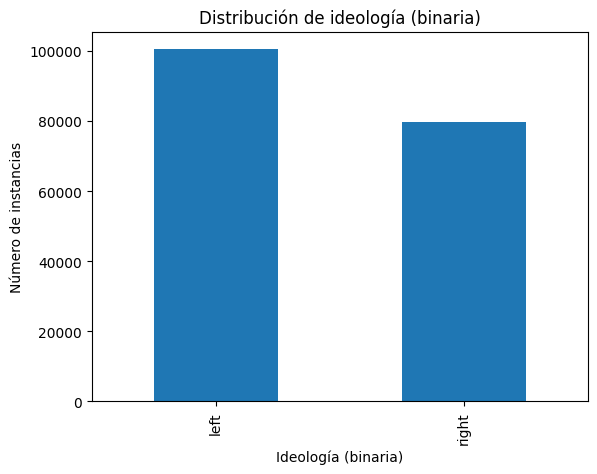

In [10]:
# Distribución de ideología binaria
plot_bar_counts(train_df["ideology_binary"], "Distribución de ideología (binaria)", "Ideología (binaria)")

La distribución de la variable objetivo binaria muestra que la clase `left` es mayoritaria frente a la clase `right`.

Aunque existe cierto desequilibrio entre ambas clases, no se trata de un desbalance extremo. La clase `left` aparece con algo más de 100.000 instancias, mientras que la clase `right` se sitúa cerca de 80.000.

A continuación se representa la distribución ideológica multiclase para entender el nivel de granularidad disponible en las etiquetas originales.

ideology_multiclass
moderate_left     66000
moderate_right    58240
left              34400
right             21360
Name: count, dtype: int64

Distribución porcentual (%):
ideology_multiclass
moderate_left     36.666667
moderate_right    32.355556
left              19.111111
right             11.866667
Name: proportion, dtype: float64


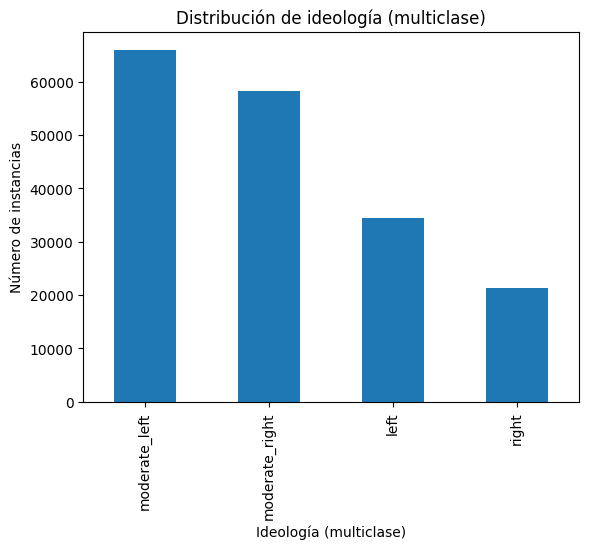

In [11]:
# Distribución de ideología multiclase
plot_bar_counts(train_df["ideology_multiclass"], "Distribución de ideología (multiclase)", "Ideología (multiclase)")

Las clases `moderate_left` y `moderate_right` son las que tienen más ejemplos, sobre todo `moderate_left`. En cambio, las clases `left` y `right` aparecen menos representadas.

Esto indica que la mayoría de los tweets del dataset están asociados a perfiles moderados.

A continuación se representa la distribución de género en el dataset, como parte del análisis descriptivo de las variables disponibles.

gender
male      119440
female     60560
Name: count, dtype: int64

Distribución porcentual (%):
gender
male      66.355556
female    33.644444
Name: proportion, dtype: float64


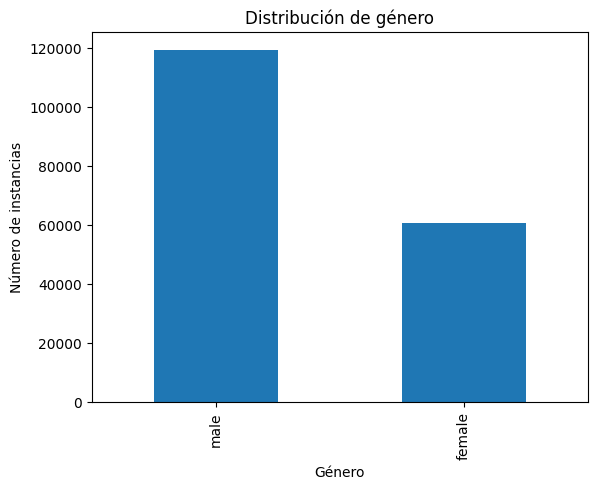

In [12]:
# Distribución de género
plot_bar_counts(train_df["gender"], "Distribución de género", "Género")

En esta gráfica se observa que hay bastantes más ejemplos asociados a perfiles `male` que a perfiles `female`.

Este desequilibrio es importante porque indica que el dataset no está balanceado respecto al género de los perfiles. Aunque el objetivo principal del proyecto no es predecir género, esta variable ayuda a entender mejor la composición del conjunto de datos.

A continuación se representa la distribución de profesiones, permitiendo identificar categorías dominantes o posibles desequilibrios.

profession
journalist    110800
politician     60160
celebrity       9040
Name: count, dtype: int64

Distribución porcentual (%):
profession
journalist    61.555556
politician    33.422222
celebrity      5.022222
Name: proportion, dtype: float64


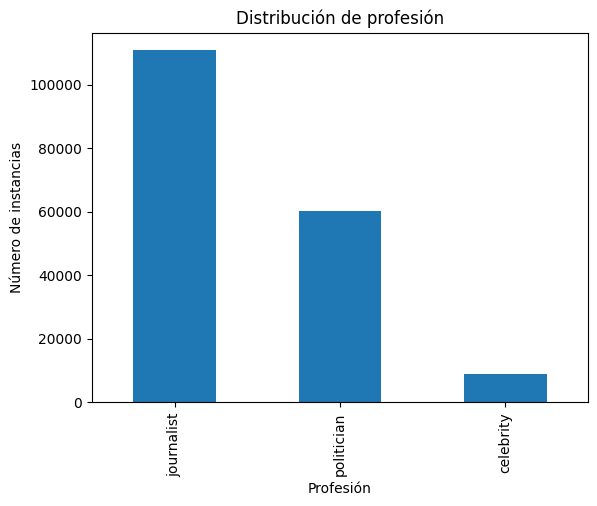

In [13]:
# Distribución de profesión
plot_bar_counts(train_df["profession"], "Distribución de profesión", "Profesión")

En esta gráfica se observa que la mayoría de los ejemplos pertenecen a perfiles de `journalist`, seguidos por perfiles de `politician`.

La categoría `celebrity` tiene mucha menos representación que las otras dos. Esto indica que el dataset está formado principalmente por tweets de periodistas y políticos, lo cual tiene sentido al tratarse de un corpus centrado en discurso político.

A continuación se calculan métricas de longitud de los tweets en caracteres y palabras. Estas estadísticas ayudan a caracterizar el corpus textual.

In [14]:
TEXT_COL = "tweet"

# Longitud en caracteres y en nº de palabras
train_df["tweet_len_char"] = train_df[TEXT_COL].astype(str).str.len()
train_df["tweet_len_tokens"] = train_df[TEXT_COL].astype(str).str.split().str.len()

print("Estadísticas de longitud en caracteres:")
print(train_df["tweet_len_char"].describe())

print("\nEstadísticas de longitud en tokens:")
print(train_df["tweet_len_tokens"].describe())

Estadísticas de longitud en caracteres:
count    180000.000000
mean        167.976806
std          76.281273
min          17.000000
25%          98.000000
50%         163.000000
75%         243.000000
max         511.000000
Name: tweet_len_char, dtype: float64

Estadísticas de longitud en tokens:
count    180000.000000
mean         28.758622
std          12.789524
min           4.000000
25%          17.000000
50%          28.000000
75%          40.000000
max          65.000000
Name: tweet_len_tokens, dtype: float64


Se dibuja un histograma de la longitud de los tweets en palabras para observar la distribución general del tamaño de los textos.

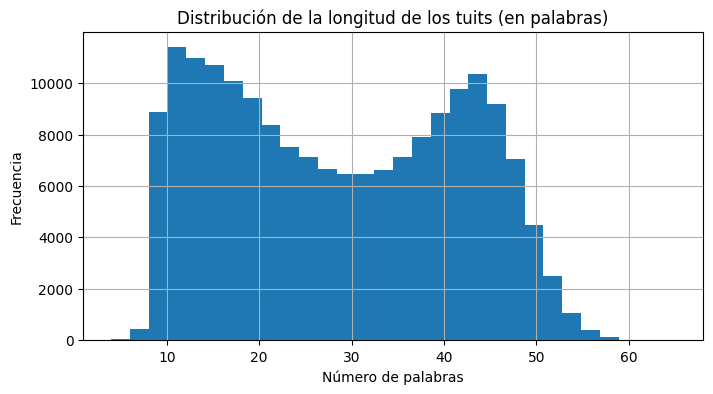

In [15]:
# Histograma global (en palabras)
plt.figure(figsize=(8, 4))
train_df["tweet_len_tokens"].hist(bins=30)
plt.title("Distribución de la longitud de los tuits (en palabras)")
plt.xlabel("Número de palabras")
plt.ylabel("Frecuencia")
plt.show()

Se observa que la mayoría de los textos se concentran aproximadamente entre 10 y 50 palabras. También aparecen dos zonas con bastante frecuencia: una alrededor de los 10-20 términos y otra alrededor de los 40-45 términos.

Esto indica que el dataset contiene tuits de longitudes variadas, aunque no se ven muchos casos extremadamente cortos ni extremadamente largos.

A continuación se compara la longitud de los tweets por ideología mediante un boxplot, buscando diferencias de estilo o extensión entre clases.

<Figure size 600x400 with 0 Axes>

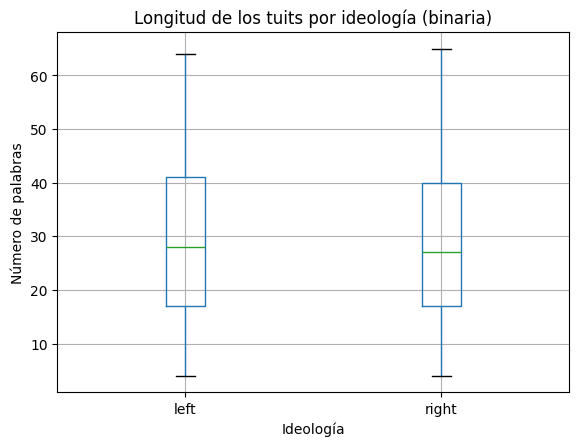

In [16]:
# Boxplot por ideología binaria
plt.figure(figsize=(6, 4))
train_df.boxplot(column="tweet_len_tokens", by="ideology_binary")
plt.title("Longitud de los tuits por ideología (binaria)")
plt.suptitle("")  # quita el título automático de pandas
plt.xlabel("Ideología")
plt.ylabel("Número de palabras")
plt.show()

Se observa que las distribuciones de `left` y `right` son muy parecidas. La mediana está alrededor de 27-28 palabras en ambos casos y los rangos también son similares. Por tanto, no parece que la longitud del tuit sea una variable que diferencie claramente entre ideologías. 

Se calcula la longitud media de los tweets por ideología, proporcionando un resumen numérico para comentar junto a las visualizaciones.

In [17]:
# medias por ideología para comentar en la memoria
print("\nMedia de longitud (tokens) por ideología:")
print(train_df.groupby("ideology_binary")["tweet_len_tokens"].mean())


Media de longitud (tokens) por ideología:
ideology_binary
left     28.946494
right    28.521658
Name: tweet_len_tokens, dtype: float64


## 1.3 Análisis preliminar del texto

En esta sección se realiza un primer análisis del contenido textual de los tweets del conjunto de entrenamiento. El objetivo es identificar patrones léxicos asociados a cada clase ideológica, revisar ejemplos reales por clase y detectar la presencia de términos relacionados con desinformación.

Este análisis se realiza únicamente sobre el conjunto de entrenamiento para evitar extraer conclusiones exploratorias a partir del conjunto de test final.

In [18]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer

Se define una función auxiliar para limpiar el texto antes de realizar el análisis exploratorio. Esta limpieza se utiliza principalmente para estudiar vocabulario, frecuencias de palabras y patrones léxicos.

In [19]:
# Se define una función de limpieza léxica para el análisis exploratorio y los modelos clásicos.
def clean_text_for_eda(text):
    """
    Se aplica una limpieza básica del texto para el análisis exploratorio.

    La función realiza las siguientes transformaciones:
    - convierte el texto a minúsculas;
    - elimina URLs;
    - elimina menciones de usuario;
    - elimina el símbolo de hashtag, pero conserva el texto asociado;
    - elimina caracteres especiales no alfanuméricos;
    - normaliza espacios múltiples.
    """
    # Se convierte el valor recibido a string y se pasa a minúsculas.
    text = str(text).lower()
    
    # Se eliminan URLs que comienzan por http, https o www.
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # Se eliminan menciones de usuario.
    text = re.sub(r"@\w+", " ", text)
    
    # Se elimina únicamente el símbolo "#", conservando la palabra del hashtag.
    text = re.sub(r"#", "", text)
    
    # Se sustituyen por espacios los caracteres que no sean letras, números o espacios.
    # Se conservan letras acentuadas y la ñ para no perder información propia del español.
    text = re.sub(r"[^a-záéíóúüñ0-9\s]", " ", text)
    
    # Se normalizan espacios múltiples y se eliminan espacios al principio y al final.
    text = re.sub(r"\s+", " ", text).strip()
    
    # Se devuelve el texto limpio.
    return text


Se aplica la función de limpieza definida anteriormente sobre los conjuntos de entrenamiento y test. El resultado se almacena en una nueva columna llamada `tweet_clean`.

Esta columna se utilizará posteriormente en el análisis exploratorio y en las representaciones clásicas basadas en texto, como TF-IDF y Word2Vec. Se mantiene también la columna `tweet` original para conservar el texto sin modificar.

In [20]:
train_df["tweet_clean"] = train_df["tweet"].apply(clean_text_for_eda)
test_df["tweet_clean"] = test_df["tweet"].apply(clean_text_for_eda)

Se prepara un dataframe específico para el análisis textual exploratorio, conservando el texto, la clase ideológica y el identificador de cluster.

In [21]:
# Se definen las columnas que se utilizarán en el análisis textual exploratorio.
TEXT_COL = "tweet"
CLEAN_TEXT_COL = "tweet_clean"
TARGET_COL = "ideology_binary"

text_analysis_columns = [
    "label",
    TEXT_COL,
    CLEAN_TEXT_COL,
    TARGET_COL,
    "ideology_multiclass"
]

# Se comprueba que todas las columnas necesarias existen después de crear la columna "tweet_clean".
for column in text_analysis_columns:
    assert column in train_df.columns, f"Columna no encontrada en train_df: {column}"

# Se crea un dataframe auxiliar reducido para el análisis textual.
# Esta copia evita modificar accidentalmente el dataframe original.
text_df = train_df[text_analysis_columns].copy()

# Se muestra el tamaño del dataframe auxiliar y algunos ejemplos del texto original y limpio.
print("Dataset para análisis textual:", text_df.shape)
display(text_df[[TEXT_COL, CLEAN_TEXT_COL, TARGET_COL, "ideology_multiclass"]].head())

Dataset para análisis textual: (180000, 5)


,tweet,tweet_clean,ideology_binary,ideology_multiclass
0,¡Feliz 28 de febrero a todas las andaluzas y a...,feliz 28 de febrero a todas las andaluzas y an...,left,left
1,"Feliz año nuevo, feliz esperanza 💕. Querido 20...",feliz año nuevo feliz esperanza querido 2023 a...,left,left
2,🇩🇪🇪🇸 ¡Un placer encontrarme con mi homólogo al...,un placer encontrarme con mi homólogo alemán c...,left,left
3,El conflicto en Ucrania ha supuesto una dramát...,el conflicto en ucrania ha supuesto una dramát...,left,left
4,La Academia de la Llingua Asturiana realiza un...,la academia de la llingua asturiana realiza un...,left,left


El dataframe auxiliar para el análisis textual contiene 180000 filas y 5 columnas. Cada fila representa un tweet del conjunto de entrenamiento, mientras que las columnas seleccionadas recogen el texto original, el texto limpio y las etiquetas ideológicas utilizadas en el análisis.

Se construye una lista personalizada de *stopwords* para el análisis léxico. Además de las palabras vacías habituales del español, se añaden términos frecuentes propios de Twitter y del dataset que no aportan información semántica relevante para el análisis.

El objetivo es evitar que palabras muy comunes, menciones anonimizadas o términos de bajo contenido informativo dominen los conteos de palabras y las visualizaciones posteriores.

In [22]:
import nltk
from nltk.corpus import stopwords

# Se comprueba si las stopwords de NLTK están disponibles.
# Si no están instaladas, se descargan de forma silenciosa.
try:
    stopwords.words("spanish")
except LookupError:
    nltk.download("stopwords", quiet=True)

In [23]:
# Se cargan las stopwords estándar del español disponibles en NLTK.
spanish_stopwords = set(stopwords.words("spanish"))

# Se definen stopwords específicas y comunes del contexto de Twitter.
twitter_stopwords = {
    "rt", "https", "http", "tco", "amp"
}

# Se añaden stopwords específicas del dataset.
dataset_stopwords = {
    "user", "hashtag",
    "si", "sí", "mas", "más",
    "q", "x", "d",
    "hoy", "ayer", "mañana",
    "año", "años", "dia", "día",
    "ser", "hacer", "hace", "ver",
    "va", "van", "voy", "vamos",
    "tan", "solo", "sólo"
}

# Se combinan las tres listas de stopwords eliminando duplicados mediante conjuntos.
custom_stopwords = list(
    spanish_stopwords
    | twitter_stopwords
    | dataset_stopwords
)

# Se muestra el número total de stopwords utilizadas.
print("Número de stopwords:", len(custom_stopwords))

Número de stopwords: 343


Se muestran algunos ejemplos aleatorios de tweets de cada clase (`left` y `right`) para revisar de forma rápida el tipo de texto que hay en cada grupo.

Esta revisión sirve para comprobar que las etiquetas tienen sentido y para hacerse una primera idea del lenguaje que aparece en cada ideología.

Además la selección se hace con una semilla fija, por lo que los mismos ejemplos se pueden volver a obtener si se ejecuta otra vez el notebook.

In [24]:
# Se configura pandas para mostrar textos más largos.
pd.set_option("display.max_colwidth", 250)

# Se seleccionan 5 ejemplos aleatorios por cada clase de la variable objetivo.
# El uso de RANDOM_STATE permite que la muestra sea reproducible.
examples_by_class = (
    text_df
    .groupby(TARGET_COL, group_keys=False)
    .sample(n=5, random_state=RANDOM_STATE)
    [["label", TARGET_COL, "ideology_multiclass", "tweet"]]
)

# Se muestran los ejemplos seleccionados.
display(examples_by_class)

,label,ideology_binary,ideology_multiclass,tweet
86686,815b2287e55ca0f359a2a9f907a561d4,left,left,"@user Comité técnico:. El Gobierno publicó los nombres de sus siete miembros. Antoni Trilla García, jefe del Servicio de Medicina Preventiva y Epidemiología del Hospital Clínic de Barcelona; Hermelinda Vanaclocha Luna, subdirectora general de Epi..."
42585,3fb056f9dc98c5a675bda145966dcc46,left,moderate_left,Por parte de los [POLITICAL_PARTY] seguiremos intentando que haya acuerdo. El [POLITICAL_PARTY] que no pretenda darnos lecciones de ningún tipo porque el [POLITICAL_PARTY] lo que no quiere es esta ley. Que no nos vengan con cuentos.
125501,b65412ed95031f9cef0d2386a2f67b97,left,left,"[POLITICIAN], en el programa de [POLITICIAN] en la tele de Berlusconi, señala nada menos que a Mauricio Casals (presidente de La Razón y directivo de Atresmedia) como su enemigo. ¿Planeta/Atresmedia en operación para lanzar a Feijoo? Aten cabos"
20412,1d08ff6d0b39190cd656972a30a24258,left,moderate_left,@user Si. 100%. ¿Pero con la prensa es una línea editorial? 🤔
98354,91249d6e0c8b3b0daa5ee4407ab005d4,left,moderate_left,Ya está la cubierta de NOSOTROS de @user Premio Nadal 2023. ¡Me encanta!. 💕💕@user . [HASHTAG] Nadal
2994,02edba8d505e9a70a2fbf723a2b0d0eb,right,moderate_right,"@user más: a. Desde que sucedieron los hechos (hace cuatro días) el matrimonio ha seguido conviviendo. El investigado carece de antecedentes penales. La presunta víctima no ha formulado denuncia contra su marido y, en la declaración de hoy como p..."
127678,b9a23c0acb68e4d16ffd36b3118f62b1,right,moderate_right,"El TC no se ha dejado influenciar por las presiones del Gobierno y ha admitido a trámite la demanda del [POLITICAL_PARTY], lo cual demuestra que la interposición del recurso era una decisión correcta y que en su deriva autoritaria el Gobierno ha ..."
169730,f252919da45c363c4c1b6c6efb022b03,right,right,"@user No es una misión. Es una vocación. Lee, para empezar ""El camino del corazón"". Seguro que después leerás otros."
141568,cb31865c6c17608f1169b6d5217df57b,right,moderate_right,"Dice [POLITICIAN] que “respeta” a los independentistas que amenazan con “volver a hacerlo”. Difícil de creer, pero acaba de ocurrir en el Congreso. El presidente del Gobierno de España respetando el delito y el golpismo"
78602,75b7258e9c6824813c9771a1e524eaaf,right,moderate_right,Tiene su cosa que le haya molestado sólo lo de Griñán. De los del prucés no tiene nada que decir


Se define una función auxiliar para obtener las palabras más frecuentes dentro de una clase ideológica concreta. Para ello, se filtran los tweets de una clase, se vectoriza el texto limpio mediante `CountVectorizer` y se suman las apariciones de cada término.

Esta función permite comparar el vocabulario más frecuente entre las clases `left` y `right`, ayudando a identificar patrones léxicos característicos de cada grupo ideológico.

In [25]:
# Se define una función auxiliar para extraer las palabras más frecuentes por clase ideológica.
# La función trabaja sobre el texto limpio y elimina las stopwords definidas previamente.
def get_top_words_by_class(
    df,
    class_value,
    text_col="tweet_clean",
    target_col="ideology_binary",
    stop_words=None,
    n_words=20,
    min_df=5
):
    """
    Se obtienen las palabras más frecuentes para una clase concreta.

    Parámetros:
    - df: dataframe que contiene los textos y las etiquetas.
    - class_value: clase ideológica que se quiere analizar.
    - text_col: columna de texto limpio que se utilizará.
    - target_col: columna que contiene la variable objetivo.
    - stop_words: lista de palabras vacías que se eliminarán.
    - n_words: número de palabras más frecuentes que se devolverán.
    - min_df: frecuencia mínima de documentos para conservar un término.

    Devuelve:
    - DataFrame con las palabras más frecuentes y su número de apariciones.
    """
    # Se seleccionan únicamente los textos pertenecientes a la clase indicada.
    class_texts = df[df[target_col] == class_value][text_col].astype(str)

    # Se vectoriza el texto para contar términos.
    # CountVectorizer transforma el conjunto de textos en una matriz documento-término.
    vectorizer = CountVectorizer(
        stop_words=stop_words,
        min_df=min_df
    )

    # Se ajusta el vectorizador sobre los textos de la clase y se obtiene la matriz de conteos.
    X = vectorizer.fit_transform(class_texts)

    # Se suman las apariciones de cada palabra en todos los tweets de la clase.
    word_counts = np.asarray(X.sum(axis=0)).ravel()

    # Se recupera el vocabulario asociado a las columnas de la matriz.
    vocabulary = vectorizer.get_feature_names_out()

    # Se construye una tabla con cada palabra y su frecuencia total.
    # Después se ordena de mayor a menor frecuencia y se conservan las n_words primeras.
    top_words = (
        pd.DataFrame({
            "word": vocabulary,
            "count": word_counts
        })
        .sort_values("count", ascending=False)
        .head(n_words)
        .reset_index(drop=True)
    )

    # Se devuelve la tabla final de palabras frecuentes.
    return top_words

Se aplica la función anterior para obtener las palabras más frecuentes en cada una de las dos clases ideológicas principales: `left` y `right`.

El objetivo es construir dos tablas comparables que permitan analizar si existen diferencias léxicas entre ambas clases después de aplicar la limpieza textual y eliminar las stopwords.

In [26]:
top_words_left = get_top_words_by_class(
    text_df,
    class_value="left",
    stop_words=custom_stopwords,
    n_words=20
)

top_words_right = get_top_words_by_class(
    text_df,
    class_value="right",
    stop_words=custom_stopwords,
    n_words=20
)

Se define una función auxiliar para visualizar las palabras más frecuentes mediante gráficos de barras horizontales. Este tipo de gráfico facilita comparar la frecuencia de los términos, ya que las palabras quedan ordenadas de menor a mayor dentro de la visualización.

Después, la función se aplica por separado a las clases `left` y `right`, permitiendo comparar visualmente el vocabulario más frecuente de cada grupo ideológico.

In [27]:
# Se define una función auxiliar para representar las palabras más frecuentes.
def plot_top_words(top_words_df, title):
    plt.figure(figsize=(8, 5))
    
    # Se invierte el orden de las filas para que las palabras más frecuentes aparezcan arriba.
    plt.barh(
        top_words_df["word"][::-1],
        top_words_df["count"][::-1]
    )
    
    # Se añaden el título y las etiquetas de los ejes.
    plt.title(title)
    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")
    
    # Se ajusta el diseño para evitar que las etiquetas se corten.
    plt.tight_layout()
    
    # Se muestra el gráfico final.
    plt.show()

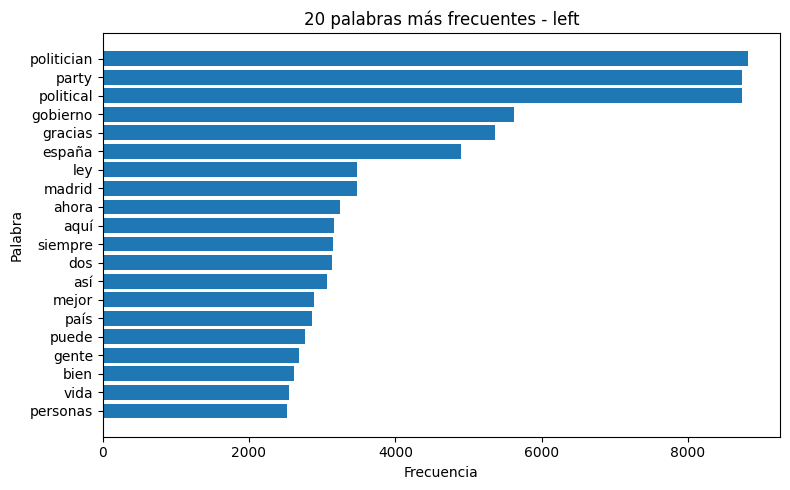

In [28]:
# Se visualizan las 20 palabras más frecuentes de la clase "left".
plot_top_words(top_words_left, "20 palabras más frecuentes - left")

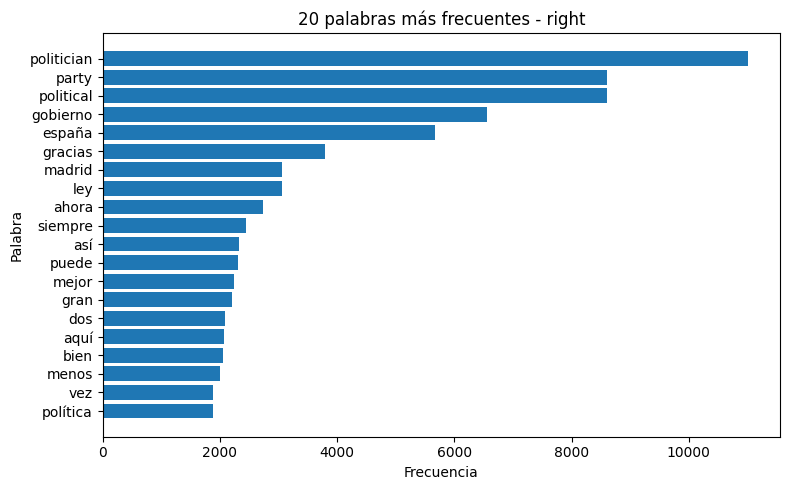

In [29]:
# Se visualizan las 20 palabras más frecuentes de la clase "right".
plot_top_words(top_words_right, "20 palabras más frecuentes - right")

Se define una función auxiliar para generar nubes de palabras a partir de frecuencias previamente calculadas. Esta visualización permite identificar de forma rápida los términos más representativos de cada clase, ya que las palabras con mayor frecuencia aparecen con mayor tamaño.

La función recibe un diccionario de frecuencias, genera la nube de palabras y la muestra como una figura independiente. Esto permite reutilizar el mismo procedimiento para comparar visualmente el vocabulario de las clases `left` y `right`.

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Se define una función auxiliar para generar nubes de palabras a partir de frecuencias calculadas.
def plot_wordcloud_from_frequencies(frequencies, title, max_words=80):
    """
    Se genera una nube de palabras a partir de un diccionario de frecuencias.

    Parámetros:
    - frequencies: diccionario donde las claves son palabras y los valores son frecuencias o pesos numéricos.
    - title: título que se mostrará sobre la nube de palabras.
    - max_words: número máximo de palabras que se representarán en la visualización.
    """
    # Se crea la nube de palabras utilizando las frecuencias proporcionadas.
    # Las palabras con mayor frecuencia aparecerán con mayor tamaño.
    wordcloud = WordCloud(
        width=900,
        height=450,
        background_color="white",
        max_words=max_words
    ).generate_from_frequencies(frequencies)

    # Se crea una figura independiente para cada nube de palabras.
    plt.figure(figsize=(10, 5))
    
    # Se muestra la nube de palabras generada.
    plt.imshow(wordcloud, interpolation="bilinear")
    
    # Se ocultan los ejes, ya que no aportan información en este tipo de visualización.
    plt.axis("off")
    
    # Se añade el título de la figura.
    plt.title(title)
    
    # Se ajusta el diseño para evitar cortes en la visualización.
    plt.tight_layout()
    
    # Se muestra la figura final.
    plt.show()

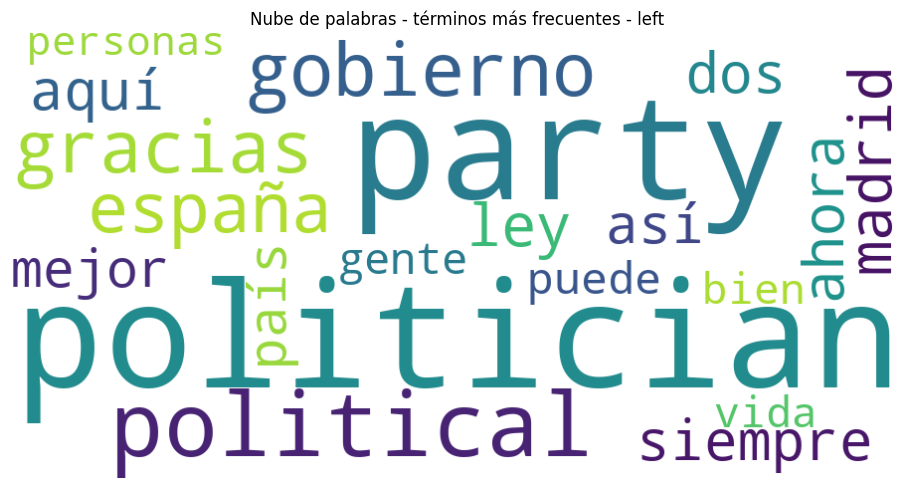

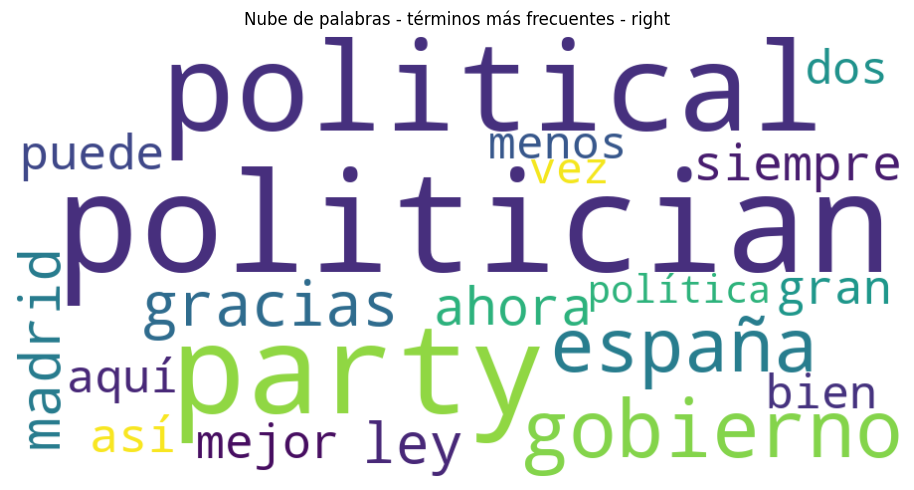

In [31]:
# Se construye un diccionario de frecuencias para la clase "left".
left_freq_dict = dict(
    zip(top_words_left["word"], top_words_left["count"])
)

# Se construye un diccionario de frecuencias para la clase "right".
right_freq_dict = dict(
    zip(top_words_right["word"], top_words_right["count"])
)

# Se genera la nube de palabras correspondiente a la clase "left".
plot_wordcloud_from_frequencies(
    left_freq_dict,
    "Nube de palabras - términos más frecuentes - left"
)

# Se genera la nube de palabras correspondiente a la clase "right".
plot_wordcloud_from_frequencies(
    right_freq_dict,
    "Nube de palabras - términos más frecuentes - right"
)

En las palabras más frecuentes se ve que las dos clases comparten bastante vocabulario.

Aparecen términos como `gobierno`, `españa`, `ley`, `madrid` o `ahora` en ambas ideologías, lo que tiene sentido porque los tweets tratan temas políticos parecidos.

Por tanto, este primer análisis sirve para ver qué palabras aparecen más, pero también muestra que contar palabras no es suficiente para diferenciar bien entre `left` y `right`.

Por todo ello, ahora se calcula una medida de especificidad léxica entre las clases `left` y `right`. En lugar de analizar únicamente las palabras más frecuentes, se compara la frecuencia relativa de cada término en una clase frente a la otra.

Para ello, se vectoriza el texto limpio con `CountVectorizer`, se calculan las frecuencias por clase y se obtiene el log-ratio entre ambas distribuciones. Los valores positivos indican términos más característicos de `left`, mientras que los valores negativos indican términos más característicos de `right`.

Se aplica un suavizado (`alpha = 1`) para evitar divisiones por cero en palabras que aparecen en una clase pero no en la otra.

In [32]:
# CountVectorizer genera una matriz documento-término, donde cada columna representa una palabra.
vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    min_df=20
)

# Se ajusta el vectorizador sobre todos los textos limpios y se obtiene la matriz de conteos.
X = vectorizer.fit_transform(text_df["tweet_clean"])

# Se recupera el vocabulario asociado a las columnas de la matriz.
vocabulary = vectorizer.get_feature_names_out()

# Se extrae la variable objetivo para identificar las filas de cada clase ideológica.
y = text_df[TARGET_COL].values

# Se crean máscaras booleanas para separar los tweets de la clase "left" y de la clase "right".
mask_left = y == "left"
mask_right = y == "right"

# Se suman las apariciones de cada palabra dentro de la clase "left".
freq_left = np.asarray(X[mask_left].sum(axis=0)).ravel()

# Se suman las apariciones de cada palabra dentro de la clase "right".
freq_right = np.asarray(X[mask_right].sum(axis=0)).ravel()

# Se define un factor de suavizado para evitar probabilidades cero.
# Esto es importante cuando una palabra aparece en una clase pero no en la otra.
alpha = 1.0

# Se calcula la probabilidad suavizada de cada palabra dentro de la clase "left".
p_left = (freq_left + alpha) / (freq_left.sum() + alpha * len(vocabulary))

# Se calcula la probabilidad suavizada de cada palabra dentro de la clase "right".
p_right = (freq_right + alpha) / (freq_right.sum() + alpha * len(vocabulary))

# Se calcula el log-ratio entre ambas probabilidades.
log_ratio = np.log(p_left / p_right)

# Se construye una tabla con cada palabra, su log-ratio y sus frecuencias absolutas por clase.
log_ratio_df = (
    pd.DataFrame({
        "word": vocabulary,
        "log_ratio_left_vs_right": log_ratio,
        "freq_left": freq_left,
        "freq_right": freq_right
    })
    .sort_values("log_ratio_left_vs_right", ascending=False)
)

# Se seleccionan los 20 términos más específicos de la clase "left".
top_left_specific = log_ratio_df.head(20).copy()

# Se seleccionan los 20 términos más específicos de la clase "right".
# Al estar al final de la tabla, son los términos con log-ratio más negativo.
top_right_specific = log_ratio_df.tail(20).sort_values(
    "log_ratio_left_vs_right",
    ascending=True
).copy()

In [33]:
# Se muestran los términos proporcionalmente más característicos de la clase "left".
print("Términos más característicos de la clase left:")
display(top_left_specific)

# Se muestran los términos proporcionalmente más característicos de la clase "right".
print("Términos más característicos de la clase right:")
display(top_right_specific)

Términos más característicos de la clase left:


,word,log_ratio_left_vs_right,freq_left,freq_right
1644,bdía,5.121259,213,0
205,795,4.682537,137,0
10712,rdoba,4.137310,79,0
11300,riojanas,4.124731,78,0
11131,residente,4.099088,538,6
206,797,3.982117,136,1
1956,cafetera,3.660617,148,2
9057,omisiones,3.516483,42,0
4488,dunas,3.418845,38,0
5548,falleció,3.418845,545,13


Términos más característicos de la clase right:


,word,log_ratio_left_vs_right,freq_left,freq_right
10867,recuadro,-5.092833,1,254
11894,snchz,-4.898677,0,104
2208,castillón,-4.788012,0,93
11542,sanchista,-4.766506,0,91
6933,infobae,-4.744527,1,179
4044,despegamos,-4.535177,1,145
12023,soñadores,-4.305160,1,115
12213,sánchezstein,-4.252050,0,54
3564,cómame,-4.115918,0,47
8658,narcocomunismo,-4.073358,0,45


A continuación se crean nubes de palabras para ver los términos más representativos de las clases `left` y `right`.

En este caso no se usan solo las palabras que más aparecen, sino una puntuación que combina dos ideas, que la palabra sea frecuente dentro de una clase y que además sea más propia de esa clase que de la otra.

Para ello, se utiliza el log-ratio junto con la frecuencia suavizada de cada término. Así se intenta evitar que salgan solo palabras muy repetidas, dando más importancia a las que ayudan mejor a diferenciar entre `left` y `right`.

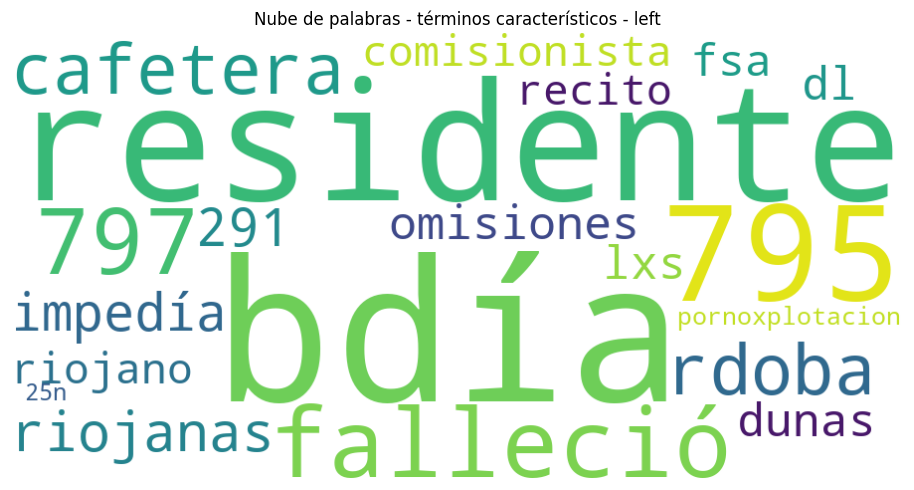

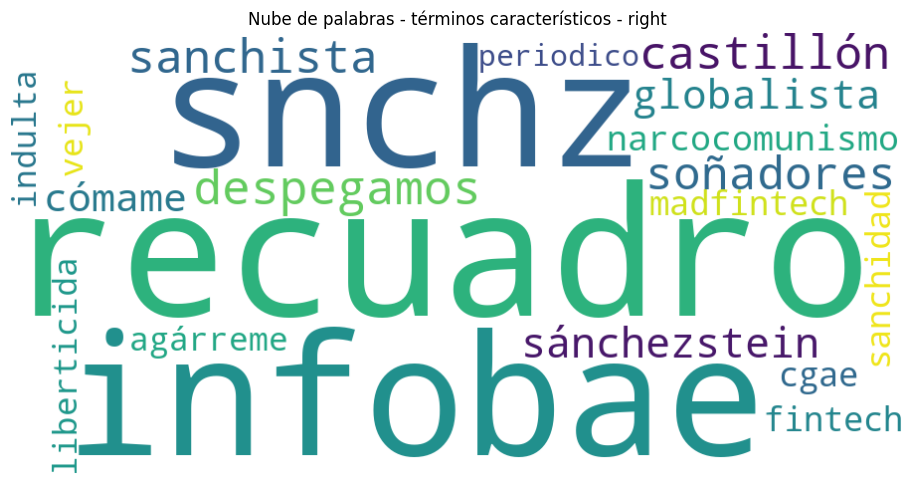

In [34]:
# Se construye un diccionario de pesos para las palabras más características de la clase "left".
left_characteristic_dict = dict(
    zip(
        top_left_specific["word"],
        top_left_specific["log_ratio_left_vs_right"].abs() * np.log1p(top_left_specific["freq_left"])
    )
)

# Se construye un diccionario equivalente para la clase "right".
right_characteristic_dict = dict(
    zip(
        top_right_specific["word"],
        top_right_specific["log_ratio_left_vs_right"].abs() * np.log1p(top_right_specific["freq_right"])
    )
)

# Se genera la nube de palabras de los términos más característicos de la clase "left".
plot_wordcloud_from_frequencies(
    left_characteristic_dict,
    "Nube de palabras - términos característicos - left"
)

# Se genera la nube de palabras de los términos más característicos de la clase "right".
plot_wordcloud_from_frequencies(
    right_characteristic_dict,
    "Nube de palabras - términos característicos - right"
)

El análisis inicial muestra que los tweets tienen vocabulario claramente político y que pueden existir algunas diferencias entre las clases `left` y `right`.

Las palabras más frecuentes ayudan a ver qué términos aparecen más en cada grupo, aunque no siempre sirven para diferenciar bien entre ideologías, porque algunas palabras aparecen mucho en las dos clases. Por eso también se utiliza el log-ratio, que permite detectar palabras que son más propias de una clase que de la otra.

Las nubes de palabras sirven como apoyo visual para ver estos términos de forma más rápida. Aun así, hay que interpretarlas con cuidado, porque solo muestran palabras sueltas y no tienen en cuenta el contexto completo del tweet.

En general, este análisis sugiere que el texto sí contiene información útil para intentar clasificar la ideología. En los siguientes apartados se comprobará esto usando distintas representaciones vectoriales y modelos de clasificación.

## 1.4 Formulación de hipótesis iniciales sobre posibles relaciones entre desinformación y polarización.

A partir del análisis exploratorio del texto, se plantean algunas hipótesis iniciales sobre la relación entre desinformación y polarización ideológica.

En este proyecto, la polarización se trabaja a partir de la variable `ideology_binary`, que separa los tweets en las clases `left` y `right`. En cambio, la desinformación no se puede medir directamente como contenido verdadero o falso, porque el dataset no incluye una etiqueta específica para eso.

Por este motivo, se hace una primera aproximación usando palabras relacionadas con desinformación, como `bulo`, `fake news`, `mentira`, `fraude`, `manipulación` o `desinformación`.

Esta aproximación tiene una limitación importante: que aparezca una de estas palabras en un tweet no significa necesariamente que ese tweet esté difundiendo desinformación. También puede estar hablando sobre ella, denunciándola o criticándola.

In [35]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Se define una lista de palabras clave relacionadas con desinformación.
disinfo_keywords = [
    "bulo", "bulos",
    "fake news", "fakenews",
    "mentira", "mentiras",
    "fraude", "fraudes",
    "manipulación", "manipulado", "manipulada",
    "desinformación",
    "hoax"
]

# Se construye una expresión regular a partir de las palabras clave.
disinfo_pattern = "|".join(re.escape(keyword) for keyword in disinfo_keywords)

# Se identifica si cada tweet contiene alguna palabra clave relacionada con desinformación.
text_df["has_disinfo_kw"] = text_df["tweet_clean"].str.contains(
    disinfo_pattern,
    case=False,
    regex=True,
    na=False
)

# Se calcula el conteo absoluto y porcentual de tweets con y sin palabras clave.
disinfo_summary = pd.DataFrame({
    "conteo": text_df["has_disinfo_kw"].value_counts(),
    "porcentaje": (text_df["has_disinfo_kw"].value_counts(normalize=True) * 100).round(2)
})

# Se renombran los valores booleanos para facilitar la interpretación de la tabla.
disinfo_summary.index = disinfo_summary.index.map({
    True: "Contiene palabra clave",
    False: "No contiene palabra clave"
})

# Se muestra el resumen final.
disinfo_summary

,conteo,porcentaje
has_disinfo_kw,,
No contiene palabra clave,177609,98.67
Contiene palabra clave,2391,1.33


El resultado muestra que solo una parte pequeña del dataset contiene palabras relacionadas con desinformación.

En concreto, aparecen 2391 tweets con al menos una de las palabras clave definidas, lo que supone un 1.33% del conjunto de entrenamiento. Es decir, este tipo de vocabulario está presente, pero no es muy frecuente dentro del corpus.

También es importante aclarar que la variable `has_disinfo_kw` no significa que el tweet sea falso o desinformativo. Solo indica que contiene alguna palabra relacionada con bulos, noticias falsas, manipulación o fraude.

Por tanto, esta variable se usa como una primera aproximación exploratoria, pero no como una etiqueta real de desinformación.

Después de calcular la presencia global de palabras clave asociadas a desinformación, se analiza si dicha presencia varía entre las clases ideológicas `left` y `right`.

Para ello, se construye una tabla cruzada normalizada por clase. De esta forma, se compara el porcentaje de tweets con palabras clave dentro de cada grupo ideológico, evitando que el tamaño de cada clase afecte directamente a la comparación.

In [36]:
# Se calcula la proporción de tweets con y sin palabras clave de desinformación de cada clase ideológica.
disinfo_by_ideology = pd.crosstab(
    text_df["ideology_binary"],
    text_df["has_disinfo_kw"],
    normalize="index"
)

# Se transforman las proporciones a porcentajes para facilitar la interpretación.
disinfo_by_ideology = (disinfo_by_ideology * 100).round(2)

# Se renombran las columnas booleanas para que la tabla sea más legible.
disinfo_by_ideology = disinfo_by_ideology.rename(
    columns={
        False: "No contiene palabra clave",
        True: "Contiene palabra clave"
    }
)

# Se muestra la distribución porcentual por clase ideológica.
disinfo_by_ideology

has_disinfo_kw,No contiene palabra clave,Contiene palabra clave
ideology_binary,,
left,98.60,1.40
right,98.77,1.23


La tabla muestra que la presencia de palabras clave asociadas a desinformación es baja en ambas clases ideológicas. En la clase `left`, el 1.40% de los tweets contiene al menos una palabra clave, mientras que en la clase `right` el porcentaje es del 1.23%.

La diferencia entre ambas clases es reducida, de aproximadamente 0.17 puntos porcentuales. Por tanto, no se observa una divergencia fuerte entre grupos ideológicos en cuanto a la presencia de este vocabulario.

#### Ejemplos de tweets con términos asociados a desinformación

In [37]:
# Se seleccionan ejemplos de tweets que contienen alguna palabra clave relacionada con desinformación.
disinfo_examples = (
    text_df[text_df["has_disinfo_kw"]]
    [["label", "ideology_binary", "ideology_multiclass", "tweet"]]
    .sample(
        # Se muestran como máximo 10 ejemplos.
        # Si hubiera menos de 10 tweets con palabras clave, se mostrarían todos los disponibles.
        min(10, text_df["has_disinfo_kw"].sum()),
        random_state=RANDOM_STATE
    )
)

# Se muestran los ejemplos seleccionados.
display(disinfo_examples)

,label,ideology_binary,ideology_multiclass,tweet
81054,79968947ab452d0b4217242cf2a25fef,right,right,"@user Pero yo puse ese tuit antes de la nochebuena de este año, hija nada gruñona y querida. Yo no gruño. Ronroneo, pero con tanta fuerza que mi ronroneo parece gruñido. Parece mentira que no sepas que yo digo en guasa todo lo que digo."
17887,1a9932a8c290dbb213f054e59a51fa05,right,moderate_right,"Ayer me reuní con vecinos del barrio de 🌷Las Flores, que están muy preocupados por la situación actual del CREAA 👎🏻. ➡️ Están cansados de las mentiras sobre esta instalación y la incapacidad del 🔴 gobierno municipal 🟣 para atraer proyectos. [HASH..."
175549,fa320b709113b66f4b8289ef67201551,left,left,"¡Eh, medios de la derecha! ¡Que todo lo de Neurona era mentira! Regalo de cumpleaños. Lo que sabíamos pero las acusaciones ocultaban: otro bulo. La persecución a Podemos es nuestro Watergate. A diferencia del [POLITICAL_PARTY], que suma, suma y s..."
131869,bf72b4c0fad2cbf5ddbd007cbb8a38ff,left,left,"Si el número de compradores de bulos es mayor que el número de asqueados, entonces el método funciona. Y suele funcionar. Cuando te acostumbran al vertedero la basura deja de llamar la atención. ""Ministerio de pederastia"". Mi columna doy hoy para..."
37780,383d091e6e0084f9cff10a10dda22e33,left,left,La edad del oro del periodismo. Y el uso de nuestros impuestos para sufragar a una emisora dedicada a desestabilizar la democracia a base de burdas mentiras.
27427,27ac27b249eb4f364d47369200b6aeee,right,moderate_right,La izquierda política y mediática española celebró este lunes un auténtico festival de la desinformación aprovechando la ajustada victoria de Lula en Brasil.
112971,a5357e51a56dd460dee906542363215a,left,moderate_left,Menudo repaso de @user a todas las mentiras sobre la Ley Trans. Brillante
131336,be225743c4c7670e70bf16c3f427fbb4,left,moderate_left,Ojalá algún día en España una sentencia también castigue mentir a sabiendas. La impunidad de los fabricantes de desinformación es la mayor amenaza del [HASHTAG] y de la democracia 👇🏼
73691,6ca0647fe87c772ec0334503b16d6f68,right,moderate_right,@user La única cuestión es que usted pontifica sobre cuestiones que ignora. Yo no le acuso de mentira por decir que Stalin mató más rusos que Hitler. Simplemente es un ignorante espantoso y lo malo es que partiendo de su ignorancia cree que otros...
83602,7cacc80c288624bbb469789876009151,right,moderate_right,Todo empezó cuando @user llegó al gobierno con su moción fraude y despreció a Marruecos decidiendo no visitar el país. Luego volvió a ofenderles con la entrada ilegal de Ghali en España. Ahora gira 180º y se pone contra la ONU y a favor de Marrue...


Al revisar algunos ejemplos, se ve que la búsqueda por palabras clave encuentra tweets donde aparecen términos relacionados con bulos, mentiras, fraude o desinformación.

Algunos ejemplos sí parecen estar relacionados con debates sobre desinformación política. Sin embargo, otros casos son más ambiguos. Por ejemplo, una expresión como `parece mentira` contiene la palabra `mentira`, pero no significa necesariamente que el tweet esté hablando de desinformación.

Por eso, la variable `has_disinfo_kw` debe interpretarse con cuidado. Sirve como una señal inicial para detectar vocabulario relacionado con desinformación, pero no permite afirmar que un tweet sea realmente desinformativo.

### Conclusión respecto al vocabulario asociado a desinformación y polarización

El análisis exploratorio sirve para plantear una primera idea sobre la relación entre vocabulario asociado a desinformación y polarización ideológica, pero no permite confirmarla de forma definitiva.

La variable `has_disinfo_kw` detecta tweets que contienen palabras como `bulo`, `mentira`, `fraude`, `manipulación` o `desinformación`. Sin embargo, esto no significa necesariamente que el tweet esté difundiendo desinformación. También puede estar criticándola, denunciándola o simplemente hablando sobre ella.

Los resultados muestran que estas palabras aparecen en una parte pequeña del conjunto de entrenamiento y que su presencia es bastante parecida entre las clases `left` y `right`. Por tanto, esta variable se debe entender solo como una señal léxica exploratoria, no como una etiqueta real de desinformación.

En los siguientes apartados, el análisis se centra en comprobar si el texto de los tweets contiene información suficiente para predecir la ideología binaria. Para ello, se comparan distintas representaciones vectoriales, como TF-IDF, Word2Vec y embeddings contextuales, junto con varios modelos de clasificación.


### Hipótesis iniciales derivadas del análisis exploratorio

**H1. Relación entre menciones a desinformación e ideología.**  
Los tweets que contienen términos asociados a desinformación podrían no distribuirse de forma homogénea entre las clases `left` y `right`. Es decir, una de las clases ideológicas podría mencionar con mayor frecuencia conceptos como bulos, mentiras, fraude o manipulación.

**H2. Desinformación como posible señal de confrontación discursiva.**  
Los tweets que mencionan desinformación podrían aparecer en contextos de mayor confrontación política, especialmente cuando se utilizan expresiones relacionadas con acusaciones de mentira, fraude o manipulación. No obstante, esta hipótesis se plantea de forma exploratoria, ya que el dataset no incorpora una etiqueta específica de tono emocional o confrontativo.

**H3. Diferencias léxicas entre bloques ideológicos.**  
El análisis de palabras frecuentes y palabras características sugiere la existencia de patrones léxicos diferenciados entre `left` y `right`. Por tanto, se espera que las representaciones vectoriales del texto capturen señal suficiente para predecir la ideología binaria.

**H4. Limitación del enfoque léxico para detectar desinformación.**  
La detección basada en palabras clave no permite distinguir si un tweet está difundiendo desinformación, denunciándola o simplemente discutiendo sobre ella. Por tanto, la variable `has_disinfo_kw` se considera un proxy exploratorio, no una etiqueta fiable de desinformación real.

**H5. Necesidad de modelos semánticos más ricos.**  
Dado que la polarización ideológica depende en gran medida del contexto, se espera que las representaciones contextuales basadas en Transformers puedan capturar matices semánticos que representaciones más simples, como TF-IDF o Word2Vec promedio, podrían perder.

# 2. Representación vectorial del texto

En esta sección se preparan las tres estrategias de representación textual requeridas en el enunciado:

1. TF-IDF.
2. Word2Vec como promedio de embeddings de palabras.
3. Embeddings contextuales obtenidos mediante modelos Transformer.

Estas representaciones se utilizarán posteriormente en la fase de modelado y evaluación. Para evitar fuga de datos, las representaciones que aprenden información del corpus, como TF-IDF o Word2Vec, no se ajustarán de forma global antes de la validación cruzada. En su lugar, se integrarán en pipelines o transformadores que se ajustarán únicamente sobre los datos de entrenamiento de cada fold.

El conjunto `politicES_phase_2_train_public.csv` se utilizará para entrenamiento y validación cruzada, mientras que `politicES_phase_2_test_codalab.csv` se reservará como test final independiente.

## 2.1. Preparación de variables

Se preparan las variables que se utilizarán en la fase de representación vectorial y modelado. Se define la columna de texto limpio para los modelos clásicos, la variable objetivo binaria y la columna de agrupación `label`.

Además, se comprueba que estas columnas existen tanto en el conjunto de entrenamiento como en el conjunto de test final. Esta validación es importante porque las representaciones TF-IDF y Word2Vec utilizarán `tweet_clean`, creada previamente durante el análisis exploratorio.

In [38]:
import numpy as np
import pandas as pd

# Se reutiliza la semilla global para mantener reproducibilidad.
RANDOM_STATE = 42

# Se define la columna de texto limpio para las representaciones clásicas.
TEXT_COL_CLASSIC = "tweet_clean"

# Se define la variable objetivo binaria.
TARGET_COL = "ideology_binary"

# Se define la columna de agrupación utilizada para la validación cruzada.
GROUP_COL = "label"

# Se definen las columnas mínimas necesarias para esta fase.
required_columns = [
    TEXT_COL_CLASSIC,
    TARGET_COL,
    GROUP_COL
]

# Se comprueba que las columnas requeridas existen tanto en train como en test.
# Si falta alguna columna, el notebook se detiene antes de continuar con resultados inválidos.
for column in required_columns:
    assert column in train_df.columns, f"Columna no encontrada en train_df: {column}"
    assert column in test_df.columns, f"Columna no encontrada en test_df: {column}"

# Se separa el texto limpio del conjunto de entrenamiento y del conjunto de test.
X_train_text = train_df[TEXT_COL_CLASSIC].astype(str)
X_test_text = test_df[TEXT_COL_CLASSIC].astype(str)

# Se separan las etiquetas de entrenamiento y test.
y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

# Se extraen los grupos del conjunto de entrenamiento.
# Estos grupos se usarán en StratifiedGroupKFold para evitar fuga de información entre clusters.
groups_train = train_df[GROUP_COL]

# Se muestran las dimensiones de las variables preparadas.
print("Texto clásico - entrenamiento:", X_train_text.shape)
print("Texto clásico - test final:", X_test_text.shape)
print("Variable objetivo - entrenamiento:", y_train.shape)
print("Variable objetivo - test final:", y_test.shape)
print("Grupos de entrenamiento:", groups_train.shape)

Texto clásico - entrenamiento: (180000,)
Texto clásico - test final: (43760,)
Variable objetivo - entrenamiento: (180000,)
Variable objetivo - test final: (43760,)
Grupos de entrenamiento: (180000,)


Las variables quedan preparadas para las siguientes fases. `X_train_text` y `X_test_text` contienen el texto limpio que se utilizará en las representaciones clásicas, mientras que `y_train` y `y_test` contienen la ideología binaria. La variable `groups_train` conserva los identificadores de cluster y se utilizará para aplicar validación cruzada agrupada.

## 2.2 Esquema de validación cruzada

Antes de definir las representaciones vectoriales, se fija el esquema de validación que se utilizará posteriormente en la fase de modelado.

Dado que el dataset está organizado en clusters identificados por la columna `label`, la validación no debe realizarse mediante una división aleatoria a nivel de tweet. En su lugar, se utilizará `StratifiedGroupKFold`.

Esta estrategia permite:

- mantener una proporción similar de clases `left` y `right` en cada fold;
- evitar que tweets del mismo cluster aparezcan simultáneamente en entrenamiento y validación;
- realizar una selección de hiperparámetros más robusta.

In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

# Se defiene validación cruzada estratificada y agrupada para evitar mezclar clusters entre train y validación.
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Se muestra el objeto de validación cruzada configurado.
cv

StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)

Se comprueban la estrategia de validación agrupada: para cada fold resume tamaños, distribución de clases y confirma que no hay clusters compartidos entre entrenamiento y validación.

In [40]:
# Se inicializa una lista para almacenar el resumen de cada fold.
# Esta tabla permitirá revisar la distribución de clases y grupos en la validación cruzada.
fold_summary = []

# Se recorren los folds generados por StratifiedGroupKFold.
# En cada iteración se obtienen los índices de entrenamiento y validación.
for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train_text, y_train, groups_train),
    start=1
):
    # Se extraen los labels de grupo correspondientes al subconjunto de entrenamiento.
    fold_train_labels = groups_train.iloc[train_idx]
    
    # Se extraen los labels de grupo correspondientes al subconjunto de validación.
    fold_val_labels = groups_train.iloc[val_idx]
    
    # Se comprueba si existe algún cluster compartido entre entrenamiento y validación.
    # Si el valor es 0, no hay fuga de información por grupos en ese fold.
    overlapping_labels = set(fold_train_labels).intersection(set(fold_val_labels))
    
    # Se extraen las etiquetas objetivo de entrenamiento y validación para el fold actual.
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]
    
    # Se almacena un resumen del fold actual.
    fold_summary.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "validation_rows": len(val_idx),
        "train_clusters": fold_train_labels.nunique(),
        "validation_clusters": fold_val_labels.nunique(),
        "overlapping_clusters": len(overlapping_labels),
        "train_left_pct": round((y_fold_train == "left").mean() * 100, 2),
        "validation_left_pct": round((y_fold_val == "left").mean() * 100, 2),
        "train_right_pct": round((y_fold_train == "right").mean() * 100, 2),
        "validation_right_pct": round((y_fold_val == "right").mean() * 100, 2)
    })

# Se convierte la lista de resúmenes en un dataframe para facilitar su inspección.
fold_summary_df = pd.DataFrame(fold_summary)

# Se comprueba de forma defensiva que no existe solapamiento de clusters
# entre entrenamiento y validación en ningún fold.
assert fold_summary_df["overlapping_clusters"].eq(0).all(), \
    "Se han detectado clusters compartidos entre entrenamiento y validación."

# Se muestra el resumen de la validación cruzada.
fold_summary_df

,fold,train_rows,validation_rows,train_clusters,validation_clusters,overlapping_clusters,train_left_pct,validation_left_pct,train_right_pct,validation_right_pct
0,1,144000,36000,1800,450,0,55.72,56.00,44.28,44.00
1,2,144000,36000,1800,450,0,55.67,56.22,44.33,43.78
2,3,144000,36000,1800,450,0,55.67,56.22,44.33,43.78
3,4,144000,36000,1800,450,0,55.83,55.56,44.17,44.44
4,5,144000,36000,1800,450,0,56.00,54.89,44.00,45.11


La tabla resume cómo se reparte el conjunto de entrenamiento en cada fold de la validación cruzada:

* `fold`: número del fold evaluado.
* `train_rows`: número de tweets utilizados para entrenamiento en ese fold.
* `validation_rows`: número de tweets utilizados para validación en ese fold.
* `train_clusters`: número de clusters distintos (`label`) incluidos en el subconjunto de entrenamiento.
* `validation_clusters`: número de clusters distintos (`label`) incluidos en el subconjunto de validación.
* `overlapping_clusters`: número de clusters que aparecen simultáneamente en entrenamiento y validación. Debe ser 0 para evitar fuga de información.
* `train_left_pct`: porcentaje de tweets de la clase `left` en el subconjunto de entrenamiento.
* `validation_left_pct`: porcentaje de tweets de la clase `left` en el subconjunto de validación.
* `train_right_pct`: porcentaje de tweets de la clase `right` en el subconjunto de entrenamiento.
* `validation_right_pct`: porcentaje de tweets de la clase `right` en el subconjunto de validación.


La tabla confirma que la validación cruzada mantiene separados los grupos definidos por `label`: en todos los folds el número de clusters solapados entre entrenamiento y validación es 0. 

Además, cada fold mantiene una distribución de clases similar. La clase `left` representa aproximadamente entre el 55% y el 56% de las instancias, mientras que la clase `right` representa aproximadamente entre el 44% y el 45%. Por tanto, el esquema de validación conserva el equilibrio de clases y respeta la estructura agrupada del dataset.

Esta comprobación justifica el uso de `StratifiedGroupKFold` como estrategia de validación para la selección de hiperparámetros en los modelos posteriores.

## 2.3 Representación TF-IDF

La primera estrategia de representación vectorial será TF-IDF. Esta técnica transforma cada tweet en un vector basado en la frecuencia de aparición de los términos y en su frecuencia inversa de documento, dando más peso a palabras que son relevantes en un documento pero no excesivamente comunes en todo el corpus.

En esta sección no se ajusta todavía el vectorizador sobre los datos. Solo se define la estrategia de representación y un espacio inicial de hiperparámetros que podrá utilizarse posteriormente en la fase de modelado.

Esto es importante porque ajustar TF-IDF antes de la validación cruzada introduciría fuga de información: el vocabulario y los pesos IDF se habrían calculado usando textos que después podrían aparecer en la partición de validación. Por ese motivo, el ajuste real de TF-IDF se realizará dentro de los modelos posteriores, preferiblemente dentro de un `Pipeline` o dentro de cada fold de validación cruzada.


In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuración base de TF-IDF.
# No se ajusta todavía sobre los datos para evitar fuga de información.
tfidf_base_params = {
    "lowercase": False,
    "sublinear_tf": True
}

# Espacio inicial de hiperparámetros candidatos para TF-IDF.
# Estos valores se podrán usar posteriormente en los modelos supervisados.
tfidf_param_grid_base = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [3, 5, 10],
    "tfidf__max_df": [0.85, 0.90, 0.95],
    "tfidf__max_features": [10000, 30000, 50000]
}

tfidf_param_grid_base

{'tfidf__ngram_range': [(1, 1), (1, 2)],
 'tfidf__min_df': [3, 5, 10],
 'tfidf__max_df': [0.85, 0.9, 0.95],
 'tfidf__max_features': [10000, 30000, 50000]}

Los hiperparámetros anteriores definen el espacio de búsqueda inicial para la representación TF-IDF:

* `ngram_range` controla si se utilizan únicamente palabras individuales o también combinaciones de dos palabras.
* `min_df` elimina términos demasiado raros, que pueden introducir ruido.
* `max_df` elimina términos excesivamente frecuentes, que suelen aportar poca capacidad discriminativa.
* `max_features` limita el tamaño máximo del vocabulario para controlar la dimensionalidad y el coste computacional.

Estos hiperparámetros no se ajustan en esta sección. Se evaluarán posteriormente dentro de los modelos supervisados, usando validación cruzada estratificada y agrupada por `label`. De esta forma, el vocabulario TF-IDF y los pesos IDF se aprenderán únicamente con la partición de entrenamiento de cada fold.


## 2.4 Representación Word2Vec promedio

La segunda estrategia consiste en utilizar Word2Vec para aprender embeddings de palabras. Cada tweet se representa como el promedio de los vectores de las palabras que contiene.

Esta representación produce vectores densos de tamaño fijo. A diferencia de TF-IDF, Word2Vec puede capturar cierta similitud semántica entre palabras. Sin embargo, al representar un tweet como el promedio de sus palabras, se pierde información sobre el orden, la sintaxis y algunas dependencias contextuales.

Para evitar fuga de datos, el modelo Word2Vec debe entrenarse únicamente con los textos de entrenamiento de cada fold. Por ello, se implementa como un transformador compatible con Scikit-learn.

In [42]:
from sklearn.base import BaseEstimator, TransformerMixin
from gensim.models import Word2Vec
import numpy as np


class MeanWord2VecVectorizer(BaseEstimator, TransformerMixin):
    """
    Vectorizador personalizado compatible con Scikit-learn.

    Representa cada tweet como el promedio de los embeddings Word2Vec
    de las palabras que contiene.

    El modelo Word2Vec se entrena dentro del método fit(), usando únicamente
    los textos recibidos por ese método. Esto es importante para la validación
    cruzada, ya que en cada fold los embeddings deben aprenderse solo con la
    partición de entrenamiento correspondiente, evitando fuga de información.
    """

    def __init__(
        self,
        vector_size=100,
        window=5,
        min_count=5,
        sg=1,
        workers=4,
        seed=42
    ):
        # Dimensión de los vectores de palabras aprendidos por Word2Vec.
        self.vector_size = vector_size

        # Tamaño de la ventana de contexto usada durante el entrenamiento.
        self.window = window

        # Frecuencia mínima que debe tener una palabra para entrar en el vocabulario.
        self.min_count = min_count

        # Tipo de arquitectura: 0 = CBOW, 1 = Skip-gram.
        self.sg = sg

        # Número de hilos usados por Gensim durante el entrenamiento.
        self.workers = workers

        # Semilla para mejorar la reproducibilidad del entrenamiento.
        self.seed = seed

        # Atributo aprendido durante fit().
        self.model_ = None

    def _tokenize(self, texts):
        """
        Tokeniza los textos usando espacios como separador.

        En este punto se asume que los tweets ya han sido limpiados previamente
        y están disponibles en la columna tweet_clean.
        """
        return [str(text).split() for text in texts]

    def fit(self, X, y=None):
        """
        Entrena el modelo Word2Vec con los textos recibidos.

        En validación cruzada, X corresponde únicamente a los textos del fold
        de entrenamiento, por lo que el vocabulario y los embeddings se aprenden
        sin usar información del fold de validación.
        """
        sentences = self._tokenize(X)

        self.model_ = Word2Vec(
            sentences=sentences,
            vector_size=self.vector_size,
            window=self.window,
            min_count=self.min_count,
            sg=self.sg,
            workers=self.workers,
            seed=self.seed
        )

        return self

    def transform(self, X):
        """
        Convierte cada texto en un vector promedio de Word2Vec.

        Para cada tweet, se recuperan los embeddings de las palabras presentes
        en el vocabulario aprendido. Si ninguna palabra del tweet tiene embedding,
        se devuelve un vector de ceros para mantener una dimensión fija.
        """
        vectors = []

        for text in X:
            words = str(text).split()

            # Se conservan únicamente las palabras que existen en el vocabulario Word2Vec.
            word_vectors = [
                self.model_.wv[word]
                for word in words
                if word in self.model_.wv
            ]

            # Si el tweet no contiene palabras conocidas, se representa con un vector nulo.
            if len(word_vectors) == 0:
                vectors.append(np.zeros(self.vector_size))
            else:
                # En caso contrario, el tweet se representa mediante el promedio
                # de los embeddings de sus palabras.
                vectors.append(np.mean(word_vectors, axis=0))

        # Se devuelve una matriz de tamaño:
        # número de tweets x dimensión del embedding.
        return np.vstack(vectors)

### 2.4.1 Auditoría de cobertura de Word2Vec

Antes de utilizar la representación Word2Vec promedio en los modelos supervisados, se realiza una auditoría descriptiva para comprobar qué proporción de palabras de los tweets puede ser representada mediante embeddings.

Esta comprobación permite medir la cobertura del vocabulario aprendido por Word2Vec sobre el conjunto de entrenamiento. Para cada tweet se calculan tres valores principales:

* `n_words`: número total de palabras del tweet después de la limpieza textual.
* `n_known_words`: número de palabras del tweet que están presentes en el vocabulario aprendido por Word2Vec.
* `coverage`: proporción de palabras representadas, calculada como `n_known_words / n_words`.

Además, se identifica si algún tweet queda representado como vector nulo, lo que ocurre cuando no contiene ninguna palabra conocida por el modelo Word2Vec.

Este análisis se utiliza únicamente como diagnóstico de viabilidad de la representación.


In [43]:
def word2vec_coverage_report(vectorizer, texts):
    """
    Calcula un informe de cobertura del vocabulario Word2Vec sobre una colección de textos.

    Para cada tweet se mide:
    - cuántas palabras contiene después de la limpieza textual;
    - cuántas de esas palabras están presentes en el vocabulario aprendido por Word2Vec;
    - qué proporción de palabras queda cubierta por embeddings;
    - si el tweet acabaría representado como un vector nulo.

    Esta función se usa únicamente como diagnóstico descriptivo.
    """
    rows = []

    for text in texts:
        # Se tokeniza el tweet usando espacios como separador.
        # Se asume que el texto ya ha sido limpiado previamente.
        words = str(text).split()

        # Se conservan solo las palabras que existen en el vocabulario aprendido por Word2Vec.
        known_words = [
            word for word in words
            if word in vectorizer.model_.wv
        ]

        # Se guarda la información de cobertura para el tweet actual.
        rows.append({
            # Número total de palabras del tweet.
            "n_words": len(words),

            # Número de palabras con embedding disponible en Word2Vec.
            "n_known_words": len(known_words),

            # Proporción de palabras cubiertas por Word2Vec.
            # Si el tweet está vacío, se asigna cobertura 0.
            "coverage": len(known_words) / len(words) if len(words) > 0 else 0,

            # Indica si el tweet quedaría representado por un vector de ceros.
            "zero_vector": len(known_words) == 0
        })

    # Se devuelve el informe como DataFrame para poder resumirlo y analizarlo fácilmente.
    return pd.DataFrame(rows)


# Se entrena un Word2Vec diagnóstico sobre todo el conjunto de entrenamiento.
# Este ajuste NO se utiliza para entrenar modelos predictivos.
# Su finalidad es únicamente comprobar la cobertura aproximada del vocabulario.
w2v_diagnostic = MeanWord2VecVectorizer(
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    workers=4,
    seed=RANDOM_STATE
)

# Ajuste descriptivo sobre los textos de entrenamiento.
# En la fase de modelado, Word2Vec se ajustará dentro de cada fold de validación cruzada.
w2v_diagnostic.fit(X_train_text)

# Cálculo del informe de cobertura sobre el conjunto de entrenamiento.
w2v_coverage_df = word2vec_coverage_report(
    w2v_diagnostic,
    X_train_text
)

# Resumen estadístico de la cobertura:
# número de palabras, palabras conocidas y proporción cubierta por Word2Vec.
w2v_coverage_df.describe()

,n_words,n_known_words,coverage
count,180000.000000,180000.000000,180000.000000
mean,28.043961,27.365139,0.974906
std,12.915703,12.684486,0.039409
min,0.000000,0.000000,0.000000
25%,16.000000,16.000000,0.958333
50%,27.000000,26.000000,1.000000
75%,40.000000,39.000000,1.000000
max,71.000000,71.000000,1.000000


Se muestra que la representación promedio de embeddings es adecuada para el corpus utilizado. Cada tweet contiene de media unas 28 palabras tras la limpieza, de las cuales aproximadamente 27.36 tienen representación en el vocabulario aprendido por Word2Vec.

La cobertura media es del 97.49%, y la mediana es 1.0, lo que indica que al menos la mitad de los tweets tienen todas sus palabras representadas. Además, el percentil 25 de cobertura es 0.9583, por lo que incluso una parte importante de los tweets con menor cobertura conserva más del 95% de sus palabras representadas.

In [44]:
print("Tweets sin palabras:")
print((w2v_coverage_df["n_words"] == 0).sum())

print("Tweets representados como vector nulo:")
print(w2v_coverage_df["zero_vector"].sum())

print("Porcentaje de tweets con vector nulo:")
print(round(100 * w2v_coverage_df["zero_vector"].mean(), 4), "%")

Tweets sin palabras:
1
Tweets representados como vector nulo:
1
Porcentaje de tweets con vector nulo:
0.0006 %


Además, únicamente 1 tweet de los 180000 del conjunto de entrenamiento queda sin palabras después de la limpieza textual y, por tanto, se representa como vector nulo. Esto supone aproximadamente un 0.0006% del conjunto de entrenamiento, por lo que su impacto sobre el modelado es despreciable.

## 2.5 BERT: Embeddings contextuales con Transformer

La tercera estrategia de representación vectorial consiste en utilizar embeddings contextuales obtenidos mediante un modelo Transformer preentrenado.

Se utilizará un modelo BERT preentrenado en español como extractor congelado de características. Es decir, el modelo no se ajusta todavía a la tarea de clasificación ni actualiza sus pesos; únicamente convierte cada tweet en un vector denso contextual.

El ajuste fino supervisado del Transformer se realizará más adelante en la fase de modelado. Por tanto, esta sección prepara una representación contextual congelada que posteriormente podrá compararse con TF-IDF y Word2Vec bajo el mismo esquema de evaluación.


In [45]:
import re
import numpy as np
import torch
from pathlib import Path
from transformers import BertTokenizer, BertModel


def clean_text_for_transformer(text):
    """
    Aplica una limpieza suave del texto para modelos Transformer.
    """
    text = str(text)

    # Se sustituyen enlaces por un marcador común.
    text = re.sub(r"http\S+|www\S+", "[URL]", text)

    # e sustituyen menciones de usuario por un marcador común.
    text = re.sub(r"@\w+", "[USER]", text)

    # Se normaliza espacios múltiples.
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Se crea una versión del texto adaptada al uso con modelos Transformer.
train_df["tweet_transformer"] = train_df["tweet"].apply(clean_text_for_transformer)
test_df["tweet_transformer"] = test_df["tweet"].apply(clean_text_for_transformer)

# Variables de entrada para la representación contextual.
X_train_transformer = train_df["tweet_transformer"]
X_test_transformer = test_df["tweet_transformer"]

print("Textos Transformer en entrenamiento:", X_train_transformer.shape)
print("Textos Transformer en test:", X_test_transformer.shape)

Textos Transformer en entrenamiento: (180000,)
Textos Transformer en test: (43760,)


Esta celda carga el tokenizador y el modelo BERT en español que se usarán como extractor congelado de embeddings contextuales `[CLS]`.

In [46]:
# Modelo BERT preentrenado en español.
model_name = "dccuchile/bert-base-spanish-wwm-cased"

# Carga el tokenizador y el modelo base.
tokenizer = BertTokenizer.from_pretrained(model_name)
bert_model = BertModel.from_pretrained(model_name)

# Se usa GPU si está disponible; en caso contrario, se usa CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Mover el modelo al dispositivo seleccionado.
bert_model.to(device)

# Modo evaluación: no se entrenan ni actualizan los pesos de BERT.
bert_model.eval()

print("Dispositivo utilizado:", device)

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))


Some weights of BertModel were not initialized from the model checkpoint at dccuchile/bert-base-spanish-wwm-cased and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Dispositivo utilizado: cuda
GPU detectada: NVIDIA GeForce RTX 4060


In [47]:
# Se calcula la longitud tokenizada de cada tweet según el tokenizador de BERT.
# No se aplica truncamiento para medir la longitud completa antes de fijar MAX_LEN.
bert_token_lengths = X_train_transformer.apply(
    lambda text: len(
        tokenizer(
            str(text),
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )
)

print("\nPorcentaje de tweets que se truncarían según MAX_LEN:")
for max_len_candidate in [64, 96, 128]:
    truncated_pct = (bert_token_lengths > max_len_candidate).mean() * 100
    print(f"MAX_LEN={max_len_candidate}: {truncated_pct:.2f}%")


Porcentaje de tweets que se truncarían según MAX_LEN:
MAX_LEN=64: 13.54%
MAX_LEN=96: 0.21%
MAX_LEN=128: 0.01%


La auditoría de longitudes tokenizadas con BERT muestra que `MAX_LEN = 64` truncaría el 13.54% de los tweets, por lo que este valor podría eliminar una cantidad relevante de información textual.

Al aumentar la longitud máxima a `MAX_LEN = 96`, el porcentaje de tweets truncados se reduce al 0.21%, cubriendo prácticamente todo el corpus. Aunque `MAX_LEN = 128` reduce todavía más el truncamiento, hasta el 0.01%, la mejora respecto a 96 es muy pequeña en comparación con el aumento de coste computacional.

Por este motivo, se fija `MAX_LEN = 96` como compromiso entre conservación de información y eficiencia en el cálculo de embeddings contextuales.


In [48]:
# Longitud máxima de tokens por tweet.
# Los textos más largos se truncarán y los más cortos se rellenarán con padding.
MAX_LEN = 96

Esta celda importa `tqdm` para mostrar barras de progreso durante el cálculo de embeddings BERT por lotes.

In [49]:
from tqdm.auto import tqdm

Esta celda define la función que convierte textos en embeddings BERT `[CLS]`, usando el modelo en modo evaluación y sin actualizar sus pesos.

In [50]:
# Función para obtener embeddings contextuales [CLS] de BERT por lotes.
def encode_texts_bert_cls(texts, batch_size=32, max_len=MAX_LEN):
    """
    Codifica una lista o Series de pandas usando el embedding [CLS] de BERT.

    El modelo se utiliza como extractor congelado de características:
    - no se calculan gradientes;
    - no se actualizan los pesos de BERT;
    - cada tweet se convierte en un vector contextual denso.
    """
    all_embeddings = []

    # Se convierte la entrada a lista para poder procesarla por lotes.
    texts = list(texts)

    # Se calcula el número total de lotes que se van a procesar.
    total_batches = (len(texts) + batch_size - 1) // batch_size

    for i in tqdm(
        range(0, len(texts), batch_size),
        total=total_batches,
        desc="Codificando embeddings BERT",
        unit="lote"
    ):
        # Se selecciona el lote actual de textos.
        batch_texts = texts[i:i + batch_size]

        # Se tokeniza el lote aplicando padding y truncamiento.
        # max_len se ha fijado previamente a partir del análisis de longitudes tokenizadas.
        encodings = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        )

        # Se mueven los tensores al mismo dispositivo que el modelo BERT.
        encodings = {
            key: value.to(device)
            for key, value in encodings.items()
        }

        # Se desactivan los gradientes para ahorrar memoria y evitar modificar el modelo.
        with torch.no_grad():
            outputs = bert_model(**encodings)

            # Se extrae el embedding del token [CLS], situado en la primera posición.
            cls_embeddings = outputs.last_hidden_state[:, 0, :]

        # Se pasan los embeddings a CPU y se almacenan como float32 para reducir memoria.
        all_embeddings.append(
            cls_embeddings.cpu().numpy().astype(np.float32)
        )

    # Se devuelve una matriz de tamaño:
    # número de textos x dimensión del embedding BERT.
    return np.vstack(all_embeddings)

Para evitar recalcular los embeddings BERT en cada ejecución del notebook, se utiliza un sistema de caché en disco. Si los archivos de embeddings ya existen, se cargan directamente. Si no existen y la variable `RUN_BERT_EMBEDDINGS` está activada, se calculan desde cero y se guardan para futuras ejecuciones.


In [51]:
RUN_BERT_EMBEDDINGS = False

# Directorio donde se almacenan los embeddings BERT precalculados.
EMBEDDINGS_DIR = Path("data") / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

# Se incluye MAX_LEN en el nombre del archivo para evitar cargar embeddings
train_bert_path = EMBEDDINGS_DIR / f"train_bert_cls_maxlen{MAX_LEN}.npy"
test_bert_path = EMBEDDINGS_DIR / f"test_bert_cls_maxlen{MAX_LEN}.npy"

if train_bert_path.exists() and test_bert_path.exists():
    # Si los embeddings ya existen, se cargan desde disco para evitar recalcularlos.
    X_train_bert = np.load(train_bert_path)
    X_test_bert = np.load(test_bert_path)

    print("Embeddings BERT cargados desde caché.")
    print("Embeddings BERT de entrenamiento:", X_train_bert.shape)
    print("Embeddings BERT de test:", X_test_bert.shape)

elif RUN_BERT_EMBEDDINGS:
    # Si no existen embeddings en caché y el flag está activado, se calculan desde cero.
    print("Calculando embeddings BERT...")

    X_train_bert = encode_texts_bert_cls(
        X_train_transformer,
        batch_size=32,
        max_len=MAX_LEN
    )

    X_test_bert = encode_texts_bert_cls(
        X_test_transformer,
        batch_size=32,
        max_len=MAX_LEN
    )

    # Se guardan los embeddings para reutilizarlos en futuras ejecuciones.
    np.save(train_bert_path, X_train_bert)
    np.save(test_bert_path, X_test_bert)

    print("Embeddings BERT guardados en disco.")
    print("Embeddings BERT de entrenamiento:", X_train_bert.shape)
    print("Embeddings BERT de test:", X_test_bert.shape)

else:
    # Si no hay caché y no se permite recalcular, se detiene la ejecución.
    raise FileNotFoundError(
        f"No se han encontrado embeddings BERT en caché para MAX_LEN={MAX_LEN}. "
        "Para calcularlos, se debe establecer RUN_BERT_EMBEDDINGS = True."
    )

Embeddings BERT cargados desde caché.
Embeddings BERT de entrenamiento: (180000, 768)
Embeddings BERT de test: (43760, 768)


Esta celda valida las matrices de embeddings BERT: dimensiones, tipo de dato y ausencia de valores nulos.

In [52]:
# Se comprueba el tipo de dato de los embeddings.
print("Tipo de dato en entrenamiento:", X_train_bert.dtype)
print("Tipo de dato en test:", X_test_bert.dtype)

# Se comprueba que no existan valores NaN en las matrices de embeddings.
print("¿Hay valores NaN en entrenamiento?:", np.isnan(X_train_bert).any())
print("¿Hay valores NaN en test?:", np.isnan(X_test_bert).any())

Tipo de dato en entrenamiento: float32
Tipo de dato en test: float32
¿Hay valores NaN en entrenamiento?: False
¿Hay valores NaN en test?: False


La validación confirma que las matrices de embeddings tienen la forma esperada, que el tipo de dato es numérico y que no contienen valores `NaN`. Esto permite utilizar los embeddings BERT como entrada de los modelos supervisados sin aplicar transformaciones adicionales en esta fase.

### 2.6 Resumen de representaciones vectoriales

En esta sección se resume la estrategia seguida para las tres representaciones vectoriales utilizadas en el proyecto: TF-IDF, Word2Vec promedio y embeddings contextuales BERT.

La tabla recoge el tipo de representación generada, la columna textual utilizada como entrada, la forma de la salida, el momento en el que se ajusta cada representación y la razón metodológica de esa decisión.

Esta comparación es importante porque no todas las representaciones se comportan igual dentro del flujo de validación. TF-IDF y Word2Vec aprenden información del corpus, por lo que deben ajustarse dentro de cada fold de validación cruzada. En cambio, BERT se utiliza en esta sección como modelo preentrenado congelado, por lo que actúa únicamente como extractor de características.

In [53]:
representation_summary = pd.DataFrame([
    {
        "representation": "TF-IDF",
        "type": "Representación léxica dispersa",
        "input_text": "tweet_clean",
        "output": "Matriz dispersa",
        "fitted_when": "Dentro de cada fold de CV",
        "reason": "Aprende vocabulario y pesos IDF a partir del texto",
        "main_hyperparameters": "ngram_range, min_df, max_df, max_features"
    },
    {
        "representation": "Word2Vec average",
        "type": "Promedio denso de embeddings de palabras",
        "input_text": "tweet_clean",
        "output": "Matriz densa",
        "fitted_when": "Dentro de cada fold de CV",
        "reason": "Aprende embeddings de palabras a partir de los textos de entrenamiento",
        "main_hyperparameters": "vector_size, window, min_count, sg"
    },
    {
        "representation": "BERT [CLS] embeddings",
        "type": "Embeddings contextuales densos con Transformer",
        "input_text": "tweet_transformer",
        "output": "Matriz densa de 768 dimensiones",
        "fitted_when": "Modelo preentrenado congelado",
        "reason": "BERT se utiliza únicamente como extractor de características",
        "main_hyperparameters": "model_name, MAX_LEN=96, batch_size"
    }
])

representation_summary

,representation,type,input_text,output,fitted_when,reason,main_hyperparameters
0,TF-IDF,Representación léxica dispersa,tweet_clean,Matriz dispersa,Dentro de cada fold de CV,Aprende vocabulario y pesos IDF a partir del texto,"ngram_range, min_df, max_df, max_features"
1,Word2Vec average,Promedio denso de embeddings de palabras,tweet_clean,Matriz densa,Dentro de cada fold de CV,Aprende embeddings de palabras a partir de los textos de entrenamiento,"vector_size, window, min_count, sg"
2,BERT [CLS] embeddings,Embeddings contextuales densos con Transformer,tweet_transformer,Matriz densa de 768 dimensiones,Modelo preentrenado congelado,BERT se utiliza únicamente como extractor de características,"model_name, MAX_LEN=96, batch_size"


# 3. Modelado y evaluación

En esta sección se entrenan y evalúan modelos supervisados para la clasificación binaria de ideología política (`left` / `right`).

En esta versión, los hiperparámetros no se seleccionan de forma arbitraria como en la entrega anterior. En su lugar, se utiliza validación cruzada estratificada y agrupada por `label`, de modo que:

- Se mantiene una proporción similar de clases en cada fold.
- Los tweets de un mismo cluster no aparecen simultáneamente en entrenamiento y validación.
- El conjunto de test permanece reservado exclusivamente para la evaluación final.

El criterio principal de selección de modelos será `F1-macro`, ya que permite evaluar el rendimiento considerando ambas clases de forma equilibrada. Esta métrica es especialmente adecuada cuando interesa comparar el comportamiento del modelo en ambas clases, no solo maximizar el acierto global.

In [54]:
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42

TEXT_COL_CLASSIC = "tweet_clean"
TARGET_COL = "ideology_binary"
GROUP_COL = "label"

X_train_text = train_df[TEXT_COL_CLASSIC]
X_test_text = test_df[TEXT_COL_CLASSIC]

y_train = train_df[TARGET_COL]
y_test = test_df[TARGET_COL]

groups_train = train_df[GROUP_COL]

# Se define validación cruzada estratificada y agrupada para evitar mezclar
# clusters entre entrenamiento y validación.
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Textos de entrenamiento:", X_train_text.shape)
print("Textos de test:", X_test_text.shape)
print("Variable objetivo en entrenamiento:", y_train.shape)
print("Variable objetivo en test:", y_test.shape)
print("Grupos de entrenamiento:", groups_train.shape)

Textos de entrenamiento: (180000,)
Textos de test: (43760,)
Variable objetivo en entrenamiento: (180000,)
Variable objetivo en test: (43760,)
Grupos de entrenamiento: (180000,)


Se define una función común para evaluar los modelos supervisados sobre el conjunto de test final. Esta función calcula `accuracy`, `F1-macro` y `F1-weighted`, muestra el informe de clasificación y representa la matriz de confusión.

El conjunto de test solo se utiliza después de haber seleccionado el modelo y sus hiperparámetros mediante validación cruzada. De esta forma, la evaluación final se mantiene separada del proceso de selección.

In [55]:
# Función común para evaluar modelos supervisados sobre el mismo conjunto de test final.
def evaluate_classification_model(model, X_test, y_test, model_name):
    """
    Evalúa un modelo de clasificación entrenado sobre el conjunto de test final.

    El conjunto de test final debe utilizarse únicamente después de completar
    la selección de modelo y el ajuste de hiperparámetros.
    """
    y_pred = model.predict(X_test)

    results = {
        "model": model_name,
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
        "test_f1_weighted": f1_score(y_test, y_pred, average="weighted")
    }

    print(f"Resultados para {model_name}")
    print("=" * 80)
    print("Accuracy:", round(results["test_accuracy"], 4))
    print("F1-macro:", round(results["test_f1_macro"], 4))
    print("F1-weighted:", round(results["test_f1_weighted"], 4))
    print("\nInforme de clasificación:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=model.classes_
    )

    disp.plot(values_format="d")
    plt.title(f"Matriz de confusión - {model_name}")
    plt.show()

    return results

### Registro global de resultados

Se define una función auxiliar para actualizar la tabla común de resultados de los modelos. Si el archivo ya contiene una fila previa para el mismo modelo, esta se reemplaza para evitar duplicados al reejecutar el notebook.

Esta tabla permitirá construir posteriormente una comparación conjunta de todos los modelos evaluados.

In [56]:
def update_model_results(results_dict, results_path=Path("results") / "model_results.csv"):
    """
    Se actualiza la tabla global de resultados de modelos.

    Si ya existe una fila con el mismo nombre de modelo, se reemplaza para evitar
    duplicados cuando se reejecutan celdas del notebook.
    """
    # Se crea el directorio de resultados si todavía no existe.
    results_path.parent.mkdir(parents=True, exist_ok=True)

    # Si ya existe una tabla de resultados, se carga desde disco.
    # En caso contrario, se inicializa un dataframe vacío.
    if results_path.exists():
        model_results_df = pd.read_csv(results_path)
    else:
        model_results_df = pd.DataFrame()

    # Se convierte el diccionario de resultados en una fila de dataframe.
    new_row = pd.DataFrame([results_dict])

    # Si el modelo ya estaba registrado, se elimina la versión anterior
    # para evitar duplicados tras reejecutar el notebook.
    if not model_results_df.empty and "model" in model_results_df.columns:
        model_results_df = model_results_df[
            model_results_df["model"] != results_dict["model"]
        ]

    # Se añade la nueva fila a la tabla global.
    model_results_df = pd.concat(
        [model_results_df, new_row],
        ignore_index=True
    )

    # Se guarda la tabla actualizada en disco.
    model_results_df.to_csv(results_path, index=False)

    return model_results_df

## 3.1 Modelo Scikit-learn: TF-IDF + Logistic Regression

El primer modelo combina una representación TF-IDF con un clasificador de regresión logística.

La selección de hiperparámetros se realiza mediante `GridSearchCV` con validación cruzada `StratifiedGroupKFold`. El vectorizador TF-IDF forma parte del `Pipeline`, por lo que el vocabulario y los pesos IDF se aprenden únicamente con los datos de entrenamiento de cada fold.

De esta forma, se evita que la información textual de la partición de validación influya en la representación vectorial utilizada para entrenar el modelo.


In [57]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Se define un Pipeline para que TF-IDF y el clasificador se ajusten juntos
# dentro de cada fold de validación cruzada.
pipe_tfidf_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=False,
        sublinear_tf=True
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])


# Se define el espacio de búsqueda de hiperparámetros para la representación TF-IDF
# y para el clasificador de regresión logística.

param_grid_tfidf_logreg = {
    "tfidf__ngram_range": [(1, 1)],
    "tfidf__min_df": [2, 3, 5, 7],
    "tfidf__max_df": [0.85, 0.90, 0.95],
    "tfidf__max_features": [20000, 30000, 50000],
    "clf__C": [0.5, 1, 2, 3],
    "clf__class_weight": ["balanced"]
}

# Se configura la búsqueda de hiperparámetros usando F1-macro como métrica principal.
grid_tfidf_logreg = GridSearchCV(
    estimator=pipe_tfidf_logreg,
    param_grid=param_grid_tfidf_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=3,
    return_train_score=True
)

### Entrenamiento o carga del modelo

Para evitar reentrenamientos innecesarios, el mejor modelo obtenido mediante validación cruzada se guarda en disco. Si los archivos ya existen y no se solicita repetir la búsqueda, el modelo se carga directamente desde la carpeta `models/`.

La búsqueda de hiperparámetros solo se repite cuando `FORCE_RETRAIN_TFIDF_LOGREG_GRID = True`. Esta estrategia permite mantener la reproducibilidad del notebook y evita recalcular procesos costosos cuando los resultados ya han sido generados previamente.


In [58]:
from pathlib import Path
import joblib
import json
import pandas as pd
import time

# Esta variable permite forzar manualmente el reentrenamiento.
# Si está en False, el notebook cargará desde caché siempre que existan los ficheros.
# Si está en True, se repetirá la búsqueda aunque haya resultados guardados.
FORCE_RETRAIN_TFIDF_LOGREG_GRID = False

# Se define un nombre corto para identificar este experimento.
# Este nombre se usa como prefijo de los ficheros guardados en disco.
tfidf_logreg_model_name = "tfidf_logreg"

# Se define un directorio común donde se almacenan los modelos entrenados
# y los artefactos asociados a cada experimento.
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Se define la ruta donde se guardará el mejor Pipeline entrenado.
# El Pipeline incluye tanto el vectorizador TF-IDF como la regresión logística.
tfidf_logreg_best_model_path = MODELS_DIR / f"{tfidf_logreg_model_name}_best_estimator.joblib"

# Se define la ruta donde se guardan los mejores hiperparámetros encontrados.
tfidf_logreg_best_params_path = MODELS_DIR / f"{tfidf_logreg_model_name}_best_params.json"

# Se define la ruta donde se guardan todos los resultados de validación cruzada.
tfidf_logreg_cv_results_path = MODELS_DIR / f"{tfidf_logreg_model_name}_cv_results.csv"



# Se comprueba si existen los artefactos mínimos necesarios para reutilizar
# el entrenamiento anterior sin volver a ejecutar GridSearchCV.
tfidf_logreg_is_cached = (
    tfidf_logreg_best_model_path.exists()
    and tfidf_logreg_cv_results_path.exists()
    and tfidf_logreg_best_params_path.exists()
)

# Se decide automáticamente si se debe ejecutar la búsqueda.
# Si falta algún fichero de caché, se reentrena.
# Si se fuerza el reentrenamiento, también se ejecuta aunque exista la caché.
RUN_TFIDF_LOGREG_GRID = (
    FORCE_RETRAIN_TFIDF_LOGREG_GRID
    or not tfidf_logreg_is_cached
)

# Se informa por pantalla del estado de la caché y de la decisión tomada.
print("Resultados TF-IDF + Logistic Regression en caché:", tfidf_logreg_is_cached)
print("Forzar reentrenamiento:", FORCE_RETRAIN_TFIDF_LOGREG_GRID)
print("Ejecutar búsqueda TF-IDF + Logistic Regression:", RUN_TFIDF_LOGREG_GRID)

# Si existen resultados guardados y no se fuerza el reentrenamiento,
# se cargan el modelo, los hiperparámetros y los resultados de validación cruzada.
if tfidf_logreg_is_cached and not RUN_TFIDF_LOGREG_GRID:
    best_tfidf_logreg = joblib.load(tfidf_logreg_best_model_path)

    with open(tfidf_logreg_best_params_path, "r", encoding="utf-8") as f:
        best_params_tfidf_logreg = json.load(f)

    cv_results_tfidf_logreg = pd.read_csv(tfidf_logreg_cv_results_path)

    # Se recupera el mejor F1-macro medio obtenido durante la validación cruzada.
    best_cv_f1_macro_tfidf_logreg = cv_results_tfidf_logreg["mean_test_score"].max()

    print("Modelo TF-IDF + Logistic Regression cargado desde caché.")
    print("Mejor F1-macro medio en CV:", round(best_cv_f1_macro_tfidf_logreg, 4))
    print("Mejores hiperparámetros:")
    print(best_params_tfidf_logreg)

# Si no existe caché válida, se ejecuta GridSearchCV desde cero.
else:
    print("Entrenando TF-IDF + Logistic Regression con GridSearchCV...")

    # Se mide el tiempo de entrenamiento para documentar el coste computacional.
    start_time = time.perf_counter()

    # Se entrena la búsqueda de hiperparámetros.
    # El parámetro groups permite que StratifiedGroupKFold respete los clusters
    # y evite fuga de información entre entrenamiento y validación.
    grid_tfidf_logreg.fit(
        X_train_text,
        y_train,
        groups=groups_train
    )

    # Se calcula el tiempo total empleado.
    training_time_seconds_tfidf_logreg = time.perf_counter() - start_time
    training_time_minutes_tfidf_logreg = training_time_seconds_tfidf_logreg / 60

    # Se extraen los resultados principales de GridSearchCV.
    best_tfidf_logreg = grid_tfidf_logreg.best_estimator_
    best_params_tfidf_logreg = grid_tfidf_logreg.best_params_
    best_cv_f1_macro_tfidf_logreg = grid_tfidf_logreg.best_score_

    # Se guardan todos los resultados de validación cruzada en un dataframe.
    cv_results_tfidf_logreg = pd.DataFrame(grid_tfidf_logreg.cv_results_)

    # Se guarda el mejor modelo completo para poder reutilizarlo sin reentrenar.
    joblib.dump(best_tfidf_logreg, tfidf_logreg_best_model_path)

    # Se guardan los mejores hiperparámetros para documentar la configuración final.
    with open(tfidf_logreg_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_params_tfidf_logreg, f, indent=4)

    # Se guardan los resultados completos de validación cruzada.
    cv_results_tfidf_logreg.to_csv(
        tfidf_logreg_cv_results_path,
        index=False
    )

    print("Modelo TF-IDF + Logistic Regression entrenado y guardado.")
    print("Tiempo de entrenamiento:")
    print(f"- Segundos: {training_time_seconds_tfidf_logreg:.2f}")
    print(f"- Minutos: {training_time_minutes_tfidf_logreg:.2f}")
    print("Mejor F1-macro medio en CV:", round(best_cv_f1_macro_tfidf_logreg, 4))
    print("Mejores hiperparámetros:")
    print(best_params_tfidf_logreg)

Resultados TF-IDF + Logistic Regression en caché: True
Forzar reentrenamiento: False
Ejecutar búsqueda TF-IDF + Logistic Regression: False
Modelo TF-IDF + Logistic Regression cargado desde caché.
Mejor F1-macro medio en CV: 0.6835
Mejores hiperparámetros:
{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}


La siguiente tabla resume las mejores configuraciones evaluadas por `GridSearchCV` para el modelo TF-IDF + Logistic Regression. Los resultados se ordenan según el valor medio de `F1-macro` obtenido en validación cruzada.

In [59]:
cv_results_tfidf_logreg_summary = (
    cv_results_tfidf_logreg[
        [
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "params"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

cv_results_tfidf_logreg_summary

,mean_test_score,std_test_score,mean_train_score,std_train_score,params
92,0.683532,0.003044,0.793584,0.000181,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
80,0.683532,0.003044,0.793584,0.000181,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
104,0.683532,0.003044,0.793584,0.000181,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.95, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
56,0.682896,0.002713,0.772338,0.000430,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
44,0.682896,0.002713,0.772338,0.000430,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
68,0.682896,0.002713,0.772338,0.000430,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.95, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
128,0.682862,0.002915,0.804771,0.000326,"{'clf__C': 3, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
140,0.682862,0.002915,0.804771,0.000326,"{'clf__C': 3, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.95, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
116,0.682862,0.002915,0.804771,0.000326,"{'clf__C': 3, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}"
93,0.682731,0.003486,0.788858,0.000159,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.9, 'tfidf__max_features': 50000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}"


Una vez seleccionado el mejor modelo mediante validación cruzada, se evalúa sobre el conjunto de test final. Esta evaluación se realiza una única vez y permite estimar el rendimiento del modelo sobre datos no utilizados durante la selección de hiperparámetros.

Resultados para TF-IDF + Logistic Regression
Accuracy: 0.6472
F1-macro: 0.6367
F1-weighted: 0.6488

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.71      0.68      0.70     26160
       right       0.56      0.59      0.58     17600

    accuracy                           0.65     43760
   macro avg       0.64      0.64      0.64     43760
weighted avg       0.65      0.65      0.65     43760



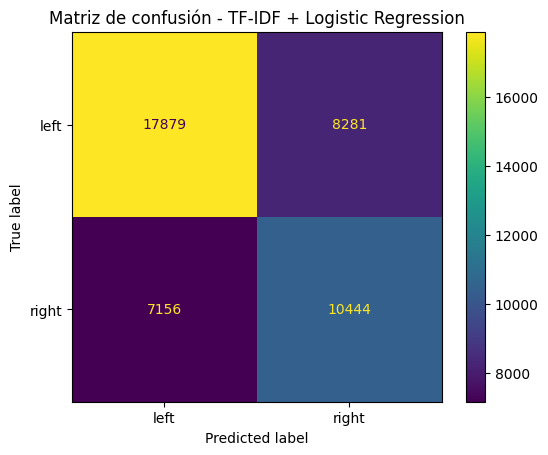

{'model': 'TF-IDF + Logistic Regression',
 'test_accuracy': 0.6472349177330896,
 'test_f1_macro': 0.6367488087697828,
 'test_f1_weighted': 0.6488215851955941,
 'best_cv_f1_macro': 0.6835324347070382,
 'best_params': {'clf__C': 2,
  'clf__class_weight': 'balanced',
  'tfidf__max_df': 0.85,
  'tfidf__max_features': 50000,
  'tfidf__min_df': 2,
  'tfidf__ngram_range': [1, 1]}}

In [60]:
tfidf_logreg_results = evaluate_classification_model(
    model=best_tfidf_logreg,
    X_test=X_test_text,
    y_test=y_test,
    model_name="TF-IDF + Logistic Regression"
)

tfidf_logreg_results["best_cv_f1_macro"] = best_cv_f1_macro_tfidf_logreg
tfidf_logreg_results["best_params"] = best_params_tfidf_logreg

tfidf_logreg_results

El modelo `TF-IDF + Logistic Regression` obtiene un rendimiento razonable como primer modelo supervisado.

La accuracy es `0.6472`, es decir, el modelo acierta aproximadamente el 65% de los tweets del conjunto de test. El `F1-macro` es `0.6367`, un valor algo menor que el `F1-weighted`, lo que indica que el rendimiento no es igual en las dos clases.

Al revisar el informe por clase, se observa que el modelo funciona mejor para la clase `left`, con un `f1-score` de `0.70`, que para la clase `right`, donde obtiene un `f1-score` de `0.58`. Esto puede estar relacionado con que la clase `left` tiene más ejemplos en el dataset.

Aun así, el modelo también consigue detectar parte de los tweets de la clase `right`, con un recall de `0.59`. Por tanto, no se limita únicamente a predecir la clase mayoritaria, aunque todavía tiene más dificultad con esta clase.

En conjunto, este resultado muestra que TF-IDF combinado con regresión logística es una baseline sólida. No es el mejor enfoque posible, porque no captura contexto profundo como BERT, pero sirve como referencia inicial para comparar el resto de modelos.

### Registro de resultados del modelo

Los resultados obtenidos por el modelo TF-IDF + Logistic Regression se incorporan a un archivo común de resultados. Si el archivo ya existe, se elimina previamente cualquier resultado anterior del mismo modelo para evitar duplicados.

Este archivo permitirá construir posteriormente una tabla comparativa con todos los modelos evaluados.


In [61]:
# Se actualiza la tabla global de resultados evitando duplicados por nombre de modelo.
model_results_df = update_model_results(tfidf_logreg_results)

model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


## 3.2 Modelo Scikit-learn: Word2Vec promedio + Logistic Regression

En este experimento se utiliza Word2Vec como estrategia de representación vectorial. Cada tweet se transforma en un vector denso calculado como el promedio de los embeddings de las palabras que contiene.

Para mantener una comparación controlada con el modelo anterior, se utiliza de nuevo Logistic Regression como clasificador. De este modo, la diferencia principal entre ambos experimentos es la representación textual utilizada: TF-IDF frente a Word2Vec promedio.

El modelo Word2Vec se integra dentro de un `Pipeline`, de forma que sus embeddings se aprenden únicamente a partir de los textos de entrenamiento de cada fold. Esto evita que información de la partición de validación influya en la representación vectorial.

Este experimento permite evaluar si una representación semántica densa basada en embeddings promedio mejora o no el rendimiento obtenido con una representación léxica dispersa como TF-IDF.


In [62]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid

# Se define un Pipeline para que Word2Vec y el clasificador se ajusten juntos
# dentro de cada fold de validación cruzada.
pipe_w2v_logreg = Pipeline([
    ("w2v", MeanWord2VecVectorizer(
        workers=4,
        seed=RANDOM_STATE
    )),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

# Se define el espacio de búsqueda de hiperparámetros para Word2Vec
# y para el clasificador de regresión logística.
param_grid_w2v_logreg = {
    "w2v__vector_size": [100],
    "w2v__window": [3, 5],
    "w2v__min_count": [3, 5],
    "w2v__sg": [0, 1],
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

# Se muestra el número de configuraciones que se evaluarán.
n_configurations_w2v_logreg = len(list(ParameterGrid(param_grid_w2v_logreg)))
n_total_fits_w2v_logreg = n_configurations_w2v_logreg * cv.get_n_splits()

print("Configuraciones evaluadas:", n_configurations_w2v_logreg)
print("Entrenamientos totales con CV:", n_total_fits_w2v_logreg)

Configuraciones evaluadas: 48
Entrenamientos totales con CV: 240


Se configura la búsqueda de hiperparámetros para Word2Vec promedio + Logistic Regression mediante `GridSearchCV`.

La métrica principal de selección vuelve a ser `F1-macro`, y la validación cruzada utiliza el mismo objeto `StratifiedGroupKFold` definido previamente. De esta forma, se mantiene una comparación coherente con el modelo TF-IDF + Logistic Regression.

In [63]:
from sklearn.model_selection import GridSearchCV

# Se configura la búsqueda de hiperparámetros usando F1-macro como métrica principal.
grid_w2v_logreg = GridSearchCV(
    estimator=pipe_w2v_logreg,
    param_grid=param_grid_w2v_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=2,
    verbose=3,
    return_train_score=True
)

Para evitar recalcular una búsqueda de hiperparámetros costosa, se definen rutas específicas de caché para el modelo Word2Vec + Logistic Regression.

In [64]:
from pathlib import Path
import joblib
import json
import pandas as pd
import time

# Se activa únicamente si se desea repetir la búsqueda de hiperparámetros completa.
FORCE_RETRAIN_W2V_LOGREG_GRID = False

# Se define un directorio centralizado para guardar modelos y resultados intermedios.
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Se define un nombre identificativo para el experimento.
w2v_logreg_model_name = "w2v_logreg"

# Se definen las rutas donde se guardarán el mejor modelo, el objeto GridSearchCV,
# los mejores hiperparámetros y los resultados completos de validación cruzada.
w2v_logreg_best_model_path = MODELS_DIR / f"{w2v_logreg_model_name}_best_estimator.joblib"
w2v_logreg_gridsearch_path = MODELS_DIR / f"{w2v_logreg_model_name}_gridsearch.joblib"
w2v_logreg_best_params_path = MODELS_DIR / f"{w2v_logreg_model_name}_best_params.json"
w2v_logreg_cv_results_path = MODELS_DIR / f"{w2v_logreg_model_name}_cv_results.csv"

# Se comprueba si existen resultados previos guardados en disco.
w2v_logreg_is_cached = (
    w2v_logreg_best_model_path.exists()
    and w2v_logreg_cv_results_path.exists()
    and w2v_logreg_best_params_path.exists()
)

# Se decide si se debe ejecutar la búsqueda de hiperparámetros.
RUN_W2V_LOGREG_GRID = (
    FORCE_RETRAIN_W2V_LOGREG_GRID
    or not w2v_logreg_is_cached
)

print("Resultados Word2Vec + Logistic Regression en caché:", w2v_logreg_is_cached)
print("Forzar reentrenamiento:", FORCE_RETRAIN_W2V_LOGREG_GRID)
print("Ejecutar búsqueda Word2Vec + Logistic Regression:", RUN_W2V_LOGREG_GRID)

if w2v_logreg_is_cached and not RUN_W2V_LOGREG_GRID:
    # Si el modelo, los resultados y los hiperparámetros ya existen,
    # se cargan desde disco para evitar repetir la búsqueda.
    best_w2v_logreg = joblib.load(w2v_logreg_best_model_path)
    cv_results_w2v_logreg = pd.read_csv(w2v_logreg_cv_results_path)

    # Se cargan los mejores hiperparámetros guardados en formato JSON.
    with open(w2v_logreg_best_params_path, "r", encoding="utf-8") as f:
        best_params_w2v_logreg = json.load(f)

    # Se recupera el mejor F1-macro medio obtenido en validación cruzada.
    best_cv_f1_macro_w2v_logreg = cv_results_w2v_logreg["mean_test_score"].max()

    print("Modelo Word2Vec + Logistic Regression cargado desde caché.")
    print("No se ha repetido el entrenamiento en esta ejecución.")
    print("Mejor F1-macro medio en CV:", round(best_cv_f1_macro_w2v_logreg, 4))
    print("Mejores hiperparámetros:")
    print(best_params_w2v_logreg)

else:
    print("Entrenando Word2Vec + Logistic Regression con GridSearchCV...")

    # Se registra el instante inicial para medir el tiempo total de entrenamiento.
    start_time = time.perf_counter()

    # Se ejecuta la búsqueda de hiperparámetros usando los grupos de clusters
    # para evitar fuga de información entre entrenamiento y validación.
    grid_w2v_logreg.fit(
        X_train_text,
        y_train,
        groups=groups_train
    )

    # Se calcula el tiempo total transcurrido durante la búsqueda de hiperparámetros.
    training_time_seconds_w2v_logreg = time.perf_counter() - start_time
    training_time_minutes_w2v_logreg = training_time_seconds_w2v_logreg / 60

    # Se recupera el mejor estimador, los mejores hiperparámetros y la mejor métrica CV.
    best_w2v_logreg = grid_w2v_logreg.best_estimator_
    best_params_w2v_logreg = grid_w2v_logreg.best_params_
    best_cv_f1_macro_w2v_logreg = grid_w2v_logreg.best_score_

    # Se convierte el resultado completo de GridSearchCV en DataFrame para su análisis.
    cv_results_w2v_logreg = pd.DataFrame(grid_w2v_logreg.cv_results_)

    # Se guardan el mejor estimador y el objeto GridSearchCV completo.
    joblib.dump(best_w2v_logreg, w2v_logreg_best_model_path)
    joblib.dump(grid_w2v_logreg, w2v_logreg_gridsearch_path)

    # Se guardan los mejores hiperparámetros en formato JSON.
    with open(w2v_logreg_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_params_w2v_logreg, f, indent=4)

    # Se exportan los resultados de validación cruzada a CSV.
    cv_results_w2v_logreg.to_csv(w2v_logreg_cv_results_path, index=False)

    print("Modelo Word2Vec + Logistic Regression entrenado y guardado.")
    print("Tiempo de entrenamiento:")
    print(f"- Segundos: {training_time_seconds_w2v_logreg:.2f}")
    print(f"- Minutos: {training_time_minutes_w2v_logreg:.2f}")
    print("Mejor F1-macro medio en CV:", round(best_cv_f1_macro_w2v_logreg, 4))
    print("Mejores hiperparámetros:")
    print(best_params_w2v_logreg)

# Se comprueba que el modelo cargado o entrenado corresponde realmente
# a un Pipeline con Word2Vec.
assert "w2v" in best_w2v_logreg.named_steps, (
    "El modelo cargado no contiene un paso Word2Vec."
)

# Se comprueba que no se haya cargado accidentalmente un Pipeline de TF-IDF.
assert "tfidf" not in best_w2v_logreg.named_steps, (
    "Se ha cargado por error un modelo TF-IDF."
)

# Se comprueba que los hiperparámetros cargados no pertenezcan a TF-IDF.
assert not any(
    key.startswith("tfidf__")
    for key in best_params_w2v_logreg.keys()
), (
    "Se han encontrado hiperparámetros de TF-IDF en el modelo Word2Vec."
)

print("Comprobación del Pipeline correcta:", best_w2v_logreg.named_steps.keys())

Resultados Word2Vec + Logistic Regression en caché: True
Forzar reentrenamiento: False
Ejecutar búsqueda Word2Vec + Logistic Regression: False
Modelo Word2Vec + Logistic Regression cargado desde caché.
No se ha repetido el entrenamiento en esta ejecución.
Mejor F1-macro medio en CV: 0.5869
Mejores hiperparámetros:
{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}
Comprobación del Pipeline correcta: dict_keys(['w2v', 'clf'])


La siguiente tabla resume las mejores configuraciones evaluadas por `GridSearchCV` para el modelo Word2Vec promedio + Logistic Regression. Los resultados se ordenan según el valor medio de `F1-macro` obtenido en validación cruzada.

In [65]:
cv_results_w2v_logreg_summary = cv_results_w2v_logreg.copy()

cv_results_w2v_logreg_summary["generalization_gap"] = (
    cv_results_w2v_logreg_summary["mean_train_score"]
    - cv_results_w2v_logreg_summary["mean_test_score"]
)

cv_results_w2v_logreg_summary = (
    cv_results_w2v_logreg_summary[
        [
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "generalization_gap",
            "params"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

cv_results_w2v_logreg_summary

,mean_test_score,std_test_score,mean_train_score,std_train_score,generalization_gap,params
31,0.586910,0.005124,0.591605,0.002237,0.004695,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}"
47,0.586599,0.003496,0.591478,0.002229,0.004879,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}"
11,0.586529,0.005445,0.590758,0.001234,0.004229,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'w2v__min_count': 3, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}"
43,0.586238,0.004689,0.590856,0.001610,0.004617,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'w2v__min_count': 3, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}"
27,0.586109,0.004270,0.589142,0.001627,0.003032,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 3, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}"
15,0.585990,0.004852,0.590690,0.001006,0.004700,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}"
30,0.579630,0.003884,0.585243,0.001686,0.005613,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 3}"
46,0.579051,0.004366,0.584373,0.001661,0.005321,"{'clf__C': 10, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 3}"
26,0.578701,0.003904,0.583848,0.001281,0.005148,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 3, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 3}"
10,0.578623,0.003214,0.584232,0.001527,0.005608,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'w2v__min_count': 3, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 3}"


Una vez seleccionado el mejor modelo mediante validación cruzada, se evalúa sobre el conjunto de test final. Esta evaluación se realiza una única vez y permite estimar el rendimiento del modelo sobre datos no utilizados durante la selección de hiperparámetros.

Resultados para Word2Vec average + Logistic Regression
Accuracy: 0.5986
F1-macro: 0.589
F1-weighted: 0.6013

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.68      0.63      0.65     26160
       right       0.50      0.55      0.53     17600

    accuracy                           0.60     43760
   macro avg       0.59      0.59      0.59     43760
weighted avg       0.61      0.60      0.60     43760



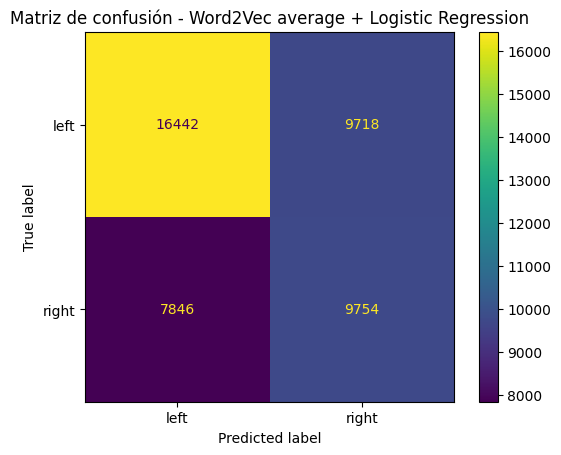

{'model': 'Word2Vec average + Logistic Regression',
 'test_accuracy': 0.5986288848263254,
 'test_f1_macro': 0.5890293834741793,
 'test_f1_weighted': 0.6013158265923567,
 'best_cv_f1_macro': 0.5869098389372477,
 'best_params': {'clf__C': 1,
  'clf__class_weight': 'balanced',
  'w2v__min_count': 5,
  'w2v__sg': 1,
  'w2v__vector_size': 100,
  'w2v__window': 5}}

In [66]:
w2v_logreg_results = evaluate_classification_model(
    model=best_w2v_logreg,
    X_test=X_test_text,
    y_test=y_test,
    model_name="Word2Vec average + Logistic Regression"
)

w2v_logreg_results["best_cv_f1_macro"] = best_cv_f1_macro_w2v_logreg
w2v_logreg_results["best_params"] = best_params_w2v_logreg

w2v_logreg_results

Los resultados obtenidos por el modelo Word2Vec average + Logistic Regression muestran un rendimiento inferior al obtenido con TF-IDF + Logistic Regression.

La accuracy es `0.5986` y el `F1-macro` es `0.5890`, por lo que el modelo queda alrededor del 60% de acierto en test. El rendimiento sigue siendo mejor para la clase `left` que para la clase `right`.

Esto puede deberse a que la representación Word2Vec average resume cada tweet como el promedio de los vectores de sus palabras. Al hacer este promedio, se pierde parte del orden, del contexto y de las expresiones concretas del texto.

Por tanto, esta representación aporta información semántica general, pero en este caso no mejora a una representación más directa como TF-IDF.

### Registro de resultados del modelo

Los resultados obtenidos por el modelo Word2Vec average + Logistic Regression se incorporan a un archivo común de resultados. Si el archivo ya existe, se elimina previamente cualquier resultado anterior del mismo modelo para evitar duplicados.

Este archivo permitirá construir posteriormente una tabla comparativa con todos los modelos evaluados.

In [67]:
# Se actualiza la tabla global de resultados evitando duplicados por nombre de modelo.
model_results_df = update_model_results(w2v_logreg_results)

model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


## 3.3 Modelo Scikit-learn: BERT embeddings + Logistic Regression

En este experimento se utilizan los embeddings contextuales `[CLS]` extraídos previamente con BERT como entrada para un clasificador de regresión logística.

A diferencia de TF-IDF y Word2Vec, en este caso la representación textual ya se ha calculado mediante un Transformer preentrenado congelado. Por tanto, el modelo de Scikit-learn no recibe texto directamente, sino vectores densos de 768 dimensiones.

Antes de entrenar el clasificador se aplica `StandardScaler`, ya que los embeddings BERT son variables numéricas continuas y el escalado puede favorecer el entrenamiento de modelos lineales regularizados como Logistic Regression.

La selección de hiperparámetros se realiza mediante `GridSearchCV` con validación cruzada estratificada y agrupada por `label`, manteniendo el conjunto de test reservado exclusivamente para la evaluación final.


In [68]:
import numpy as np
from pathlib import Path

# Se define el directorio donde se almacenan los embeddings BERT precalculados.
EMBEDDINGS_DIR = Path("data") / "embeddings"

# Se cargan los embeddings generados con MAX_LEN=96.
# El valor de MAX_LEN se incluye en el nombre para evitar cargar embeddings
# calculados con una configuración anterior.
train_bert_path = EMBEDDINGS_DIR / "train_bert_cls_maxlen96.npy"
test_bert_path = EMBEDDINGS_DIR / "test_bert_cls_maxlen96.npy"

# Si los archivos no existen, se detiene la ejecución.
assert train_bert_path.exists(), f"No se ha encontrado el archivo: {train_bert_path}"
assert test_bert_path.exists(), f"No se ha encontrado el archivo: {test_bert_path}"

# Se cargan las matrices de embeddings BERT.
X_train_bert = np.load(train_bert_path)
X_test_bert = np.load(test_bert_path)

print("Embeddings BERT de entrenamiento:", X_train_bert.shape)
print("Embeddings BERT de test:", X_test_bert.shape)

print("¿Hay valores NaN en entrenamiento?:", np.isnan(X_train_bert).any())
print("¿Hay valores NaN en test?:", np.isnan(X_test_bert).any())

Embeddings BERT de entrenamiento: (180000, 768)
Embeddings BERT de test: (43760, 768)
¿Hay valores NaN en entrenamiento?: False
¿Hay valores NaN en test?: False


Esta celda configura el modelo Scikit-learn sobre embeddings BERT congelados: escalado de variables y Logistic Regression con búsqueda de hiperparámetros.

In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, ParameterGrid

# Se define un Pipeline para que el escalado y el clasificador se ajusten juntos
# dentro de cada fold de validación cruzada.
pipe_bert_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        random_state=RANDOM_STATE
    ))
])

# Se define el espacio de búsqueda de hiperparámetros para Logistic Regression.
param_grid_bert_logreg = {
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"]
}

# Se muestra el número de configuraciones que se evaluarán.
n_configurations_bert_logreg = len(list(ParameterGrid(param_grid_bert_logreg)))
n_total_fits_bert_logreg = n_configurations_bert_logreg * cv.get_n_splits()

print("Configuraciones evaluadas:", n_configurations_bert_logreg)
print("Entrenamientos totales con CV:", n_total_fits_bert_logreg)

# Se configura la búsqueda de hiperparámetros usando F1-macro como métrica principal.
grid_bert_logreg = GridSearchCV(
    estimator=pipe_bert_logreg,
    param_grid=param_grid_bert_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=4,
    verbose=3,
    return_train_score=True
)

Configuraciones evaluadas: 6
Entrenamientos totales con CV: 30


Para evitar recalcular una búsqueda de hiperparámetros costosa, se definen rutas específicas de caché para el modelo BERT embeddings + Logistic Regression.

La variable `FORCE_RETRAIN_BERT_LOGREG_GRID` permite decidir si se fuerza una nueva búsqueda de hiperparámetros o si se reutilizan los resultados guardados.


In [70]:
from pathlib import Path
import joblib
import json
import pandas as pd
import time

# Se activa únicamente si se desea repetir la búsqueda de hiperparámetros completa.
FORCE_RETRAIN_BERT_LOGREG_GRID = False

# Se define un directorio centralizado para guardar modelos y resultados intermedios.
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Se define un nombre identificativo para el experimento.
bert_logreg_model_name = "bert_logreg"

# Se definen las rutas donde se guardarán el mejor modelo, el objeto GridSearchCV,
# los mejores hiperparámetros y los resultados completos de validación cruzada.
bert_logreg_best_model_path = MODELS_DIR / f"{bert_logreg_model_name}_best_estimator.joblib"
bert_logreg_gridsearch_path = MODELS_DIR / f"{bert_logreg_model_name}_gridsearch.joblib"
bert_logreg_best_params_path = MODELS_DIR / f"{bert_logreg_model_name}_best_params.json"
bert_logreg_cv_results_path = MODELS_DIR / f"{bert_logreg_model_name}_cv_results.csv"

# Se comprueba si existen resultados previos guardados en disco.
bert_logreg_is_cached = (
    bert_logreg_best_model_path.exists()
    and bert_logreg_cv_results_path.exists()
    and bert_logreg_best_params_path.exists()
)

# Se decide si se debe ejecutar la búsqueda de hiperparámetros.
RUN_BERT_LOGREG_GRID = (
    FORCE_RETRAIN_BERT_LOGREG_GRID
    or not bert_logreg_is_cached
)

print("Resultados BERT embeddings + Logistic Regression en caché:", bert_logreg_is_cached)
print("Forzar reentrenamiento:", FORCE_RETRAIN_BERT_LOGREG_GRID)
print("Ejecutar búsqueda BERT embeddings + Logistic Regression:", RUN_BERT_LOGREG_GRID)

if bert_logreg_is_cached and not RUN_BERT_LOGREG_GRID:
    # Si el modelo, los resultados y los hiperparámetros ya existen,
    # se cargan desde disco para evitar repetir la búsqueda.
    best_bert_logreg = joblib.load(bert_logreg_best_model_path)
    cv_results_bert_logreg = pd.read_csv(bert_logreg_cv_results_path)

    # Se cargan los mejores hiperparámetros guardados en formato JSON.
    with open(bert_logreg_best_params_path, "r", encoding="utf-8") as f:
        best_params_bert_logreg = json.load(f)

    # Se recupera el mejor F1-macro medio obtenido en validación cruzada.
    best_cv_f1_macro_bert_logreg = cv_results_bert_logreg["mean_test_score"].max()

    print("Modelo BERT embeddings + Logistic Regression cargado desde caché.")
    print("No se ha repetido el entrenamiento en esta ejecución.")
    print("Mejor F1-macro medio en CV:", round(best_cv_f1_macro_bert_logreg, 4))
    print("Mejores hiperparámetros:")
    print(best_params_bert_logreg)

else:
    print("Entrenando BERT embeddings + Logistic Regression con GridSearchCV...")

    # Se registra el instante inicial para medir el tiempo total de entrenamiento.
    start_time = time.perf_counter()

    # Se ejecuta la búsqueda de hiperparámetros usando los grupos de clusters
    # para evitar fuga de información entre entrenamiento y validación.
    grid_bert_logreg.fit(
        X_train_bert,
        y_train,
        groups=groups_train
    )

    # Se calcula el tiempo total transcurrido durante la búsqueda de hiperparámetros.
    training_time_seconds_bert_logreg = time.perf_counter() - start_time
    training_time_minutes_bert_logreg = training_time_seconds_bert_logreg / 60

    # Se recupera el mejor estimador, los mejores hiperparámetros y la mejor métrica CV.
    best_bert_logreg = grid_bert_logreg.best_estimator_
    best_params_bert_logreg = grid_bert_logreg.best_params_
    best_cv_f1_macro_bert_logreg = grid_bert_logreg.best_score_

    # Se convierte el resultado completo de GridSearchCV en DataFrame para su análisis.
    cv_results_bert_logreg = pd.DataFrame(grid_bert_logreg.cv_results_)

    # Se guardan el mejor estimador y el objeto GridSearchCV completo.
    joblib.dump(best_bert_logreg, bert_logreg_best_model_path)
    joblib.dump(grid_bert_logreg, bert_logreg_gridsearch_path)

    # Se guardan los mejores hiperparámetros en formato JSON.
    with open(bert_logreg_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_params_bert_logreg, f, indent=4)

    # Se exportan los resultados de validación cruzada a CSV.
    cv_results_bert_logreg.to_csv(bert_logreg_cv_results_path, index=False)

    print("Modelo BERT embeddings + Logistic Regression entrenado y guardado.")
    print("Tiempo de entrenamiento:")
    print(f"- Segundos: {training_time_seconds_bert_logreg:.2f}")
    print(f"- Minutos: {training_time_minutes_bert_logreg:.2f}")
    print("Mejor F1-macro medio en CV:", round(best_cv_f1_macro_bert_logreg, 4))
    print("Mejores hiperparámetros:")
    print(best_params_bert_logreg)

Resultados BERT embeddings + Logistic Regression en caché: True
Forzar reentrenamiento: False
Ejecutar búsqueda BERT embeddings + Logistic Regression: False
Modelo BERT embeddings + Logistic Regression cargado desde caché.
No se ha repetido el entrenamiento en esta ejecución.
Mejor F1-macro medio en CV: 0.616
Mejores hiperparámetros:
{'clf__C': 0.1, 'clf__class_weight': 'balanced'}


Esta celda valida que el pipeline cargado para BERT + Logistic Regression contiene los pasos esperados y que no se han cargado parámetros de otro modelo por error.

In [71]:
# Se comprueba que el modelo cargado o entrenado contiene el escalador esperado.
assert "scaler" in best_bert_logreg.named_steps, (
    "El modelo cargado no contiene el paso esperado de escalado."
)

# Se comprueba que el modelo cargado o entrenado contiene el clasificador esperado.
assert "clf" in best_bert_logreg.named_steps, (
    "El modelo cargado no contiene el paso del clasificador."
)

# Se comprueba que no se hayan cargado accidentalmente hiperparámetros
# pertenecientes a modelos basados en TF-IDF o Word2Vec.
assert not any(
    key.startswith("tfidf__") or key.startswith("w2v__")
    for key in best_params_bert_logreg.keys()
), (
    "Se han encontrado hiperparámetros de otro modelo en BERT + Logistic Regression."
)

print("Comprobación del Pipeline correcta:", best_bert_logreg.named_steps.keys())

Comprobación del Pipeline correcta: dict_keys(['scaler', 'clf'])


Esta celda resume las mejores configuraciones de BERT embeddings + Logistic Regression según los resultados de validación.

In [72]:
cv_results_bert_logreg_summary = cv_results_bert_logreg.copy()

cv_results_bert_logreg_summary["generalization_gap"] = (
    cv_results_bert_logreg_summary["mean_train_score"]
    - cv_results_bert_logreg_summary["mean_test_score"]
)

cv_results_bert_logreg_summary = (
    cv_results_bert_logreg_summary[
        [
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "generalization_gap",
            "params"
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
)

cv_results_bert_logreg_summary

,mean_test_score,std_test_score,mean_train_score,std_train_score,generalization_gap,params
1,0.615989,0.007065,0.629201,0.001826,0.013212,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}"
3,0.615980,0.007190,0.629197,0.001840,0.013217,"{'clf__C': 1, 'clf__class_weight': 'balanced'}"
5,0.615929,0.007161,0.629203,0.001832,0.013274,"{'clf__C': 10, 'clf__class_weight': 'balanced'}"
4,0.610350,0.009290,0.623144,0.002052,0.012793,"{'clf__C': 10, 'clf__class_weight': None}"
2,0.610332,0.009284,0.623144,0.002054,0.012812,"{'clf__C': 1, 'clf__class_weight': None}"
0,0.610321,0.009281,0.623128,0.002024,0.012807,"{'clf__C': 0.1, 'clf__class_weight': None}"


Una vez seleccionado el mejor modelo mediante validación cruzada, se evalúa sobre el conjunto de test final. Esta evaluación se realiza una única vez y permite estimar el rendimiento del modelo sobre datos no utilizados durante la selección de hiperparámetros.

Resultados para BERT [CLS] embeddings + Logistic Regression
Accuracy: 0.6034
F1-macro: 0.5939
F1-weighted: 0.606

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.68      0.63      0.66     26160
       right       0.51      0.56      0.53     17600

    accuracy                           0.60     43760
   macro avg       0.59      0.60      0.59     43760
weighted avg       0.61      0.60      0.61     43760



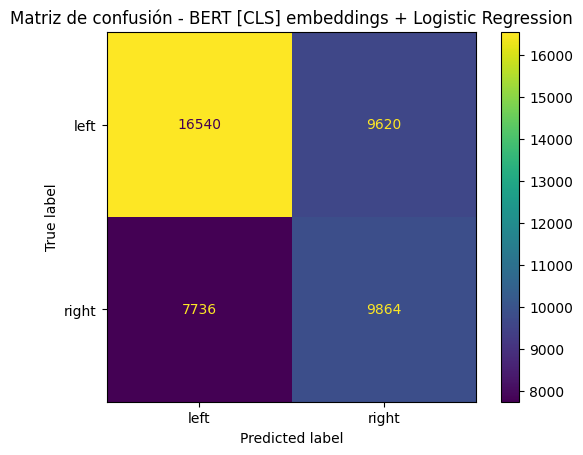

{'model': 'BERT [CLS] embeddings + Logistic Regression',
 'test_accuracy': 0.603382084095064,
 'test_f1_macro': 0.5939310838225438,
 'test_f1_weighted': 0.6060492028058829,
 'best_cv_f1_macro': 0.615989182690829,
 'best_params': {'clf__C': 0.1, 'clf__class_weight': 'balanced'}}

In [73]:
bert_logreg_results = evaluate_classification_model(
    model=best_bert_logreg,
    X_test=X_test_bert,
    y_test=y_test,
    model_name="BERT [CLS] embeddings + Logistic Regression"
)

bert_logreg_results["best_cv_f1_macro"] = best_cv_f1_macro_bert_logreg
bert_logreg_results["best_params"] = best_params_bert_logreg

bert_logreg_results

Esta celda evalúa BERT embeddings + Logistic Regression sobre el test final y añade los mejores hiperparámetros a la fila de resultados.

El modelo `BERT [CLS] embeddings + Logistic Regression` obtiene un rendimiento parecido al de Word2Vec average, aunque algo mejor.

La accuracy es `0.6034`, es decir, acierta alrededor del 60% de los tweets del conjunto de test. El `F1-macro` es `0.5939`, por lo que queda por debajo del modelo `TF-IDF + Logistic Regression`.

Por clases, se vuelve a ver que el modelo funciona mejor con `left` que con `right`. Para `left` obtiene un `f1-score` de `0.66`, mientras que para `right` baja a `0.53`.

Aunque BERT es un modelo más avanzado, aquí se usan los embeddings `[CLS]` congelados, sin hacer fine-tuning. Esto significa que BERT no se adapta a la tarea concreta, sino que solo se usa como extractor de características.

Por tanto, este resultado muestra que usar embeddings BERT congelados no mejora automáticamente a una representación más simple como TF-IDF. Para aprovechar mejor BERT, más adelante se prueba el ajuste fino del Transformer.

### Registro de resultados del modelo

Los resultados obtenidos por el modelo BERT [CLS] embeddings + Logistic Regression se incorporan a un archivo común de resultados. Si el archivo ya existe, se elimina previamente cualquier resultado anterior del mismo modelo para evitar duplicados.

Este archivo permitirá construir posteriormente una tabla comparativa con todos los modelos evaluados.


In [74]:
model_results_df = update_model_results(bert_logreg_results)
model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)
model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


## Funciones auxiliares comunes para los modelos PyTorch

En esta sección se definen las clases y funciones auxiliares reutilizadas por los modelos PyTorch de los apartados 3.4, 3.5 y 3.6. Se centralizan aquí para evitar duplicidades y mantener una implementación coherente entre las distintas representaciones vectoriales.

In [75]:
# Imports comunes para los modelos PyTorch de los apartados 3.4, 3.5 y 3.6.
import ast
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tqdm.auto import tqdm

# Se reutiliza la semilla global para mantener reproducibilidad.
RANDOM_STATE = 42

# Se selecciona el dispositivo de ejecución.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))

Dispositivo utilizado: cuda
GPU detectada: NVIDIA GeForce RTX 4060


### Definición del Dataset de PyTorch

Para entrenar un modelo en PyTorch se necesita un objeto `Dataset`, que define cómo acceder a los datos y etiquetas.

En este caso, cada muestra está formada por:

- un vector de características denso;
- su etiqueta codificada numéricamente.

Esta clase permite utilizar posteriormente `DataLoader` para crear lotes de entrenamiento y evaluación.

In [76]:
# Se define un Dataset de PyTorch para trabajar con embeddings precomputados.
class EmbeddingDataset(Dataset):
    """
    Dataset para representaciones vectoriales densas de texto.

    Cada elemento contiene:
    - un vector de características;
    - una etiqueta de clase codificada numéricamente.
    """

    def __init__(self, X, y):
        # Se convierten los embeddings a tensores float32, formato esperado por la red neuronal.
        self.X = torch.tensor(X, dtype=torch.float32)
        
        # Se convierten las etiquetas a tensores long, formato requerido por CrossEntropyLoss.
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        # Se devuelve el número total de muestras del dataset.
        return len(self.X)

    def __getitem__(self, idx):
        # Se devuelve una muestra individual: embedding y etiqueta asociada.
        return self.X[idx], self.y[idx]

### Definición de la red neuronal MLP

Se define una red neuronal feed-forward o MLP (*Multi-Layer Perceptron*) para clasificar vectores de características.

Esta misma clase se reutiliza después con distintas representaciones del texto, como embeddings BERT `[CLS]`, TF-IDF reducido con `TruncatedSVD` y Word2Vec average.

La red permite configurar una o varias capas ocultas mediante el parámetro `hidden_layers`, así como la tasa de `dropout`. Esto permite comparar distintas arquitecturas durante la búsqueda de hiperparámetros sin tener que definir una red distinta para cada representación.

In [77]:
# Se define una red neuronal feed-forward usada como clasificador sobre embeddings densos.
class MLPClassifier(nn.Module):
    """
    Red neuronal feed-forward para clasificación binaria
    """

    def __init__(self, input_dim, hidden_layers=(256,), dropout=0.3, num_classes=2):
        super().__init__()

        # Se inicializa una lista donde se irán acumulando las capas de la red.
        layers = []
        
        # La primera capa recibe como entrada la dimensión del embedding.
        previous_dim = input_dim

        # Se añaden las capas ocultas configuradas en hidden_layers.
        for hidden_dim in hidden_layers:
            # Capa lineal que transforma la representación anterior.
            layers.append(nn.Linear(previous_dim, hidden_dim))
            
            # Función de activación no lineal.
            layers.append(nn.ReLU())
            
            # Dropout para reducir sobreajuste durante el entrenamiento.
            layers.append(nn.Dropout(dropout))
            
            # Se actualiza la dimensión de entrada para la siguiente capa.
            previous_dim = hidden_dim

        # Capa final de clasificación.
        # Produce una puntuación por cada clase.
        layers.append(nn.Linear(previous_dim, num_classes))

        # Se agrupan todas las capas en un módulo secuencial.
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Se propaga la entrada por la red neuronal.
        return self.network(x)

### Funciones auxiliares de entrenamiento y evaluación

En esta celda se definen funciones reutilizables para entrenar y evaluar la red neuronal.

También se incluye una función para calcular pesos de clase a partir del fold de entrenamiento. Esto permite compensar posibles desequilibrios entre clases sin utilizar información del fold de validación, evitando fuga de datos.


In [78]:
# Se calculan pesos de clase para compensar posibles desequilibrios durante el entrenamiento.
def compute_class_weights(y_fold, n_classes, device):
    """
    Se calculan pesos de clase inversamente proporcionales a la frecuencia de cada clase.

    Los pesos se calculan únicamente a partir del fold de entrenamiento para evitar
    utilizar información del fold de validación.
    """
    # Se cuenta cuántas muestras hay de cada clase.
    counts = np.bincount(y_fold, minlength=n_classes)
    
    # Se evita que alguna clase tenga frecuencia cero.
    counts = np.maximum(counts, 1)

    # Se calcula el peso inversamente proporcional a la frecuencia de cada clase.
    total = counts.sum()
    weights = total / (n_classes * counts)

    # Se devuelven los pesos como tensor en el dispositivo correspondiente.
    return torch.tensor(weights, dtype=torch.float32).to(device)


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Se entrena el modelo durante una época.
    """
    # Se activa el modo entrenamiento.
    model.train()

    total_loss = 0.0

    # Se recorren los lotes generados por el DataLoader.
    for X_batch, y_batch in dataloader:
        # Se mueven los datos al dispositivo de ejecución.
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Se limpian gradientes acumulados antes de calcular el nuevo paso de optimización.
        optimizer.zero_grad()

        # Se calculan las salidas del modelo y la pérdida asociada.
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        # Se propaga el error hacia atrás para calcular gradientes.
        loss.backward()
        
        # Se actualizan los pesos del modelo usando los gradientes calculados.
        optimizer.step()

        # Se acumula la pérdida ponderada por el tamaño del lote.
        total_loss += loss.item() * X_batch.size(0)

    # Se devuelve la pérdida media de entrenamiento.
    return total_loss / len(dataloader.dataset)


def evaluate_pytorch_model(model, dataloader, criterion, device):
    """
    Se evalúa el modelo y se devuelven la pérdida, accuracy, F1-macro,
    predicciones y etiquetas reales.
    """
    # Se activa el modo evaluación.
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    # Se desactivan gradientes durante la evaluación para ahorrar memoria
    # y evitar modificar los pesos del modelo.
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            # Se mueven los datos al dispositivo de ejecución.
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Se calculan las salidas del modelo y la pérdida del lote.
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            # Se obtiene la clase predicha como la de mayor puntuación.
            preds = torch.argmax(logits, dim=1)

            # Se acumula la pérdida ponderada por el tamaño del lote.
            total_loss += loss.item() * X_batch.size(0)

            # Se guardan predicciones y etiquetas reales en CPU para calcular métricas.
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    # Se calcula la pérdida media y las métricas de clasificación.
    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")

    # Se devuelven métricas y arrays de predicciones/etiquetas.
    return avg_loss, accuracy, f1_macro, np.array(all_preds), np.array(all_labels)

## 3.4 Red neuronal en PyTorch sobre embeddings BERT

En este experimento se entrena una red neuronal feed-forward implementada en PyTorch utilizando como entrada los embeddings BERT `[CLS]` calculados previamente.

El objetivo es comparar un clasificador neuronal con los modelos de Scikit-learn anteriores. A diferencia de la regresión logística aplicada sobre embeddings BERT, aquí se utiliza una arquitectura no lineal capaz de aprender combinaciones más complejas entre las dimensiones del embedding.

Para evitar una selección arbitraria de hiperparámetros, se evalúan varias configuraciones mediante validación cruzada estratificada y agrupada por `label`. La métrica principal de selección vuelve a ser `F1-macro`, ya que permite comparar el rendimiento teniendo en cuenta ambas clases.

### Carga de embeddings BERT

La red neuronal no recibe texto directamente, sino los embeddings BERT `[CLS]` generados previamente en el apartado de representación vectorial.

En esta celda se cargan los ficheros `.npy` con los embeddings de entrenamiento y test. También se comprueba que el número de vectores coincide con el número de etiquetas, evitando errores de alineación entre datos y clases.

Es importante destacar que aquí no se vuelve a ejecutar BERT: solo se reutilizan los vectores ya calculados.

In [79]:
# Se define el directorio donde se almacenan los embeddings BERT calculados previamente.
EMBEDDINGS_DIR = Path("data") / "embeddings"

# Se cargan los mismos embeddings BERT usados en el modelo BERT + Logistic Regression.
# El sufijo maxlen96 identifica la configuración usada durante la extracción.
train_bert_path = EMBEDDINGS_DIR / "train_bert_cls_maxlen96.npy"
test_bert_path = EMBEDDINGS_DIR / "test_bert_cls_maxlen96.npy"

# Se comprueba que los ficheros de embeddings existen antes de cargarlos.
assert train_bert_path.exists(), f"Fichero no encontrado: {train_bert_path}"
assert test_bert_path.exists(), f"Fichero no encontrado: {test_bert_path}"

# Se cargan los embeddings BERT precomputados.
X_train_bert = np.load(train_bert_path)
X_test_bert = np.load(test_bert_path)

print("Embeddings BERT de entrenamiento:", X_train_bert.shape)
print("Embeddings BERT de test:", X_test_bert.shape)

assert X_train_bert.shape[0] == len(y_train), "Desajuste entre X_train_bert e y_train"
assert X_test_bert.shape[0] == len(y_test), "Desajuste entre X_test_bert e y_test"

print("¿Hay valores NaN en entrenamiento?:", np.isnan(X_train_bert).any())
print("¿Hay valores NaN en test?:", np.isnan(X_test_bert).any())

Embeddings BERT de entrenamiento: (180000, 768)
Embeddings BERT de test: (43760, 768)
¿Hay valores NaN en entrenamiento?: False
¿Hay valores NaN en test?: False


### Codificación de etiquetas

PyTorch necesita que las clases estén codificadas como valores numéricos. Por este motivo, las etiquetas originales (`left` y `right`) se transforman a enteros mediante `LabelEncoder`.

Esta transformación solo afecta a la representación interna de las etiquetas para el entrenamiento. Al final del proceso, las predicciones se convertirán de nuevo a sus nombres originales para interpretar los resultados.

In [80]:
# Se inicializa el codificador de etiquetas.
label_encoder = LabelEncoder()

# Se ajusta el codificador con las etiquetas de entrenamiento
# y se transforman train y test a valores numéricos.
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Se muestran las clases originales y sus valores codificados.
print("Clases originales:", label_encoder.classes_)
print("Etiquetas codificadas en train:", np.unique(y_train_enc))
print("Etiquetas codificadas en test:", np.unique(y_test_enc))

Clases originales: ['left' 'right']
Etiquetas codificadas en train: [0 1]
Etiquetas codificadas en test: [0 1]


### Entrenamiento de una configuración en un fold

Esta función entrena una configuración concreta de la red neuronal sobre un fold de entrenamiento y la evalúa sobre su fold de validación.

Para evitar fuga de datos, el `StandardScaler` se ajusta únicamente con los embeddings del fold de entrenamiento y después se aplica al fold de validación.

Además, se utiliza *early stopping* basado en `F1-macro` de validación. Esto permite detener el entrenamiento si el modelo deja de mejorar, reduciendo sobreajuste y coste computacional.

In [81]:
# Se entrena y valida una configuración concreta de MLP dentro de la búsqueda de hiperparámetros.
def train_mlp_configuration(
    X,
    y,
    train_idx,
    val_idx,
    hidden_layers=(256,),
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    max_epochs=10,
    patience=2,
    random_state=42
):
    """
    Se entrena una configuración concreta del MLP sobre un fold de entrenamiento
    y se evalúa sobre el fold de validación.

    El escalador se ajusta únicamente sobre el fold de entrenamiento para evitar
    fuga de información. El early stopping se basa en el F1-macro de validación.
    """
    # Se fijan semillas para mejorar la reproducibilidad del entrenamiento.
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Se separan embeddings y etiquetas según los índices del fold.
    X_train_fold = X[train_idx]
    X_val_fold = X[val_idx]

    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]

    # Se ajusta el escalador solo con el fold de entrenamiento.
    # Después se aplica el mismo escalado al fold de validación.
    scaler = StandardScaler()
    X_train_fold = scaler.fit_transform(X_train_fold).astype(np.float32)
    X_val_fold = scaler.transform(X_val_fold).astype(np.float32)

    # Se construyen los datasets de PyTorch para entrenamiento y validación.
    train_dataset = EmbeddingDataset(X_train_fold, y_train_fold)
    val_dataset = EmbeddingDataset(X_val_fold, y_val_fold)

    # DataLoader de entrenamiento con shuffle para variar el orden de los lotes.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # DataLoader de validación sin shuffle para evaluación determinista.
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Se inicializa el modelo con la configuración de hiperparámetros recibida.
    model = MLPClassifier(
        input_dim=X.shape[1],
        hidden_layers=hidden_layers,
        dropout=dropout,
        num_classes=len(np.unique(y))
    ).to(device)

    # Se calculan pesos de clase usando únicamente las etiquetas del fold de entrenamiento.
    class_weights = compute_class_weights(
        y_train_fold,
        n_classes=len(np.unique(y)),
        device=device
    )

    # Se define la función de pérdida ponderada por clase.
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Se define el optimizador AdamW con learning rate y weight decay configurables.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # Se inicializan variables para controlar el mejor resultado de validación.
    best_val_f1 = -np.inf
    best_epoch = 0
    best_state_dict = None
    epochs_without_improvement = 0

    history = []

    # Se entrena durante un máximo de max_epochs, aplicando early stopping
    # si el F1-macro de validación deja de mejorar.
    for epoch in range(1, max_epochs + 1):
        # Se entrena una época sobre el fold de entrenamiento.
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        # Se evalúa el modelo sobre el fold de validación.
        val_loss, val_acc, val_f1, _, _ = evaluate_pytorch_model(
            model,
            val_loader,
            criterion,
            device
        )

        # Se guarda el historial de entrenamiento y validación de la época.
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1
        })

        # Se actualiza el mejor modelo si mejora el F1-macro de validación.
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state_dict = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            # Si no hay mejora, se incrementa el contador de épocas sin mejora.
            epochs_without_improvement += 1

        # Se detiene el entrenamiento si se alcanza la paciencia definida.
        if epochs_without_improvement >= patience:
            break

    # Se devuelve el mejor F1 de validación, la mejor época, el estado del modelo
    # y el historial completo del fold.
    return best_val_f1, best_epoch, best_state_dict, pd.DataFrame(history)

### Parrilla de hiperparámetros

Para evitar seleccionar hiperparámetros de forma arbitraria, se define una parrilla explícita de configuraciones.

Se comparan distintos valores de:

- número de neuronas de la capa oculta;
- tasa de dropout;
- learning rate;
- regularización `weight_decay`.

Esta metodología mantiene coherencia con los modelos de Scikit-learn, donde también se utilizó validación cruzada para seleccionar hiperparámetros.

In [82]:
# Se define la parrilla de hiperparámetros que se evaluará para la red neuronal.
# Esto evita seleccionar valores de forma arbitraria y permite comparar configuraciones.
param_grid_bert_pytorch_mlp = {
    "hidden_layers": [(256,), (512,)],
    "dropout": [0.3, 0.5],
    "lr": [1e-3, 3e-4],
    "weight_decay": [0.0, 1e-4],
    "batch_size": [256],
}

# Se generan todas las combinaciones posibles de hiperparámetros.
bert_pytorch_param_grid = list(ParameterGrid(param_grid_bert_pytorch_mlp))

# Se muestra el número total de configuraciones y entrenamientos necesarios.
print("Número de configuraciones BERT + PyTorch MLP:", len(bert_pytorch_param_grid))
print("Número total de entrenamientos con validación cruzada de 5 folds:", len(bert_pytorch_param_grid) * 5)

Número de configuraciones BERT + PyTorch MLP: 16
Número total de entrenamientos con validación cruzada de 5 folds: 80


### Validación cruzada de la red neuronal

Se evalúan las configuraciones de la parrilla mediante validación cruzada estratificada y agrupada por `label`.

La estratificación mantiene una proporción similar de clases en cada fold, mientras que la agrupación evita que tweets del mismo cluster aparezcan simultáneamente en entrenamiento y validación.

Los resultados se guardan en disco para evitar repetir el proceso en futuras ejecuciones del notebook. Solo se reentrena si se activa explícitamente `FORCE_RETRAIN_PYTORCH_MLP_CV = True`.

In [83]:
# Se activa únicamente si se desea repetir la validación cruzada completa.
# Por defecto se deja en False para reutilizar los resultados ya guardados.
FORCE_RETRAIN_BERT_PYTORCH_MLP_CV = False

# Se define el directorio donde se guardarán los resultados del MLP en PyTorch
# entrenado sobre embeddings BERT [CLS].
BERT_PYTORCH_MLP_RESULTS_DIR = Path("models") / "bert_pytorch_mlp_maxlen96"
BERT_PYTORCH_MLP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Se definen las rutas donde se guardan los resultados de validación cruzada
# y la mejor configuración de hiperparámetros.
bert_pytorch_cv_results_path = (
    BERT_PYTORCH_MLP_RESULTS_DIR / "bert_pytorch_mlp_cv_results.csv"
)

bert_pytorch_best_params_path = (
    BERT_PYTORCH_MLP_RESULTS_DIR / "bert_pytorch_mlp_best_params.json"
)

# Se comprueba si existen resultados previos guardados en disco.
bert_pytorch_cv_is_cached = (
    bert_pytorch_cv_results_path.exists()
    and bert_pytorch_best_params_path.exists()
)

# Se decide si se debe ejecutar la validación cruzada.
# Se ejecuta si se fuerza el reentrenamiento o si no existe caché previa.
RUN_BERT_PYTORCH_MLP_CV = (
    FORCE_RETRAIN_BERT_PYTORCH_MLP_CV
    or not bert_pytorch_cv_is_cached
)

print("Resultados de CV BERT + PyTorch MLP en caché:", bert_pytorch_cv_is_cached)
print("Forzar reentrenamiento de CV:", FORCE_RETRAIN_BERT_PYTORCH_MLP_CV)
print("Ejecutar CV BERT + PyTorch MLP:", RUN_BERT_PYTORCH_MLP_CV)

# Si existen resultados previos y no se fuerza el reentrenamiento,
# se cargan directamente desde disco.
if bert_pytorch_cv_is_cached and not RUN_BERT_PYTORCH_MLP_CV:
    bert_pytorch_cv_results_df = pd.read_csv(bert_pytorch_cv_results_path)

    with open(bert_pytorch_best_params_path, "r", encoding="utf-8") as f:
        best_bert_pytorch_params = json.load(f)

    print("Resultados de validación cruzada BERT + PyTorch MLP cargados desde caché.")
    print("Mejores hiperparámetros:")
    print(best_bert_pytorch_params)

else:
    # Se inicializa una lista para almacenar los resultados de cada configuración y fold.
    bert_pytorch_cv_rows = []

    # Se calcula el número total de entrenamientos que se realizarán.
    total_iterations = len(bert_pytorch_param_grid) * cv.get_n_splits(
        X_train_bert,
        y_train,
        groups_train
    )

    # Se crea una barra de progreso para monitorizar el proceso.
    progress_bar = tqdm(
        total=total_iterations,
        desc="CV BERT + PyTorch MLP",
        unit="fold"
    )

    # Se itera sobre cada configuración candidata de hiperparámetros.
    for config_id, params in enumerate(bert_pytorch_param_grid, start=1):
        fold_scores = []

        # Se evalúa la configuración actual en cada fold de la validación cruzada.
        for fold, (train_idx, val_idx) in enumerate(
            cv.split(X_train_bert, y_train, groups_train),
            start=1
        ):
            # Se entrena la configuración actual sobre el fold de entrenamiento
            # y se evalúa sobre el fold de validación.
            val_f1, best_epoch, _, history_df = train_mlp_configuration(
                X=X_train_bert,
                y=y_train_enc,
                train_idx=train_idx,
                val_idx=val_idx,
                hidden_layers=params["hidden_layers"],
                dropout=params["dropout"],
                lr=params["lr"],
                weight_decay=params["weight_decay"],
                batch_size=params["batch_size"],
                max_epochs=10,
                patience=2,
                random_state=RANDOM_STATE + fold
            )

            # Se almacena el F1-macro obtenido en el fold.
            fold_scores.append(val_f1)

            # Se registra el resultado del fold junto con la configuración evaluada.
            bert_pytorch_cv_rows.append({
                "config_id": config_id,
                "fold": fold,
                "val_f1_macro": val_f1,
                "best_epoch": best_epoch,
                "hidden_layers": str(params["hidden_layers"]),
                "dropout": params["dropout"],
                "lr": params["lr"],
                "weight_decay": params["weight_decay"],
                "batch_size": params["batch_size"]
            })

            # Se actualiza la barra de progreso.
            progress_bar.update(1)

        # Se muestra el rendimiento medio de la configuración actual.
        print(
            f"Configuración {config_id}/{len(bert_pytorch_param_grid)} "
            f"- F1-macro medio: {np.mean(fold_scores):.4f}"
        )

    progress_bar.close()

    # Se convierte la lista de resultados en un dataframe.
    bert_pytorch_cv_results_df = pd.DataFrame(bert_pytorch_cv_rows)

    # Se guardan los resultados de validación cruzada para evitar repetir entrenamientos.
    bert_pytorch_cv_results_df.to_csv(
        bert_pytorch_cv_results_path,
        index=False
    )

    # Se resume el rendimiento medio de cada configuración.
    bert_pytorch_summary = (
        bert_pytorch_cv_results_df
        .groupby([
            "config_id",
            "hidden_layers",
            "dropout",
            "lr",
            "weight_decay",
            "batch_size"
        ])
        .agg(
            mean_val_f1_macro=("val_f1_macro", "mean"),
            std_val_f1_macro=("val_f1_macro", "std"),
            mean_best_epoch=("best_epoch", "mean")
        )
        .reset_index()
        .sort_values("mean_val_f1_macro", ascending=False)
    )

    # Se selecciona la configuración con mayor F1-macro medio en validación.
    best_row = bert_pytorch_summary.iloc[0]

    # Se guardan los mejores hiperparámetros en un diccionario.
    best_bert_pytorch_params = {
        "hidden_layers": best_row["hidden_layers"],
        "dropout": float(best_row["dropout"]),
        "lr": float(best_row["lr"]),
        "weight_decay": float(best_row["weight_decay"]),
        "batch_size": int(best_row["batch_size"]),
        "mean_best_epoch": float(best_row["mean_best_epoch"]),
        "best_cv_f1_macro": float(best_row["mean_val_f1_macro"])
    }

    # Se guarda la mejor configuración en formato JSON para reutilizarla posteriormente.
    with open(bert_pytorch_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_bert_pytorch_params, f, indent=4)

    print("Mejores hiperparámetros del modelo BERT + PyTorch MLP:")
    print(best_bert_pytorch_params)

# Se muestran las primeras filas de los resultados de validación cruzada.
bert_pytorch_cv_results_df.head()

Resultados de CV BERT + PyTorch MLP en caché: True
Forzar reentrenamiento de CV: False
Ejecutar CV BERT + PyTorch MLP: False
Resultados de validación cruzada BERT + PyTorch MLP cargados desde caché.
Mejores hiperparámetros:
{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}


,config_id,fold,val_f1_macro,best_epoch,hidden_layers,dropout,lr,weight_decay,batch_size
0,1,1,0.654657,10,"(256,)",0.3,0.001,0.0,256
1,1,2,0.660319,10,"(256,)",0.3,0.001,0.0,256
2,1,3,0.654963,4,"(256,)",0.3,0.001,0.0,256
3,1,4,0.659787,10,"(256,)",0.3,0.001,0.0,256
4,1,5,0.638149,3,"(256,)",0.3,0.001,0.0,256


### Resumen de validación cruzada

En esta tabla se resume el rendimiento medio de cada configuración de la red neuronal.

La configuración final se selecciona utilizando el valor medio de `F1-macro` en validación cruzada. También se muestra la desviación estándar entre folds, que permite observar la estabilidad del modelo.

In [84]:
# Se agrupan los resultados por configuración de hiperparámetros.
# Para cada configuración se calcula:
# - el F1-macro medio en validación;
# - la desviación estándar del F1-macro entre folds;
# - la media de la mejor época alcanzada durante el entrenamiento.
bert_pytorch_summary = (
    bert_pytorch_cv_results_df
    .groupby([
        "config_id",
        "hidden_layers",
        "dropout",
        "lr",
        "weight_decay",
        "batch_size"
    ])
    .agg(
        mean_val_f1_macro=("val_f1_macro", "mean"),
        std_val_f1_macro=("val_f1_macro", "std"),
        mean_best_epoch=("best_epoch", "mean")
    )
    .reset_index()
    .sort_values("mean_val_f1_macro", ascending=False)
)

# Se muestra el resumen ordenado de mejor a peor configuración.
bert_pytorch_summary

,config_id,hidden_layers,dropout,lr,weight_decay,batch_size,mean_val_f1_macro,std_val_f1_macro,mean_best_epoch
3,4,"(256,)",0.3,0.0003,0.0001,256,0.660984,0.007885,8.8
2,3,"(256,)",0.3,0.0003,0.0000,256,0.660617,0.007491,8.8
7,8,"(512,)",0.3,0.0003,0.0001,256,0.659794,0.006442,8.0
6,7,"(512,)",0.3,0.0003,0.0000,256,0.659793,0.007293,7.4
14,15,"(512,)",0.5,0.0003,0.0000,256,0.658021,0.008740,7.6
10,11,"(256,)",0.5,0.0003,0.0000,256,0.657766,0.008667,9.2
15,16,"(512,)",0.5,0.0003,0.0001,256,0.657737,0.008744,7.2
11,12,"(256,)",0.5,0.0003,0.0001,256,0.657246,0.009094,9.4
1,2,"(256,)",0.3,0.0010,0.0001,256,0.655531,0.005425,8.0
0,1,"(256,)",0.3,0.0010,0.0000,256,0.653575,0.009016,7.4


La tabla resume el rendimiento de cada configuración del modelo BERT `[CLS]` + PyTorch MLP evaluada mediante validación cruzada. La columna `mean_val_f1_macro` se utiliza como criterio principal de selección, mientras que `std_val_f1_macro` permite valorar la estabilidad del rendimiento entre folds.

La columna `mean_best_epoch` indica en qué época, de media, se obtuvo el mejor rendimiento durante la validación. Este valor se utilizará posteriormente para definir el número de épocas del entrenamiento final del modelo BERT `[CLS]` + PyTorch MLP.

### Preparación de la mejor configuración

La mejor configuración se obtiene a partir de la validación cruzada. Como las capas ocultas se guardan en formato texto dentro del CSV, se convierten de nuevo a una tupla de Python.

También se define el número de épocas del entrenamiento final a partir de la media de las mejores épocas observadas durante la validación cruzada.

In [85]:
# Se convierte la configuración de capas ocultas guardada en texto
# a una tupla de Python, que es el formato esperado por la clase MLPClassifier.
def parse_hidden_layers(hidden_layers_value):
    """
    Se convierte el valor de hidden_layers a una tupla de Python.

    Esta conversión es necesaria porque, al guardar los resultados en CSV o JSON,
    una tupla como (512,) puede quedar almacenada como texto.
    """
    if isinstance(hidden_layers_value, str):
        parsed = ast.literal_eval(hidden_layers_value)
        return tuple(parsed)

    if isinstance(hidden_layers_value, list):
        return tuple(hidden_layers_value)

    return tuple(hidden_layers_value)


# Se recupera la mejor arquitectura de capas ocultas para el modelo BERT + PyTorch MLP.
best_bert_pytorch_hidden_layers = parse_hidden_layers(
    best_bert_pytorch_params["hidden_layers"]
)

# Se define el número de épocas del modelo final a partir de la media de las mejores épocas
# obtenidas durante la validación cruzada.
best_bert_pytorch_epochs = max(
    1,
    int(round(best_bert_pytorch_params["mean_best_epoch"]))
)

print("Mejores capas ocultas para BERT + PyTorch MLP:", best_bert_pytorch_hidden_layers)
print("Épocas para entrenar el modelo final BERT + PyTorch MLP:", best_bert_pytorch_epochs)

Mejores capas ocultas para BERT + PyTorch MLP: (256,)
Épocas para entrenar el modelo final BERT + PyTorch MLP: 9


### Entrenamiento final con todo el conjunto de entrenamiento

Una vez seleccionada la mejor configuración mediante validación cruzada, se entrena un modelo final usando todo `train_public`.

El `StandardScaler` se ajusta ahora sobre todo el conjunto de entrenamiento y se guarda junto con el modelo. Esto es necesario porque el mismo escalado debe aplicarse posteriormente al conjunto de test.

El modelo final también se guarda en disco para evitar reentrenamientos innecesarios.

In [86]:
# Se entrena el MLP final con la mejor configuración seleccionada en validación cruzada.
def train_final_mlp_model(
    X,
    y,
    hidden_layers,
    dropout,
    lr,
    weight_decay,
    batch_size,
    n_epochs,
    random_state=42
):
    """
    Se entrena el modelo MLP final sobre todo el conjunto de entrenamiento.

    El escalador se ajusta sobre todo `train_public` y posteriormente se reutiliza
    para transformar el conjunto de test final.
    """
    # Se fijan semillas para mejorar la reproducibilidad del entrenamiento.
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Se ajusta el escalador con todo el conjunto de entrenamiento.
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    # Se construye el Dataset de PyTorch para el entrenamiento final.
    train_dataset = EmbeddingDataset(X_scaled, y)

    # Se crea el DataLoader de entrenamiento.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Se inicializa el modelo final con la mejor arquitectura seleccionada.
    model = MLPClassifier(
        input_dim=X.shape[1],
        hidden_layers=hidden_layers,
        dropout=dropout,
        num_classes=len(np.unique(y))
    ).to(device)

    # Se calculan pesos de clase usando todo el conjunto de entrenamiento.
    class_weights = compute_class_weights(
        y,
        n_classes=len(np.unique(y)),
        device=device
    )

    # Se define la función de pérdida ponderada por clase.
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Se define el optimizador con los hiperparámetros seleccionados.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    training_history = []

    # Se entrena el modelo final durante el número de épocas seleccionado
    # a partir de la validación cruzada.
    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        training_history.append({
            "epoch": epoch,
            "train_loss": train_loss
        })

        print(f"Época {epoch}/{n_epochs} - pérdida de entrenamiento: {train_loss:.4f}")

    return model, scaler, pd.DataFrame(training_history)

### Carga o entrenamiento del modelo final

Esta celda comprueba si ya existe un modelo PyTorch final guardado. Si existe, se carga directamente. Si no existe, se entrena utilizando la mejor configuración obtenida en validación cruzada.

Esta estrategia evita repetir entrenamientos costosos y mejora la reproducibilidad del notebook.

In [87]:
FORCE_RETRAIN_FINAL_BERT_PYTORCH_MLP = False

bert_pytorch_model_path = (
    BERT_PYTORCH_MLP_RESULTS_DIR / "bert_pytorch_mlp_best_model.pt"
)

bert_pytorch_scaler_path = (
    BERT_PYTORCH_MLP_RESULTS_DIR / "bert_pytorch_mlp_scaler.joblib"
)

bert_pytorch_history_path = (
    BERT_PYTORCH_MLP_RESULTS_DIR / "bert_pytorch_mlp_final_training_history.csv"
)

# Se comprueba si ya existen artefactos guardados para evitar repetir entrenamientos costosos.
bert_pytorch_final_model_is_cached = (
    bert_pytorch_model_path.exists()
    and bert_pytorch_scaler_path.exists()
)

# Se decide si se debe entrenar de nuevo el modelo final.
# Se reentrena si se fuerza explícitamente o si no existe caché previa.
RUN_FINAL_BERT_PYTORCH_MLP = (
    FORCE_RETRAIN_FINAL_BERT_PYTORCH_MLP
    or not bert_pytorch_final_model_is_cached
)

print("Modelo final BERT + PyTorch MLP en caché:", bert_pytorch_final_model_is_cached)
print("Forzar reentrenamiento del modelo final:", FORCE_RETRAIN_FINAL_BERT_PYTORCH_MLP)
print("Ejecutar entrenamiento final BERT + PyTorch MLP:", RUN_FINAL_BERT_PYTORCH_MLP)

# Si la caché es válida, se carga el modelo, el escalador y el historial guardado.
if bert_pytorch_final_model_is_cached and not RUN_FINAL_BERT_PYTORCH_MLP:
    checkpoint = torch.load(
        bert_pytorch_model_path,
        map_location=device
    )

    final_bert_pytorch_mlp = MLPClassifier(
        input_dim=checkpoint["input_dim"],
        hidden_layers=tuple(checkpoint["hidden_layers"]),
        dropout=best_bert_pytorch_params["dropout"],
        num_classes=len(checkpoint["label_classes"])
    ).to(device)

    final_bert_pytorch_mlp.load_state_dict(checkpoint["model_state_dict"])

    final_bert_pytorch_scaler = joblib.load(bert_pytorch_scaler_path)

    if bert_pytorch_history_path.exists():
        final_bert_pytorch_history = pd.read_csv(bert_pytorch_history_path)
    else:
        final_bert_pytorch_history = None

    print("Modelo final BERT + PyTorch MLP cargado desde caché.")

else:
    # Si no existe caché válida, se entrena el modelo final con todo train_public.
    final_bert_pytorch_mlp, final_bert_pytorch_scaler, final_bert_pytorch_history = train_final_mlp_model(
        X=X_train_bert,
        y=y_train_enc,
        hidden_layers=best_bert_pytorch_hidden_layers,
        dropout=best_bert_pytorch_params["dropout"],
        lr=best_bert_pytorch_params["lr"],
        weight_decay=best_bert_pytorch_params["weight_decay"],
        batch_size=best_bert_pytorch_params["batch_size"],
        n_epochs=best_bert_pytorch_epochs,
        random_state=RANDOM_STATE
    )

    # Se guardan los pesos del modelo PyTorch final junto con la configuración necesaria
    # para reconstruir la arquitectura posteriormente.
    torch.save(
        {
            "model_state_dict": final_bert_pytorch_mlp.state_dict(),
            "best_params": best_bert_pytorch_params,
            "label_classes": label_encoder.classes_.tolist(),
            "input_dim": X_train_bert.shape[1],
            "hidden_layers": best_bert_pytorch_hidden_layers
        },
        bert_pytorch_model_path
    )

    # Se guarda el escalador ajustado sobre todo el conjunto de entrenamiento.
    joblib.dump(final_bert_pytorch_scaler, bert_pytorch_scaler_path)

    # Se guarda el historial de pérdidas del entrenamiento final.
    final_bert_pytorch_history.to_csv(
        bert_pytorch_history_path,
        index=False
    )

    print("Modelo final BERT + PyTorch MLP entrenado y guardado.")

Modelo final BERT + PyTorch MLP en caché: True
Forzar reentrenamiento del modelo final: False
Ejecutar entrenamiento final BERT + PyTorch MLP: False
Modelo final BERT + PyTorch MLP cargado desde caché.


### Evaluación en el conjunto de test final

Después de seleccionar los hiperparámetros mediante validación cruzada y entrenar el modelo final con todo `train_public`, se evalúa una única vez sobre `test_codalab`.

El conjunto de test no se utiliza durante la selección de hiperparámetros, por lo que esta evaluación representa una estimación final independiente del rendimiento del modelo.

In [88]:
# Se transforma el conjunto de test con el escalador ajustado sobre train_public.
X_test_bert_scaled = final_bert_pytorch_scaler.transform(X_test_bert).astype(np.float32)

# Se construye el Dataset de test.
test_dataset = EmbeddingDataset(X_test_bert_scaled, y_test_enc)

# Se crea el DataLoader de test sin barajar los ejemplos.
test_loader = DataLoader(
    test_dataset,
    batch_size=best_bert_pytorch_params["batch_size"],
    shuffle=False
)

# En test se usa la pérdida sin pesos de clase, ya que solo se evalúa el rendimiento final.
criterion = nn.CrossEntropyLoss()

# Se evalúa el modelo final sobre test_codalab.
test_loss, test_acc, test_f1, y_test_pred_enc, y_test_true_enc = evaluate_pytorch_model(
    final_bert_pytorch_mlp,
    test_loader,
    criterion,
    device
)

# Se convierten las predicciones y etiquetas reales a los nombres originales de clase.
y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)
y_test_true = label_encoder.inverse_transform(y_test_true_enc)

print("Resultados en test - BERT + PyTorch MLP")
print("=" * 80)
print("Pérdida en test:", round(test_loss, 4))
print("Accuracy en test:", round(test_acc, 4))
print("F1-macro en test:", round(test_f1, 4))

print("\nInforme de clasificación:")
print(classification_report(y_test_true, y_test_pred))

Resultados en test - BERT + PyTorch MLP
Pérdida en test: 0.6563
Accuracy en test: 0.6205
F1-macro en test: 0.6094

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.69      0.66      0.68     26160
       right       0.53      0.56      0.54     17600

    accuracy                           0.62     43760
   macro avg       0.61      0.61      0.61     43760
weighted avg       0.62      0.62      0.62     43760



El modelo `BERT + PyTorch MLP` obtiene un resultado algo mejor que la regresión logística aplicada sobre los embeddings BERT congelados.

La accuracy en test es `0.6205`, por lo que el modelo acierta alrededor del 62% de los tweets. El `F1-macro` es `0.6094`, que es mejor que el obtenido con `BERT [CLS] embeddings + Logistic Regression`, pero todavía queda por debajo de la mejor baseline basada en TF-IDF.

Por clases, se observa que el modelo sigue funcionando mejor para `left`, con un `f1-score` de `0.68`, que para `right`, donde obtiene `0.54`. Esto indica que la clase `right` continúa siendo más difícil de clasificar correctamente.

La mejora respecto a Logistic Regression puede deberse a que la MLP introduce una frontera de decisión no lineal, mientras que la regresión logística solo aprende una separación lineal sobre los embeddings. Aun así, como los embeddings BERT siguen estando congelados, el modelo no adapta el Transformer completo a la tarea.

En conjunto, este resultado muestra que usar una red neuronal sobre embeddings BERT puede mejorar algo el rendimiento, pero la mejora es limitada si BERT se mantiene como extractor fijo de características.

### Matriz de confusión

La matriz de confusión permite analizar visualmente los aciertos y errores del modelo por clase.

Esta visualización complementa las métricas numéricas y ayuda a identificar si el modelo tiende a confundir más una clase ideológica con la otra.

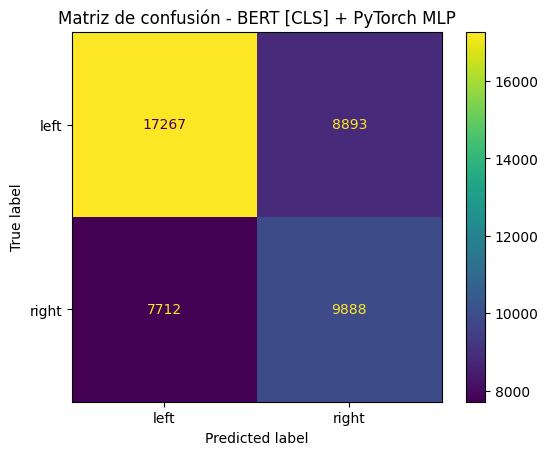

In [89]:
# Se calcula la matriz de confusión usando las clases originales.
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=label_encoder.classes_
)

# Se prepara la visualización de la matriz de confusión.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - BERT [CLS] + PyTorch MLP")
plt.show()

### Guardado de resultados del modelo PyTorch

Finalmente, se guardan las métricas del modelo PyTorch en la tabla acumulada de resultados.

Esto permite comparar el rendimiento de la red neuronal con los modelos anteriores basados en Scikit-learn.

In [90]:
# Se guardan las métricas del modelo en la tabla global de resultados.
bert_pytorch_mlp_results = {
    "model": "BERT [CLS] embeddings + PyTorch MLP",
    "test_accuracy": test_acc,
    "test_f1_macro": test_f1,
    "test_f1_weighted": f1_score(y_test_true, y_test_pred, average="weighted"),
    "best_cv_f1_macro": best_bert_pytorch_params["best_cv_f1_macro"],
    "best_params": best_bert_pytorch_params,
    "test_roc_auc": np.nan
}

# Se actualiza la tabla acumulada de resultados evitando duplicados por nombre de modelo.
model_results_df = update_model_results(bert_pytorch_mlp_results)

model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


### Conclusión del modelo BERT + PyTorch MLP

La red neuronal implementada en PyTorch se ha entrenado sobre los embeddings BERT `[CLS]` generados previamente.

El proceso incluye validación cruzada estratificada y agrupada por `label`, selección explícita de hiperparámetros mediante una parrilla de configuraciones, entrenamiento final sobre todo el conjunto de entrenamiento y evaluación independiente sobre `test_codalab`.

Este experimento responde directamente al requisito del enunciado de incluir una red neuronal implementada en PyTorch y corrige la observación metodológica del profesor, ya que los hiperparámetros no se seleccionan de forma arbitraria.

Además, los artefactos de este modelo se guardan con el prefijo `bert_pytorch_mlp`, lo que evita confusiones con los otros modelos PyTorch MLP entrenados sobre TF-IDF y Word2Vec.

## 3.5 TF-IDF + PyTorch MLP

En este experimento se entrena una red neuronal implementada en PyTorch utilizando una representación TF-IDF del texto.

Como TF-IDF genera matrices dispersas de alta dimensionalidad, se aplica `TruncatedSVD` para obtener una representación densa y manejable antes de entrenar la red neuronal. Tanto TF-IDF como SVD se ajustan únicamente sobre el fold de entrenamiento en cada iteración de validación cruzada, evitando fuga de información.

Este modelo cubre la combinación:

- Vectorización: TF-IDF.
- Modelo: red neuronal implementada en PyTorch.

Para evitar una selección arbitraria de hiperparámetros, se utiliza una parrilla explícita de configuraciones y se selecciona el mejor modelo mediante validación cruzada estratificada y agrupada por `label`, usando `F1-macro` como métrica principal.

### Configuración de TF-IDF para la red neuronal

Se utiliza una configuración TF-IDF coherente con el modelo `TF-IDF + Logistic Regression` evaluado anteriormente. De esta forma, la comparación entre Scikit-learn y PyTorch se centra principalmente en la arquitectura del modelo, manteniendo una representación textual comparable.

La reducción dimensional mediante `TruncatedSVD` sí se incluye en la búsqueda de hiperparámetros, ya que controla el tamaño de entrada de la red neuronal.

In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Se define la configuración base de TF-IDF para el modelo PyTorch.
# Esta configuración se mantiene fija para que la búsqueda de hiperparámetros
# se centre en la reducción dimensional y en la arquitectura de la red neuronal.
TFIDF_MLP_PARAMS = {
    "lowercase": False,
    "sublinear_tf": True,
    "ngram_range": (1, 2),
    "min_df": 5,
    "max_df": 0.90,
    "max_features": 30000
}

TFIDF_MLP_PARAMS

{'lowercase': False,
 'sublinear_tf': True,
 'ngram_range': (1, 2),
 'min_df': 5,
 'max_df': 0.9,
 'max_features': 30000}

### Función de entrenamiento para un fold

Esta función entrena una configuración concreta del modelo `TF-IDF + PyTorch MLP` en un fold de validación cruzada.

Dentro de cada fold se realiza el siguiente proceso:

1. Ajustar TF-IDF solo con los textos del fold de entrenamiento.
2. Transformar los textos de validación con el TF-IDF aprendido.
3. Ajustar `TruncatedSVD` solo sobre el fold de entrenamiento.
4. Escalar los vectores densos con `StandardScaler`, ajustado también solo en entrenamiento.
5. Entrenar la red neuronal PyTorch.
6. Seleccionar la mejor época mediante `F1-macro` en validación.

Esto evita fuga de datos y mantiene una validación metodológicamente correcta.

In [92]:
# Se entrena una configuración TF-IDF + SVD + MLP evitando fuga de información dentro de cada fold.
def train_tfidf_mlp_configuration(
    X_text,
    y,
    train_idx,
    val_idx,
    tfidf_params,
    n_components=256,
    hidden_layers=(256,),
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=256,
    max_epochs=10,
    patience=2,
    random_state=42
):
    """
    Se entrena una configuración concreta del modelo TF-IDF + SVD + PyTorch MLP
    sobre un fold de validación cruzada.

    TF-IDF, SVD y StandardScaler se ajustan únicamente sobre el fold de entrenamiento
    para evitar fuga de información hacia el fold de validación.
    """
    # Se fijan semillas para mejorar la reproducibilidad.
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Se separan textos y etiquetas según los índices del fold.
    X_train_fold_text = X_text.iloc[train_idx]
    X_val_fold_text = X_text.iloc[val_idx]

    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]

    # Se ajusta TF-IDF únicamente con los textos del fold de entrenamiento.
    tfidf = TfidfVectorizer(**tfidf_params)
    X_train_tfidf = tfidf.fit_transform(X_train_fold_text)
    X_val_tfidf = tfidf.transform(X_val_fold_text)

    # Se ajusta SVD únicamente sobre la matriz TF-IDF del fold de entrenamiento.
    svd = TruncatedSVD(
        n_components=n_components,
        random_state=random_state
    )
    X_train_dense = svd.fit_transform(X_train_tfidf)
    X_val_dense = svd.transform(X_val_tfidf)

    # Se ajusta el escalador únicamente sobre el fold de entrenamiento.
    scaler = StandardScaler()
    X_train_dense = scaler.fit_transform(X_train_dense).astype(np.float32)
    X_val_dense = scaler.transform(X_val_dense).astype(np.float32)

    # Se construyen los datasets de PyTorch.
    train_dataset = EmbeddingDataset(X_train_dense, y_train_fold)
    val_dataset = EmbeddingDataset(X_val_dense, y_val_fold)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Se inicializa el modelo con la configuración candidata.
    model = MLPClassifier(
        input_dim=n_components,
        hidden_layers=hidden_layers,
        dropout=dropout,
        num_classes=len(np.unique(y))
    ).to(device)

    # Se calculan pesos de clase usando solo el fold de entrenamiento.
    class_weights = compute_class_weights(
        y_train_fold,
        n_classes=len(np.unique(y)),
        device=device
    )

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_f1 = -np.inf
    best_epoch = 0
    best_state_dict = None
    epochs_without_improvement = 0

    history = []

    # Se entrena durante varias épocas y se aplica early stopping
    # usando el F1-macro del fold de validación.
    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate_pytorch_model(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state_dict = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return best_val_f1, best_epoch, best_state_dict, pd.DataFrame(history)

### Parrilla de hiperparámetros

La parrilla se mantiene reducida para controlar el coste computacional, pero incluye parámetros relevantes:

- `n_components`: dimensión de la representación TF-IDF reducida mediante SVD.
- `hidden_layers`: tamaño de la capa oculta de la red.
- `dropout`: regularización de la red neuronal.
- `lr`: learning rate del optimizador.
- `weight_decay`: regularización L2 usada por AdamW.

La selección se hará con validación cruzada, evitando elegir estos valores de forma arbitraria.

In [93]:
# Se define la parrilla de hiperparámetros.
# Esto evita seleccionar valores de forma arbitraria.
param_grid_tfidf_mlp = {
    "n_components": [128, 256],
    "hidden_layers": [(256,)],
    "dropout": [0.3, 0.5],
    "lr": [1e-3, 3e-4],
    "weight_decay": [1e-4],
    "batch_size": [256],
}

tfidf_mlp_param_grid = list(ParameterGrid(param_grid_tfidf_mlp))

print("Número de configuraciones TF-IDF + PyTorch MLP:", len(tfidf_mlp_param_grid))
print(
    "Número total de entrenamientos con validación cruzada de 5 folds:",
    len(tfidf_mlp_param_grid) * cv.get_n_splits(X_train_text, y_train, groups_train)
)

Número de configuraciones TF-IDF + PyTorch MLP: 8
Número total de entrenamientos con validación cruzada de 5 folds: 40


### Validación cruzada de TF-IDF + PyTorch MLP

Se evalúan las configuraciones mediante `StratifiedGroupKFold`.

Esto permite:

- mantener proporciones similares de clases en cada fold;
- evitar que tweets del mismo cluster aparezcan simultáneamente en entrenamiento y validación;
- seleccionar hiperparámetros usando `F1-macro`.

Los resultados se guardan en disco para evitar repetir el entrenamiento en futuras ejecuciones.

In [94]:
TFIDF_MLP_RESULTS_DIR = Path("models") / "tfidf_pytorch_mlp"
TFIDF_MLP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

tfidf_mlp_cv_results_path = (
    TFIDF_MLP_RESULTS_DIR / "tfidf_mlp_cv_results.csv"
)

tfidf_mlp_best_params_path = (
    TFIDF_MLP_RESULTS_DIR / "tfidf_mlp_best_params.json"
)

# Se activa únicamente si se desea repetir la validación cruzada completa.
FORCE_RETRAIN_TFIDF_MLP_CV = False

# Se comprueba si existen resultados previos guardados en disco.
tfidf_mlp_cv_is_cached = (
    tfidf_mlp_cv_results_path.exists()
    and tfidf_mlp_best_params_path.exists()
)

# Se decide si se debe ejecutar la validación cruzada.
RUN_TFIDF_MLP_CV = (
    FORCE_RETRAIN_TFIDF_MLP_CV
    or not tfidf_mlp_cv_is_cached
)

print("Resultados de CV TF-IDF + PyTorch MLP en caché:", tfidf_mlp_cv_is_cached)
print("Forzar reentrenamiento de CV:", FORCE_RETRAIN_TFIDF_MLP_CV)
print("Ejecutar CV TF-IDF + PyTorch MLP:", RUN_TFIDF_MLP_CV)

# Si la caché es válida, se cargan los resultados guardados.
if tfidf_mlp_cv_is_cached and not RUN_TFIDF_MLP_CV:
    tfidf_mlp_cv_results_df = pd.read_csv(tfidf_mlp_cv_results_path)

    with open(tfidf_mlp_best_params_path, "r", encoding="utf-8") as f:
        best_tfidf_mlp_params = json.load(f)

    print("Resultados de validación cruzada TF-IDF + PyTorch MLP cargados desde caché.")
    print("Mejores hiperparámetros:")
    print(best_tfidf_mlp_params)

else:
    # Se inicializa una lista para almacenar los resultados de cada configuración y fold.
    tfidf_mlp_cv_rows = []

    total_iterations = len(tfidf_mlp_param_grid) * cv.get_n_splits(
        X_train_text,
        y_train,
        groups_train
    )

    progress_bar = tqdm(
        total=total_iterations,
        desc="CV TF-IDF + PyTorch MLP",
        unit="fold"
    )

    # Se itera sobre cada configuración candidata de hiperparámetros.
    for config_id, params in enumerate(tfidf_mlp_param_grid, start=1):
        fold_scores = []

        # Se evalúa la configuración actual en cada fold de la validación cruzada.
        for fold, (train_idx, val_idx) in enumerate(
            cv.split(X_train_text, y_train, groups_train),
            start=1
        ):
            val_f1, best_epoch, _, history_df = train_tfidf_mlp_configuration(
                X_text=X_train_text,
                y=y_train_enc,
                train_idx=train_idx,
                val_idx=val_idx,
                tfidf_params=TFIDF_MLP_PARAMS,
                n_components=params["n_components"],
                hidden_layers=params["hidden_layers"],
                dropout=params["dropout"],
                lr=params["lr"],
                weight_decay=params["weight_decay"],
                batch_size=params["batch_size"],
                max_epochs=10,
                patience=2,
                random_state=RANDOM_STATE + fold
            )

            fold_scores.append(val_f1)

            tfidf_mlp_cv_rows.append({
                "config_id": config_id,
                "fold": fold,
                "val_f1_macro": val_f1,
                "best_epoch": best_epoch,
                "n_components": params["n_components"],
                "hidden_layers": str(params["hidden_layers"]),
                "dropout": params["dropout"],
                "lr": params["lr"],
                "weight_decay": params["weight_decay"],
                "batch_size": params["batch_size"]
            })

            progress_bar.update(1)

        print(
            f"Configuración {config_id}/{len(tfidf_mlp_param_grid)} "
            f"- F1-macro medio: {np.mean(fold_scores):.4f}"
        )

    progress_bar.close()

    # Se convierte la lista de resultados en un dataframe.
    tfidf_mlp_cv_results_df = pd.DataFrame(tfidf_mlp_cv_rows)

    # Se guardan los resultados de validación cruzada para evitar repetir entrenamientos.
    tfidf_mlp_cv_results_df.to_csv(
        tfidf_mlp_cv_results_path,
        index=False
    )

    # Se resume el rendimiento medio de cada configuración.
    tfidf_mlp_summary = (
        tfidf_mlp_cv_results_df
        .groupby([
            "config_id",
            "n_components",
            "hidden_layers",
            "dropout",
            "lr",
            "weight_decay",
            "batch_size"
        ])
        .agg(
            mean_val_f1_macro=("val_f1_macro", "mean"),
            std_val_f1_macro=("val_f1_macro", "std"),
            mean_best_epoch=("best_epoch", "mean")
        )
        .reset_index()
        .sort_values("mean_val_f1_macro", ascending=False)
    )

    best_row = tfidf_mlp_summary.iloc[0]

    best_tfidf_mlp_params = {
        "n_components": int(best_row["n_components"]),
        "hidden_layers": best_row["hidden_layers"],
        "dropout": float(best_row["dropout"]),
        "lr": float(best_row["lr"]),
        "weight_decay": float(best_row["weight_decay"]),
        "batch_size": int(best_row["batch_size"]),
        "mean_best_epoch": float(best_row["mean_best_epoch"]),
        "best_cv_f1_macro": float(best_row["mean_val_f1_macro"])
    }

    # Se guarda la mejor configuración en JSON para documentar la configuración usada.
    with open(tfidf_mlp_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_tfidf_mlp_params, f, indent=4)

    print("Mejores hiperparámetros del modelo TF-IDF + PyTorch MLP:")
    print(best_tfidf_mlp_params)

# Se muestran las primeras filas de los resultados de validación cruzada.
tfidf_mlp_cv_results_df.head()

Resultados de CV TF-IDF + PyTorch MLP en caché: True
Forzar reentrenamiento de CV: False
Ejecutar CV TF-IDF + PyTorch MLP: False
Resultados de validación cruzada TF-IDF + PyTorch MLP cargados desde caché.
Mejores hiperparámetros:
{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}


,config_id,fold,val_f1_macro,best_epoch,n_components,hidden_layers,dropout,lr,weight_decay,batch_size
0,1,1,0.590753,3,128,"(256,)",0.3,0.001,0.0001,256
1,1,2,0.598960,10,128,"(256,)",0.3,0.001,0.0001,256
2,1,3,0.599761,8,128,"(256,)",0.3,0.001,0.0001,256
3,1,4,0.589142,5,128,"(256,)",0.3,0.001,0.0001,256
4,1,5,0.586450,4,128,"(256,)",0.3,0.001,0.0001,256


### Resumen de validación cruzada

La siguiente tabla resume el rendimiento medio de cada configuración evaluada. La configuración final se selecciona usando `F1-macro` medio en validación cruzada.

La desviación estándar permite analizar la estabilidad del modelo entre folds.

In [95]:
# Se agrupan los resultados por configuración de hiperparámetros.
# Para cada configuración se calcula:
# - el F1-macro medio en validación;
# - la desviación estándar del F1-macro entre folds;
# - la media de la mejor época alcanzada durante el entrenamiento.
tfidf_mlp_summary = (
    tfidf_mlp_cv_results_df
    .groupby([
        "config_id",
        "n_components",
        "hidden_layers",
        "dropout",
        "lr",
        "weight_decay",
        "batch_size"
    ])
    .agg(
        mean_val_f1_macro=("val_f1_macro", "mean"),
        std_val_f1_macro=("val_f1_macro", "std"),
        mean_best_epoch=("best_epoch", "mean")
    )
    .reset_index()
    .sort_values("mean_val_f1_macro", ascending=False)
)

# Se muestra el resumen ordenado de mejor a peor configuración.
tfidf_mlp_summary

,config_id,n_components,hidden_layers,dropout,lr,weight_decay,batch_size,mean_val_f1_macro,std_val_f1_macro,mean_best_epoch
5,6,256,"(256,)",0.5,0.0010,0.0001,256,0.611518,0.004172,8.6
3,4,256,"(256,)",0.3,0.0003,0.0001,256,0.610856,0.005012,8.2
7,8,256,"(256,)",0.5,0.0003,0.0001,256,0.610257,0.006136,8.8
1,2,256,"(256,)",0.3,0.0010,0.0001,256,0.609167,0.005425,5.6
2,3,128,"(256,)",0.3,0.0003,0.0001,256,0.593688,0.007152,7.8
0,1,128,"(256,)",0.3,0.0010,0.0001,256,0.593013,0.006002,6.0
4,5,128,"(256,)",0.5,0.0010,0.0001,256,0.591865,0.004257,5.4
6,7,128,"(256,)",0.5,0.0003,0.0001,256,0.590969,0.005023,8.2


La tabla resume el rendimiento de cada configuración del modelo TF-IDF + PyTorch MLP evaluada mediante validación cruzada. La columna `mean_val_f1_macro` se utiliza como criterio principal de selección, mientras que `std_val_f1_macro` permite valorar la estabilidad del rendimiento entre folds.

La columna `mean_best_epoch` indica en qué época, de media, se obtuvo el mejor rendimiento durante la validación. Este valor se utilizará posteriormente para definir el número de épocas del entrenamiento final.

### Preparación del modelo final

Una vez seleccionada la mejor configuración, se prepara el modelo final.

La variable `hidden_layers` puede haberse guardado como texto en el CSV, por lo que se convierte de nuevo a una tupla de Python. El número de épocas se deriva de la media de las mejores épocas observadas durante la validación cruzada.

In [96]:
# Se recupera la mejor arquitectura de capas ocultas para el modelo TF-IDF + PyTorch MLP.
best_tfidf_mlp_hidden_layers = parse_hidden_layers(
    best_tfidf_mlp_params["hidden_layers"]
)

# Se define el número de épocas del modelo final a partir de la media de las mejores épocas
# obtenidas durante la validación cruzada.
best_tfidf_mlp_epochs = max(
    1,
    int(round(best_tfidf_mlp_params["mean_best_epoch"]))
)

print("Mejores capas ocultas para TF-IDF + PyTorch MLP:", best_tfidf_mlp_hidden_layers)
print("Épocas para entrenar el modelo final TF-IDF + PyTorch MLP:", best_tfidf_mlp_epochs)

Mejores capas ocultas para TF-IDF + PyTorch MLP: (256,)
Épocas para entrenar el modelo final TF-IDF + PyTorch MLP: 9


### Entrenamiento final con todo `train_public`

Después de seleccionar los hiperparámetros mediante validación cruzada, se entrena un modelo final usando todo el conjunto de entrenamiento.

En este entrenamiento final se ajustan TF-IDF, SVD y StandardScaler sobre todo `train_public`, y estos objetos se guardan para aplicar exactamente la misma transformación sobre el conjunto de test.

In [97]:
# Se entrena el modelo final TF-IDF + SVD + PyTorch MLP con todo el conjunto de entrenamiento.
def train_final_tfidf_mlp_model(
    X_text,
    y,
    tfidf_params,
    n_components,
    hidden_layers,
    dropout,
    lr,
    weight_decay,
    batch_size,
    n_epochs,
    random_state=42
):
    """
    Se entrena el modelo final TF-IDF + SVD + PyTorch MLP sobre todo el conjunto
    de entrenamiento.

    TF-IDF, SVD y StandardScaler se ajustan sobre todo `train_public` y después
    se reutilizan para transformar el conjunto de test final.
    """
    # Se fijan semillas para mejorar la reproducibilidad del entrenamiento.
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Se ajusta TF-IDF sobre todo el conjunto de entrenamiento.
    tfidf = TfidfVectorizer(**tfidf_params)
    X_tfidf = tfidf.fit_transform(X_text)

    # Se ajusta SVD sobre la matriz TF-IDF de entrenamiento.
    svd = TruncatedSVD(
        n_components=n_components,
        random_state=random_state
    )
    X_dense = svd.fit_transform(X_tfidf)

    # Se ajusta el escalador sobre la representación densa de entrenamiento.
    scaler = StandardScaler()
    X_dense = scaler.fit_transform(X_dense).astype(np.float32)

    # Se construye el Dataset de PyTorch.
    train_dataset = EmbeddingDataset(X_dense, y)

    # Se crea el DataLoader de entrenamiento.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Se inicializa el modelo final con la mejor arquitectura seleccionada.
    model = MLPClassifier(
        input_dim=n_components,
        hidden_layers=hidden_layers,
        dropout=dropout,
        num_classes=len(np.unique(y))
    ).to(device)

    # Se calculan pesos de clase usando todo el conjunto de entrenamiento.
    class_weights = compute_class_weights(
        y,
        n_classes=len(np.unique(y)),
        device=device
    )

    # Se define la función de pérdida ponderada por clase.
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Se define el optimizador con los hiperparámetros seleccionados.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    training_history = []

    # Se entrena el modelo final durante el número de épocas seleccionado
    # a partir de la validación cruzada.
    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        training_history.append({
            "epoch": epoch,
            "train_loss": train_loss
        })

        print(f"Época {epoch}/{n_epochs} - pérdida de entrenamiento: {train_loss:.4f}")

    return model, tfidf, svd, scaler, pd.DataFrame(training_history)

### Carga o entrenamiento del modelo final

Para evitar reentrenamientos innecesarios, se comprueba si el modelo final ya existe en disco. Si existe y no se fuerza el reentrenamiento, se carga directamente.

In [98]:
FORCE_RETRAIN_FINAL_TFIDF_MLP = False

tfidf_mlp_model_path = (
    TFIDF_MLP_RESULTS_DIR / "tfidf_mlp_best_model.pt"
)

tfidf_mlp_preprocessor_path = (
    TFIDF_MLP_RESULTS_DIR / "tfidf_mlp_preprocessors.joblib"
)

tfidf_mlp_history_path = (
    TFIDF_MLP_RESULTS_DIR / "tfidf_mlp_final_training_history.csv"
)

# Se comprueba si ya existen artefactos guardados para evitar repetir entrenamientos costosos.
tfidf_mlp_final_model_is_cached = (
    tfidf_mlp_model_path.exists()
    and tfidf_mlp_preprocessor_path.exists()
)

# Se decide si se debe entrenar de nuevo el modelo final.
# Se reentrena si se fuerza explícitamente o si no existe caché previa.
RUN_FINAL_TFIDF_MLP = (
    FORCE_RETRAIN_FINAL_TFIDF_MLP
    or not tfidf_mlp_final_model_is_cached
)

print("Modelo final TF-IDF + PyTorch MLP en caché:", tfidf_mlp_final_model_is_cached)
print("Forzar reentrenamiento del modelo final:", FORCE_RETRAIN_FINAL_TFIDF_MLP)
print("Ejecutar entrenamiento final TF-IDF + PyTorch MLP:", RUN_FINAL_TFIDF_MLP)

# Si la caché es válida, se cargan el modelo y los preprocesadores guardados.
if tfidf_mlp_final_model_is_cached and not RUN_FINAL_TFIDF_MLP:
    checkpoint = torch.load(
        tfidf_mlp_model_path,
        map_location=device
    )

    final_tfidf_mlp = MLPClassifier(
        input_dim=checkpoint["input_dim"],
        hidden_layers=tuple(checkpoint["hidden_layers"]),
        dropout=best_tfidf_mlp_params["dropout"],
        num_classes=len(checkpoint["label_classes"])
    ).to(device)

    final_tfidf_mlp.load_state_dict(checkpoint["model_state_dict"])

    tfidf_mlp_preprocessors = joblib.load(tfidf_mlp_preprocessor_path)

    final_tfidf_mlp_tfidf = tfidf_mlp_preprocessors["tfidf"]
    final_tfidf_mlp_svd = tfidf_mlp_preprocessors["svd"]
    final_tfidf_mlp_scaler = tfidf_mlp_preprocessors["scaler"]

    if tfidf_mlp_history_path.exists():
        final_tfidf_mlp_history = pd.read_csv(tfidf_mlp_history_path)
    else:
        final_tfidf_mlp_history = None

    print("Modelo final TF-IDF + PyTorch MLP cargado desde caché.")

else:
    # Si no existe caché válida, se entrena el modelo final con todo train_public.
    (
        final_tfidf_mlp,
        final_tfidf_mlp_tfidf,
        final_tfidf_mlp_svd,
        final_tfidf_mlp_scaler,
        final_tfidf_mlp_history
    ) = train_final_tfidf_mlp_model(
        X_text=X_train_text,
        y=y_train_enc,
        tfidf_params=TFIDF_MLP_PARAMS,
        n_components=best_tfidf_mlp_params["n_components"],
        hidden_layers=best_tfidf_mlp_hidden_layers,
        dropout=best_tfidf_mlp_params["dropout"],
        lr=best_tfidf_mlp_params["lr"],
        weight_decay=best_tfidf_mlp_params["weight_decay"],
        batch_size=best_tfidf_mlp_params["batch_size"],
        n_epochs=best_tfidf_mlp_epochs,
        random_state=RANDOM_STATE
    )

    # Se guardan los pesos del modelo PyTorch final junto con la configuración necesaria
    # para reconstruir la arquitectura posteriormente.
    torch.save(
        {
            "model_state_dict": final_tfidf_mlp.state_dict(),
            "best_params": best_tfidf_mlp_params,
            "label_classes": label_encoder.classes_.tolist(),
            "input_dim": best_tfidf_mlp_params["n_components"],
            "hidden_layers": best_tfidf_mlp_hidden_layers
        },
        tfidf_mlp_model_path
    )

    # Se guardan los preprocesadores ajustados sobre todo el conjunto de entrenamiento.
    joblib.dump(
        {
            "tfidf": final_tfidf_mlp_tfidf,
            "svd": final_tfidf_mlp_svd,
            "scaler": final_tfidf_mlp_scaler
        },
        tfidf_mlp_preprocessor_path
    )

    # Se guarda el historial de pérdidas del entrenamiento final.
    final_tfidf_mlp_history.to_csv(
        tfidf_mlp_history_path,
        index=False
    )

    print("Modelo final TF-IDF + PyTorch MLP entrenado y guardado.")

Modelo final TF-IDF + PyTorch MLP en caché: True
Forzar reentrenamiento del modelo final: False
Ejecutar entrenamiento final TF-IDF + PyTorch MLP: False
Modelo final TF-IDF + PyTorch MLP cargado desde caché.


### Evaluación en test final

El conjunto de test se transforma utilizando el TF-IDF, SVD y scaler aprendidos exclusivamente con `train_public`.

Después se evalúa el modelo final en `test_codalab`, que no se ha usado durante la selección de hiperparámetros.

In [99]:
# Se transforma el conjunto de test con los preprocesadores ajustados sobre train_public.
X_test_tfidf = final_tfidf_mlp_tfidf.transform(X_test_text)
X_test_tfidf_dense = final_tfidf_mlp_svd.transform(X_test_tfidf)
X_test_tfidf_dense = final_tfidf_mlp_scaler.transform(X_test_tfidf_dense).astype(np.float32)

# Se construye el Dataset de test.
test_dataset = EmbeddingDataset(X_test_tfidf_dense, y_test_enc)

# Se crea el DataLoader de test sin barajar los ejemplos.
test_loader = DataLoader(
    test_dataset,
    batch_size=best_tfidf_mlp_params["batch_size"],
    shuffle=False
)

# En test se usa la pérdida sin pesos de clase, ya que solo se evalúa el rendimiento final.
criterion = nn.CrossEntropyLoss()

# Se evalúa el modelo final sobre test_codalab.
test_loss, test_acc, test_f1, y_test_pred_enc, y_test_true_enc = evaluate_pytorch_model(
    final_tfidf_mlp,
    test_loader,
    criterion,
    device
)

# Se convierten las predicciones y etiquetas reales a los nombres originales de clase.
y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)
y_test_true = label_encoder.inverse_transform(y_test_true_enc)

print("Resultados en test - TF-IDF + PyTorch MLP")
print("=" * 80)
print("Pérdida en test:", round(test_loss, 4))
print("Accuracy en test:", round(test_acc, 4))
print("F1-macro en test:", round(test_f1, 4))

print("\nInforme de clasificación:")
print(classification_report(y_test_true, y_test_pred))

Resultados en test - TF-IDF + PyTorch MLP
Pérdida en test: 0.6575
Accuracy en test: 0.604
F1-macro en test: 0.5954

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.68      0.63      0.65     26160
       right       0.51      0.57      0.54     17600

    accuracy                           0.60     43760
   macro avg       0.60      0.60      0.60     43760
weighted avg       0.61      0.60      0.61     43760



El modelo `TF-IDF + PyTorch MLP` obtiene un resultado más bajo que `TF-IDF + Logistic Regression`.

La accuracy en test es `0.6040`, por lo que el modelo acierta alrededor del 60% de los tweets. El `F1-macro` es `0.5954`, que queda por debajo del resultado obtenido con regresión logística usando la misma representación TF-IDF.

Por clases, se observa que el modelo funciona mejor para `left`, con un `f1-score` de `0.65`, que para `right`, donde obtiene `0.54`. Aun así, el recall de `right` es `0.57`, por lo que el modelo sí identifica parte de esta clase, aunque con más errores que en `left`.

Este resultado indica que añadir una red neuronal MLP no mejora automáticamente el rendimiento. En este caso, la regresión logística parece aprovechar mejor la representación TF-IDF que la MLP.

Una posible explicación es que TF-IDF genera una representación muy dispersa y de alta dimensión. Para poder usarla con la MLP se reduce previamente su dimensionalidad, y en ese proceso puede perderse parte de la información útil que sí utiliza la regresión logística directamente.

### Matriz de confusión

La matriz de confusión permite analizar si el modelo comete más errores en una clase ideológica que en la otra.

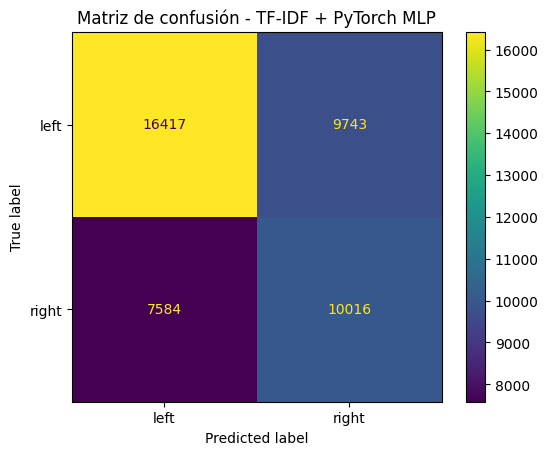

In [100]:
# Se calcula la matriz de confusión usando las clases originales.
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=label_encoder.classes_
)

# Se prepara la visualización de la matriz de confusión.
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - TF-IDF + PyTorch MLP")
plt.show()

### Guardado de resultados

Se añaden las métricas del modelo `TF-IDF + PyTorch MLP` a la tabla global de resultados, para compararlo después con los otros seis modelos.

In [101]:
# Se guardan las métricas del modelo en la tabla global de resultados.
tfidf_mlp_results = {
    "model": "TF-IDF + PyTorch MLP",
    "test_accuracy": test_acc,
    "test_f1_macro": test_f1,
    "test_f1_weighted": f1_score(y_test_true, y_test_pred, average="weighted"),
    "best_cv_f1_macro": best_tfidf_mlp_params["best_cv_f1_macro"],
    "best_params": best_tfidf_mlp_params,
    "test_roc_auc": np.nan
}

# Se actualiza la tabla acumulada de resultados evitando duplicados por nombre de modelo.
model_results_df = update_model_results(tfidf_mlp_results)

model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


### Conclusión del modelo TF-IDF + PyTorch MLP

La red neuronal implementada en PyTorch se ha entrenado utilizando una representación TF-IDF del texto, reducida posteriormente mediante `TruncatedSVD` para obtener una matriz densa adecuada para el entrenamiento neuronal.

El procedimiento incluye validación cruzada estratificada y agrupada por `label`, selección explícita de hiperparámetros mediante una parrilla de configuraciones, entrenamiento final sobre todo el conjunto de entrenamiento y evaluación independiente sobre `test_codalab`.

Además, TF-IDF, SVD y el escalador se ajustan únicamente sobre el fold de entrenamiento durante la validación cruzada, evitando fuga de información hacia los folds de validación. En el entrenamiento final, estos preprocesadores se ajustan sobre todo `train_public` y después se reutilizan para transformar el conjunto de test.

Este experimento permite comparar una representación léxica clásica, como TF-IDF, con un clasificador neuronal no lineal. También cubre uno de los modelos PyTorch requeridos en el proyecto y mantiene una metodología coherente con el resto de experimentos.

## 3.6 Word2Vec average + PyTorch MLP

En este experimento se entrena una red neuronal implementada en PyTorch utilizando como entrada representaciones Word2Vec promedio.

Cada tweet se representa como el promedio de los embeddings de las palabras que contiene. Para evitar fuga de datos, el modelo Word2Vec se entrena únicamente con los textos del fold de entrenamiento y después se aplica al fold de validación.

Este modelo cubre la combinación obligatoria:

- Vectorización: Word2Vec promedio
- Modelo: red neuronal PyTorch

Para evitar una selección arbitraria de hiperparámetros, se define una parrilla explícita de configuraciones y se evalúa mediante validación cruzada estratificada y agrupada por `label`, usando `F1-macro` como métrica principal.

### Comprobación de dependencias

Este bloque reutiliza componentes definidos previamente:

- `MeanWord2VecVectorizer`, para transformar textos en embeddings promedio.
- `EmbeddingDataset`, para construir datasets de PyTorch.
- `MLPClassifier`, para definir la red neuronal.
- `train_one_epoch` y `evaluate_pytorch_model`, para entrenar y evaluar.
- `compute_class_weights`, para ponderar clases dentro de cada fold.

Antes de entrenar, se comprueba que estas funciones y clases existen en el entorno.

In [102]:
required_objects = [
    "MeanWord2VecVectorizer",
    "EmbeddingDataset",
    "MLPClassifier",
    "train_one_epoch",
    "evaluate_pytorch_model",
    "compute_class_weights",
    "parse_hidden_layers",
    "update_model_results"
]

missing_objects = [
    obj for obj in required_objects
    if obj not in globals()
]

# Comprobación defensiva: si esta condición falla, el notebook debe detenerse
# antes de producir resultados inválidos.
assert not missing_objects, f"Objetos requeridos no encontrados: {missing_objects}"

print("Todos los objetos requeridos están disponibles.")

Todos los objetos requeridos están disponibles.


### Función de entrenamiento para un fold

Esta función entrena una configuración concreta de `Word2Vec + PyTorch MLP` en un fold de validación cruzada.

Dentro de cada fold:

1. Word2Vec se entrena únicamente con los textos del fold de entrenamiento.
2. Los tweets se transforman en vectores promedio.
3. `StandardScaler` se ajusta solo sobre el fold de entrenamiento.
4. La red neuronal se entrena en PyTorch.
5. La mejor época se selecciona mediante `F1-macro` sobre el fold de validación.

Este procedimiento evita fuga de datos y mantiene una validación coherente con los modelos anteriores.

In [103]:
# Se entrena una configuración Word2Vec + PyTorch MLP ajustando Word2Vec
# únicamente con los textos del fold de entrenamiento.
def train_w2v_mlp_configuration(
    X_text,
    y,
    train_idx,
    val_idx,
    vector_size=100,
    window=5,
    min_count=5,
    sg=1,
    hidden_layers=(256,),
    dropout=0.3,
    lr=3e-4,
    weight_decay=1e-4,
    batch_size=256,
    max_epochs=10,
    patience=2,
    random_state=42
):
    """
    Se entrena una configuración concreta del modelo Word2Vec average + PyTorch MLP
    sobre un fold de validación cruzada.

    Word2Vec y StandardScaler se ajustan únicamente sobre el fold de entrenamiento
    para evitar fuga de información hacia el fold de validación.
    """
    # Se fijan semillas para mejorar la reproducibilidad.
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Se separan textos y etiquetas según los índices del fold.
    X_train_fold_text = X_text.iloc[train_idx]
    X_val_fold_text = X_text.iloc[val_idx]

    y_train_fold = y[train_idx]
    y_val_fold = y[val_idx]

    # Se ajusta Word2Vec únicamente con los textos del fold de entrenamiento.
    w2v_vectorizer = MeanWord2VecVectorizer(
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=4,
        seed=random_state
    )

    # Se transforman los textos en vectores Word2Vec promedio.
    X_train_w2v = w2v_vectorizer.fit_transform(X_train_fold_text).astype(np.float32)
    X_val_w2v = w2v_vectorizer.transform(X_val_fold_text).astype(np.float32)

    # Se ajusta el escalador únicamente sobre el fold de entrenamiento.
    scaler = StandardScaler()
    X_train_w2v = scaler.fit_transform(X_train_w2v).astype(np.float32)
    X_val_w2v = scaler.transform(X_val_w2v).astype(np.float32)

    # Se construyen los datasets de PyTorch.
    train_dataset = EmbeddingDataset(X_train_w2v, y_train_fold)
    val_dataset = EmbeddingDataset(X_val_w2v, y_val_fold)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Se inicializa el modelo con la configuración candidata.
    model = MLPClassifier(
        input_dim=vector_size,
        hidden_layers=hidden_layers,
        dropout=dropout,
        num_classes=len(np.unique(y))
    ).to(device)

    # Se calculan pesos de clase usando solo el fold de entrenamiento.
    class_weights = compute_class_weights(
        y_train_fold,
        n_classes=len(np.unique(y)),
        device=device
    )

    # Se define la función de pérdida ponderada por clase.
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Se define el optimizador AdamW.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_f1 = -np.inf
    best_epoch = 0
    best_state_dict = None
    epochs_without_improvement = 0

    history = []

    # Se entrena durante varias épocas y se aplica early stopping
    # usando el F1-macro del fold de validación.
    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate_pytorch_model(
            model,
            val_loader,
            criterion,
            device
        )

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1
        })

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state_dict = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }
            epochs_without_improvement = 0
        else:
            # Si no mejora el F1-macro de validación, se incrementa
            # el contador de épocas sin mejora.
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    return best_val_f1, best_epoch, best_state_dict, pd.DataFrame(history)

### Parrilla de hiperparámetros

La búsqueda se mantiene reducida para controlar el coste computacional, pero valida elementos relevantes de la representación y de la red neuronal:

- `vector_size`: dimensión de los embeddings Word2Vec.
- `sg`: arquitectura de Word2Vec, CBOW (`0`) o Skip-gram (`1`).
- `dropout`: regularización de la red neuronal.
- `lr`: learning rate del optimizador.
- `weight_decay`: regularización L2 mediante AdamW.

El objetivo es evitar seleccionar estos valores de forma arbitraria.

In [104]:
# Se define la parrilla de hiperparámetros.
# Esto evita seleccionar valores de forma arbitraria.
param_grid_w2v_mlp = {
    "vector_size": [100, 200],
    "window": [5],
    "min_count": [5],
    "sg": [0, 1],
    "hidden_layers": [(256,)],
    "dropout": [0.3, 0.5],
    "lr": [3e-4],
    "weight_decay": [1e-4],
    "batch_size": [256],
}

w2v_mlp_param_grid = list(ParameterGrid(param_grid_w2v_mlp))

print("Número de configuraciones Word2Vec + PyTorch MLP:", len(w2v_mlp_param_grid))
print(
    "Número total de entrenamientos con validación cruzada de 5 folds:",
    len(w2v_mlp_param_grid) * cv.get_n_splits(X_train_text, y_train, groups_train)
)

Número de configuraciones Word2Vec + PyTorch MLP: 8
Número total de entrenamientos con validación cruzada de 5 folds: 40


### Validación cruzada de Word2Vec + PyTorch MLP

Se evalúan las configuraciones mediante `StratifiedGroupKFold`.

Esto permite:

- mantener proporciones similares de clases en cada fold;
- evitar que tweets del mismo cluster aparezcan simultáneamente en entrenamiento y validación;
- seleccionar hiperparámetros usando `F1-macro`.

Los resultados se guardan en disco para evitar repetir el entrenamiento en futuras ejecuciones.

In [105]:
W2V_MLP_RESULTS_DIR = Path("models") / "w2v_pytorch_mlp"
W2V_MLP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

w2v_mlp_cv_results_path = (
    W2V_MLP_RESULTS_DIR / "w2v_mlp_cv_results.csv"
)

w2v_mlp_best_params_path = (
    W2V_MLP_RESULTS_DIR / "w2v_mlp_best_params.json"
)

# Se activa únicamente si se desea repetir la validación cruzada completa.
FORCE_RETRAIN_W2V_MLP_CV = False

# Se comprueba si existen resultados previos guardados en disco.
w2v_mlp_cv_is_cached = (
    w2v_mlp_cv_results_path.exists()
    and w2v_mlp_best_params_path.exists()
)

# Se decide si se debe ejecutar la validación cruzada.
RUN_W2V_MLP_CV = (
    FORCE_RETRAIN_W2V_MLP_CV
    or not w2v_mlp_cv_is_cached
)

print("Resultados de CV Word2Vec + PyTorch MLP en caché:", w2v_mlp_cv_is_cached)
print("Forzar reentrenamiento de CV:", FORCE_RETRAIN_W2V_MLP_CV)
print("Ejecutar CV Word2Vec + PyTorch MLP:", RUN_W2V_MLP_CV)

# Si la caché es válida, se cargan los resultados guardados.
if w2v_mlp_cv_is_cached and not RUN_W2V_MLP_CV:
    w2v_mlp_cv_results_df = pd.read_csv(w2v_mlp_cv_results_path)

    with open(w2v_mlp_best_params_path, "r", encoding="utf-8") as f:
        best_w2v_mlp_params = json.load(f)

    print("Resultados de validación cruzada Word2Vec + PyTorch MLP cargados desde caché.")
    print("Mejores hiperparámetros:")
    print(best_w2v_mlp_params)

else:
    # Se inicializa una lista para almacenar los resultados de cada configuración y fold.
    w2v_mlp_cv_rows = []

    total_iterations = len(w2v_mlp_param_grid) * cv.get_n_splits(
        X_train_text,
        y_train,
        groups_train
    )

    progress_bar = tqdm(
        total=total_iterations,
        desc="CV Word2Vec + PyTorch MLP",
        unit="fold"
    )

    # Se itera sobre cada configuración candidata de hiperparámetros.
    for config_id, params in enumerate(w2v_mlp_param_grid, start=1):
        fold_scores = []

        # Se evalúa la configuración actual en cada fold de la validación cruzada.
        for fold, (train_idx, val_idx) in enumerate(
            cv.split(X_train_text, y_train, groups_train),
            start=1
        ):
            val_f1, best_epoch, _, history_df = train_w2v_mlp_configuration(
                X_text=X_train_text,
                y=y_train_enc,
                train_idx=train_idx,
                val_idx=val_idx,
                vector_size=params["vector_size"],
                window=params["window"],
                min_count=params["min_count"],
                sg=params["sg"],
                hidden_layers=params["hidden_layers"],
                dropout=params["dropout"],
                lr=params["lr"],
                weight_decay=params["weight_decay"],
                batch_size=params["batch_size"],
                max_epochs=10,
                patience=2,
                random_state=RANDOM_STATE + fold
            )

            fold_scores.append(val_f1)

            w2v_mlp_cv_rows.append({
                "config_id": config_id,
                "fold": fold,
                "val_f1_macro": val_f1,
                "best_epoch": best_epoch,
                "vector_size": params["vector_size"],
                "window": params["window"],
                "min_count": params["min_count"],
                "sg": params["sg"],
                "hidden_layers": str(params["hidden_layers"]),
                "dropout": params["dropout"],
                "lr": params["lr"],
                "weight_decay": params["weight_decay"],
                "batch_size": params["batch_size"]
            })

            progress_bar.update(1)

        print(
            f"Configuración {config_id}/{len(w2v_mlp_param_grid)} "
            f"- F1-macro medio: {np.mean(fold_scores):.4f}"
        )

    progress_bar.close()

    # Se convierte la lista de resultados en un dataframe.
    w2v_mlp_cv_results_df = pd.DataFrame(w2v_mlp_cv_rows)

    # Se guardan los resultados de validación cruzada para evitar repetir entrenamientos.
    w2v_mlp_cv_results_df.to_csv(
        w2v_mlp_cv_results_path,
        index=False
    )

    # Se resume el rendimiento medio de cada configuración.
    w2v_mlp_summary = (
        w2v_mlp_cv_results_df
        .groupby([
            "config_id",
            "vector_size",
            "window",
            "min_count",
            "sg",
            "hidden_layers",
            "dropout",
            "lr",
            "weight_decay",
            "batch_size"
        ])
        .agg(
            mean_val_f1_macro=("val_f1_macro", "mean"),
            std_val_f1_macro=("val_f1_macro", "std"),
            mean_best_epoch=("best_epoch", "mean")
        )
        .reset_index()
        .sort_values("mean_val_f1_macro", ascending=False)
    )

    best_row = w2v_mlp_summary.iloc[0]

    best_w2v_mlp_params = {
        "vector_size": int(best_row["vector_size"]),
        "window": int(best_row["window"]),
        "min_count": int(best_row["min_count"]),
        "sg": int(best_row["sg"]),
        "hidden_layers": best_row["hidden_layers"],
        "dropout": float(best_row["dropout"]),
        "lr": float(best_row["lr"]),
        "weight_decay": float(best_row["weight_decay"]),
        "batch_size": int(best_row["batch_size"]),
        "mean_best_epoch": float(best_row["mean_best_epoch"]),
        "best_cv_f1_macro": float(best_row["mean_val_f1_macro"])
    }

    # Se guarda la mejor configuración en JSON para documentar la configuración usada.
    with open(w2v_mlp_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_w2v_mlp_params, f, indent=4)

    print("Mejores hiperparámetros del modelo Word2Vec + PyTorch MLP:")
    print(best_w2v_mlp_params)

# Se muestran las primeras filas de los resultados de validación cruzada.
w2v_mlp_cv_results_df.head()

Resultados de CV Word2Vec + PyTorch MLP en caché: True
Forzar reentrenamiento de CV: False
Ejecutar CV Word2Vec + PyTorch MLP: False
Resultados de validación cruzada Word2Vec + PyTorch MLP cargados desde caché.
Mejores hiperparámetros:
{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}


,config_id,fold,val_f1_macro,best_epoch,vector_size,window,min_count,sg,hidden_layers,dropout,lr,weight_decay,batch_size
0,1,1,0.588660,5,100,5,5,0,"(256,)",0.3,0.0003,0.0001,256
1,1,2,0.601226,5,100,5,5,0,"(256,)",0.3,0.0003,0.0001,256
2,1,3,0.601193,7,100,5,5,0,"(256,)",0.3,0.0003,0.0001,256
3,1,4,0.580948,2,100,5,5,0,"(256,)",0.3,0.0003,0.0001,256
4,1,5,0.592486,7,100,5,5,0,"(256,)",0.3,0.0003,0.0001,256


### Resumen de validación cruzada

La siguiente tabla resume el rendimiento medio de cada configuración evaluada. La configuración final se selecciona usando `F1-macro` medio en validación cruzada.

La desviación estándar permite analizar la estabilidad del modelo entre folds.

In [106]:
# Se agrupan los resultados por configuración de hiperparámetros.
# Para cada configuración se calcula:
# - el F1-macro medio en validación;
# - la desviación estándar del F1-macro entre folds;
# - la media de la mejor época alcanzada durante el entrenamiento.
w2v_mlp_summary = (
    w2v_mlp_cv_results_df
    .groupby([
        "config_id",
        "vector_size",
        "window",
        "min_count",
        "sg",
        "hidden_layers",
        "dropout",
        "lr",
        "weight_decay",
        "batch_size"
    ])
    .agg(
        mean_val_f1_macro=("val_f1_macro", "mean"),
        std_val_f1_macro=("val_f1_macro", "std"),
        mean_best_epoch=("best_epoch", "mean")
    )
    .reset_index()
    .sort_values("mean_val_f1_macro", ascending=False)
)

# Se muestra el resumen ordenado de mejor a peor configuración.
w2v_mlp_summary

,config_id,vector_size,window,min_count,sg,hidden_layers,dropout,lr,weight_decay,batch_size,mean_val_f1_macro,std_val_f1_macro,mean_best_epoch
3,4,200,5,5,1,"(256,)",0.3,0.0003,0.0001,256,0.630049,0.005033,6.8
7,8,200,5,5,1,"(256,)",0.5,0.0003,0.0001,256,0.626965,0.005626,6.4
2,3,100,5,5,1,"(256,)",0.3,0.0003,0.0001,256,0.621147,0.004057,7.6
6,7,100,5,5,1,"(256,)",0.5,0.0003,0.0001,256,0.618318,0.006973,9.2
1,2,200,5,5,0,"(256,)",0.3,0.0003,0.0001,256,0.597661,0.006403,5.4
5,6,200,5,5,0,"(256,)",0.5,0.0003,0.0001,256,0.597224,0.005432,6.2
0,1,100,5,5,0,"(256,)",0.3,0.0003,0.0001,256,0.592902,0.008647,5.2
4,5,100,5,5,0,"(256,)",0.5,0.0003,0.0001,256,0.591045,0.009143,5.4


La tabla resume el rendimiento de cada configuración del modelo Word2Vec average + PyTorch MLP evaluada mediante validación cruzada. La columna `mean_val_f1_macro` se utiliza como criterio principal de selección, mientras que `std_val_f1_macro` permite valorar la estabilidad del rendimiento entre folds.

La columna `mean_best_epoch` indica en qué época, de media, se obtuvo el mejor rendimiento durante la validación. Este valor se utilizará posteriormente para definir el número de épocas del entrenamiento final.

### Preparación del modelo final

Una vez seleccionada la mejor configuración, se prepara el entrenamiento final.

La variable `hidden_layers` puede haberse guardado como texto en el CSV, por lo que se convierte de nuevo a una tupla de Python. El número de épocas se deriva de la media de las mejores épocas observadas durante la validación cruzada.

In [107]:
# Se recupera la mejor arquitectura de capas ocultas para el modelo Word2Vec + PyTorch MLP.
best_w2v_mlp_hidden_layers = parse_hidden_layers(
    best_w2v_mlp_params["hidden_layers"]
)

# Se define el número de épocas del modelo final a partir de la media de las mejores épocas
# obtenidas durante la validación cruzada.
best_w2v_mlp_epochs = max(
    1,
    int(round(best_w2v_mlp_params["mean_best_epoch"]))
)

print("Mejores hiperparámetros del modelo Word2Vec + PyTorch MLP:")
print(best_w2v_mlp_params)
print("Mejores capas ocultas:", best_w2v_mlp_hidden_layers)
print("Épocas para entrenar el modelo final:", best_w2v_mlp_epochs)

Mejores hiperparámetros del modelo Word2Vec + PyTorch MLP:
{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}
Mejores capas ocultas: (256,)
Épocas para entrenar el modelo final: 7


### Entrenamiento final con todo `train_public`

Después de seleccionar los hiperparámetros mediante validación cruzada, se entrena un modelo final usando todo el conjunto de entrenamiento.

En este entrenamiento final se ajusta Word2Vec sobre todo `train_public`, se calculan los vectores promedio y se ajusta el `StandardScaler`. Estos objetos se guardan para aplicar exactamente la misma transformación sobre el conjunto de test.

In [108]:
# Se entrena el modelo final Word2Vec average + PyTorch MLP con todo el conjunto de entrenamiento.
def train_final_w2v_mlp_model(
    X_text,
    y,
    vector_size,
    window,
    min_count,
    sg,
    hidden_layers,
    dropout,
    lr,
    weight_decay,
    batch_size,
    n_epochs,
    random_state=42
):
    """
    Se entrena el modelo final Word2Vec average + PyTorch MLP sobre todo el conjunto
    de entrenamiento.

    Word2Vec y StandardScaler se ajustan sobre todo `train_public` y después
    se reutilizan para transformar el conjunto de test final.
    """
    # Se fijan semillas para mejorar la reproducibilidad del entrenamiento.
    torch.manual_seed(random_state)
    np.random.seed(random_state)

    # Se ajusta Word2Vec sobre todo el conjunto de entrenamiento.
    w2v_vectorizer = MeanWord2VecVectorizer(
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        sg=sg,
        workers=4,
        seed=random_state
    )

    # Se transforman los textos de entrenamiento en vectores promedio Word2Vec.
    X_w2v = w2v_vectorizer.fit_transform(X_text).astype(np.float32)

    # Se ajusta el escalador sobre la representación Word2Vec de entrenamiento.
    scaler = StandardScaler()
    X_w2v = scaler.fit_transform(X_w2v).astype(np.float32)

    # Se construye el Dataset de PyTorch.
    train_dataset = EmbeddingDataset(X_w2v, y)

    # Se crea el DataLoader de entrenamiento.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Se inicializa el modelo final con la mejor arquitectura seleccionada.
    model = MLPClassifier(
        input_dim=vector_size,
        hidden_layers=hidden_layers,
        dropout=dropout,
        num_classes=len(np.unique(y))
    ).to(device)

    # Se calculan pesos de clase usando todo el conjunto de entrenamiento.
    class_weights = compute_class_weights(
        y,
        n_classes=len(np.unique(y)),
        device=device
    )

    # Se define la función de pérdida ponderada por clase.
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    # Se define el optimizador con los hiperparámetros seleccionados.
    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    training_history = []

    # Se entrena el modelo final durante el número de épocas seleccionado
    # a partir de la validación cruzada.
    for epoch in range(1, n_epochs + 1):
        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        training_history.append({
            "epoch": epoch,
            "train_loss": train_loss
        })

        print(f"Época {epoch}/{n_epochs} - pérdida de entrenamiento: {train_loss:.4f}")

    return model, w2v_vectorizer, scaler, pd.DataFrame(training_history)

### Carga o entrenamiento del modelo final

Para evitar reentrenamientos innecesarios, se comprueba si el modelo final ya existe en disco. Si existe y no se fuerza el reentrenamiento, se carga directamente.

In [109]:
FORCE_RETRAIN_FINAL_W2V_MLP = False

w2v_mlp_model_path = (
    W2V_MLP_RESULTS_DIR / "w2v_mlp_best_model.pt"
)

w2v_mlp_preprocessor_path = (
    W2V_MLP_RESULTS_DIR / "w2v_mlp_preprocessors.joblib"
)

w2v_mlp_history_path = (
    W2V_MLP_RESULTS_DIR / "w2v_mlp_final_training_history.csv"
)

# Se comprueba si ya existen artefactos guardados para evitar repetir entrenamientos costosos.
w2v_mlp_final_model_is_cached = (
    w2v_mlp_model_path.exists()
    and w2v_mlp_preprocessor_path.exists()
)

# Se decide si se debe entrenar de nuevo el modelo final.
# Se reentrena si se fuerza explícitamente o si no existe caché previa.
RUN_FINAL_W2V_MLP = (
    FORCE_RETRAIN_FINAL_W2V_MLP
    or not w2v_mlp_final_model_is_cached
)

print("Modelo final Word2Vec + PyTorch MLP en caché:", w2v_mlp_final_model_is_cached)
print("Forzar reentrenamiento del modelo final:", FORCE_RETRAIN_FINAL_W2V_MLP)
print("Ejecutar entrenamiento final Word2Vec + PyTorch MLP:", RUN_FINAL_W2V_MLP)

# Si la caché es válida, se cargan el modelo y los preprocesadores guardados.
if w2v_mlp_final_model_is_cached and not RUN_FINAL_W2V_MLP:
    checkpoint = torch.load(
        w2v_mlp_model_path,
        map_location=device
    )

    final_w2v_mlp = MLPClassifier(
        input_dim=checkpoint["input_dim"],
        hidden_layers=tuple(checkpoint["hidden_layers"]),
        dropout=best_w2v_mlp_params["dropout"],
        num_classes=len(checkpoint["label_classes"])
    ).to(device)

    final_w2v_mlp.load_state_dict(checkpoint["model_state_dict"])

    w2v_mlp_preprocessors = joblib.load(w2v_mlp_preprocessor_path)

    final_w2v_mlp_vectorizer = w2v_mlp_preprocessors["w2v_vectorizer"]
    final_w2v_mlp_scaler = w2v_mlp_preprocessors["scaler"]

    if w2v_mlp_history_path.exists():
        final_w2v_mlp_history = pd.read_csv(w2v_mlp_history_path)
    else:
        final_w2v_mlp_history = None

    print("Modelo final Word2Vec + PyTorch MLP cargado desde caché.")

else:
    # Si no existe caché válida, se entrena el modelo final con todo train_public.
    (
        final_w2v_mlp,
        final_w2v_mlp_vectorizer,
        final_w2v_mlp_scaler,
        final_w2v_mlp_history
    ) = train_final_w2v_mlp_model(
        X_text=X_train_text,
        y=y_train_enc,
        vector_size=best_w2v_mlp_params["vector_size"],
        window=best_w2v_mlp_params["window"],
        min_count=best_w2v_mlp_params["min_count"],
        sg=best_w2v_mlp_params["sg"],
        hidden_layers=best_w2v_mlp_hidden_layers,
        dropout=best_w2v_mlp_params["dropout"],
        lr=best_w2v_mlp_params["lr"],
        weight_decay=best_w2v_mlp_params["weight_decay"],
        batch_size=best_w2v_mlp_params["batch_size"],
        n_epochs=best_w2v_mlp_epochs,
        random_state=RANDOM_STATE
    )

    # Se guardan los pesos del modelo PyTorch final junto con la configuración necesaria
    # para reconstruir la arquitectura posteriormente.
    torch.save(
        {
            "model_state_dict": final_w2v_mlp.state_dict(),
            "best_params": best_w2v_mlp_params,
            "label_classes": label_encoder.classes_.tolist(),
            "input_dim": best_w2v_mlp_params["vector_size"],
            "hidden_layers": best_w2v_mlp_hidden_layers
        },
        w2v_mlp_model_path
    )

    # Se guardan los preprocesadores ajustados sobre todo el conjunto de entrenamiento.
    joblib.dump(
        {
            "w2v_vectorizer": final_w2v_mlp_vectorizer,
            "scaler": final_w2v_mlp_scaler
        },
        w2v_mlp_preprocessor_path
    )

    # Se guarda el historial de pérdidas del entrenamiento final.
    final_w2v_mlp_history.to_csv(
        w2v_mlp_history_path,
        index=False
    )

    print("Modelo final Word2Vec + PyTorch MLP entrenado y guardado.")

Modelo final Word2Vec + PyTorch MLP en caché: True
Forzar reentrenamiento del modelo final: False
Ejecutar entrenamiento final Word2Vec + PyTorch MLP: False
Modelo final Word2Vec + PyTorch MLP cargado desde caché.


### Evaluación en test final

El conjunto de test se transforma utilizando el Word2Vec y scaler aprendidos exclusivamente con `train_public`.

Después se evalúa el modelo final en `test_codalab`, que no se ha usado durante la selección de hiperparámetros.

In [110]:
# Se transforma el conjunto de test con los preprocesadores ajustados sobre train_public.
X_test_w2v = final_w2v_mlp_vectorizer.transform(X_test_text).astype(np.float32)
X_test_w2v = final_w2v_mlp_scaler.transform(X_test_w2v).astype(np.float32)

# Se construye el Dataset de test.
test_dataset = EmbeddingDataset(X_test_w2v, y_test_enc)

# Se crea el DataLoader de test sin barajar los ejemplos.
test_loader = DataLoader(
    test_dataset,
    batch_size=best_w2v_mlp_params["batch_size"],
    shuffle=False
)

# En test se usa la pérdida sin pesos de clase, ya que solo se evalúa el rendimiento final.
criterion = nn.CrossEntropyLoss()

# Se evalúa el modelo final sobre test_codalab.
test_loss, test_acc, test_f1, y_test_pred_enc, y_test_true_enc = evaluate_pytorch_model(
    final_w2v_mlp,
    test_loader,
    criterion,
    device
)

# Se convierten las predicciones y etiquetas reales a los nombres originales de clase.
y_test_pred = label_encoder.inverse_transform(y_test_pred_enc)
y_test_true = label_encoder.inverse_transform(y_test_true_enc)

print("Resultados en test - Word2Vec + PyTorch MLP")
print("=" * 80)
print("Pérdida en test:", round(test_loss, 4))
print("Accuracy en test:", round(test_acc, 4))
print("F1-macro en test:", round(test_f1, 4))

print("\nInforme de clasificación:")
print(classification_report(y_test_true, y_test_pred))

Resultados en test - Word2Vec + PyTorch MLP
Pérdida en test: 0.6426
Accuracy en test: 0.6252
F1-macro en test: 0.6151

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.70      0.66      0.68     26160
       right       0.53      0.58      0.55     17600

    accuracy                           0.63     43760
   macro avg       0.61      0.62      0.62     43760
weighted avg       0.63      0.63      0.63     43760



El modelo `Word2Vec + PyTorch MLP` obtiene mejores resultados que la versión de Word2Vec con Logistic Regression.

La accuracy en test es `0.6252`, por lo que acierta alrededor del 63% de los tweets. El `F1-macro` es `0.6151`, que mejora el resultado obtenido con `Word2Vec average + Logistic Regression`.

Por clases, el modelo sigue funcionando mejor para `left`, con un `f1-score` de `0.68`, que para `right`, donde obtiene `0.55`. Aun así, el recall de `right` es `0.58`, por lo que detecta una parte razonable de esta clase, aunque todavía con bastantes errores.

Este resultado indica que la MLP aprovecha mejor la representación Word2Vec que la regresión logística. Al ser una red neuronal, puede aprender relaciones no lineales entre las dimensiones de los embeddings promedio.

En conjunto, Word2Vec average sigue siendo una representación sencilla, porque resume cada tweet mediante el promedio de sus palabras, pero en este caso mejora al combinarse con una MLP.

### Matriz de confusión

La matriz de confusión permite analizar si el modelo comete más errores en una clase ideológica que en la otra.

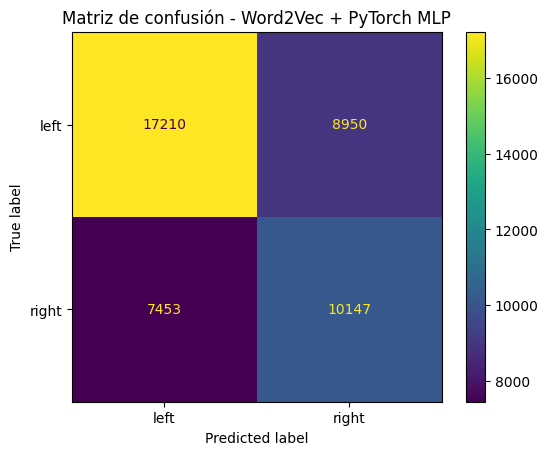

In [111]:
cm = confusion_matrix(
    y_test_true,
    y_test_pred,
    labels=label_encoder.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Word2Vec + PyTorch MLP")
plt.show()

### Guardado de resultados

Se añaden las métricas del modelo `Word2Vec + PyTorch MLP` a la tabla global de resultados, para compararlo después con el resto de modelos.

In [112]:
# Se guardan las métricas del modelo en la tabla global de resultados.
w2v_mlp_results = {
    "model": "Word2Vec average + PyTorch MLP",
    "test_accuracy": test_acc,
    "test_f1_macro": test_f1,
    "test_f1_weighted": f1_score(y_test_true, y_test_pred, average="weighted"),
    "best_cv_f1_macro": best_w2v_mlp_params["best_cv_f1_macro"],
    "best_params": best_w2v_mlp_params,
    "test_roc_auc": np.nan
}

# Se actualiza la tabla acumulada de resultados evitando duplicados por nombre de modelo.
model_results_df = update_model_results(w2v_mlp_results)

model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


La tabla anterior resume los seis modelos requeridos que combinan las tres técnicas de vectorización con un modelo de Scikit-learn y una red neuronal implementada en PyTorch.

Los resultados muestran que, antes del fine-tuning del Transformer, el mejor rendimiento en test lo obtiene `TF-IDF + Logistic Regression`. Esto indica que una representación léxica clásica sigue siendo competitiva para esta tarea, probablemente porque ciertas palabras, expresiones o n-gramas contienen señales relevantes para la clasificación ideológica.

También se observa que los modelos PyTorch basados en representaciones vectoriales previas no superan claramente a los modelos lineales de Scikit-learn. Esto puede deberse a que las representaciones ya condensan gran parte de la información disponible y a que una red neuronal adicional puede requerir más datos, regularización o ajuste para mejorar el rendimiento.

En varios modelos existe una diferencia entre el rendimiento en validación cruzada y el rendimiento en test, por lo que la comparación final debe basarse principalmente en el conjunto `test_codalab`, reservado como evaluación final independiente.

### Nota metodológica sobre la comparación de redes PyTorch

Los modelos PyTorch de los apartados 3.4, 3.5 y 3.6 comparten la misma arquitectura base de clasificación (`MLPClassifier`) y el mismo esquema general de entrenamiento: validación cruzada estratificada y agrupada por `label`, selección mediante `F1-macro`, uso de `CrossEntropyLoss`, optimización con `AdamW`, pesos de clase calculados sobre el fold de entrenamiento, `batch_size = 256`, `max_epochs = 10` y `patience = 2`.

Las diferencias entre las parrillas de hiperparámetros se deben a la naturaleza de cada representación vectorial. En TF-IDF se incluye `n_components` porque la matriz dispersa se reduce mediante `TruncatedSVD`; en Word2Vec se exploran parámetros propios del entrenamiento de embeddings, como `vector_size` y `sg`; y en BERT `[CLS]` se trabaja con embeddings precomputados, por lo que la búsqueda se centra en la arquitectura y regularización del clasificador.

Por tanto, la comparación no exige que todas las representaciones tengan exactamente la misma parrilla, sino que cada una se evalúe mediante una búsqueda controlada, sin fuga de información y usando el mismo criterio de selección. La comparación final se realizará sobre `test_codalab`, que permanece reservado como conjunto de evaluación independiente.

## 3.7 Transformer preentrenado fine-tuned con Hugging Face

En este apartado se entrena el séptimo modelo requerido: un Transformer preentrenado ajustado mediante fine-tuning con la librería Hugging Face Transformers.

A diferencia de los seis modelos anteriores, este modelo no utiliza una representación vectorial fija calculada previamente. En este caso, el propio tokenizador del Transformer convierte cada tweet en una secuencia de tokens, y el modelo completo se ajusta para la tarea supervisada de clasificación ideológica.

Debido al coste computacional del fine-tuning, no se realiza una validación cruzada completa. En su lugar, se define una partición interna de entrenamiento y validación a partir de `train_public`, manteniendo la estratificación de clases y evitando solapamiento de clusters mediante `StratifiedGroupKFold`.

Para evitar una selección arbitraria de hiperparámetros, se define una parrilla reducida de configuraciones. Primero se selecciona la mejor configuración usando la partición interna de validación y, posteriormente, se entrena un modelo final con todo `train_public`.

El conjunto `test_codalab` se mantiene reservado exclusivamente para la evaluación final.

In [113]:
# Se importan librerías generales para gestión de ficheros, datos y configuración.
import json
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import torch

# Se importan herramientas de Scikit-learn para la partición interna y las métricas.
from sklearn.model_selection import StratifiedGroupKFold, ParameterGrid
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Se importan las clases principales de Hugging Face Transformers.
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

# Se fija la semilla para favorecer la reproducibilidad del experimento.
RANDOM_STATE = 42
set_seed(RANDOM_STATE)

# Se selecciona GPU si está disponible; en caso contrario, se utiliza CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo utilizado:", device)

if torch.cuda.is_available():
    print("GPU detectada:", torch.cuda.get_device_name(0))

Dispositivo utilizado: cuda
GPU detectada: NVIDIA GeForce RTX 4060


### Selección del texto de entrada

Para el fine-tuning se utiliza `tweet_transformer`, una versión del texto preparada para modelos Transformer. A diferencia de `tweet_clean`, esta columna conserva mejor la estructura lingüística del tweet, lo que resulta más adecuado para un modelo preentrenado.

En esta celda se comprueba que la columna existe en los conjuntos de entrenamiento y test, se sustituyen posibles valores nulos por cadenas vacías y se convierte el contenido a tipo texto.

In [114]:
# Se selecciona la columna de texto que se utilizará para el fine-tuning.
TEXT_COL_HF = "tweet_transformer"

# Se comprueba que la columna existe en train y test antes de continuar.
assert TEXT_COL_HF in train_df.columns, (
    f"No se encuentra la columna {TEXT_COL_HF} en train_df."
)

assert TEXT_COL_HF in test_df.columns, (
    f"No se encuentra la columna {TEXT_COL_HF} en test_df."
)

# Se sustituyen posibles valores nulos por cadenas vacías y se asegura tipo string.
X_train_hf_text = train_df[TEXT_COL_HF].fillna("").astype(str)
X_test_hf_text = test_df[TEXT_COL_HF].fillna("").astype(str)

# Se comprueba que el número de textos coincide con el número de etiquetas.
assert len(X_train_hf_text) == len(y_train), (
    "El número de textos de entrenamiento no coincide con el número de etiquetas."
)

assert len(X_test_hf_text) == len(y_test), (
    "El número de textos de test no coincide con el número de etiquetas."
)

print("Textos HF de entrenamiento:", X_train_hf_text.shape)
print("Textos HF de test:", X_test_hf_text.shape)
print("Etiquetas de entrenamiento:", y_train.shape)
print("Etiquetas de test:", y_test.shape)

Textos HF de entrenamiento: (180000,)
Textos HF de test: (43760,)
Etiquetas de entrenamiento: (180000,)
Etiquetas de test: (43760,)


### División entrenamiento / validación / test

Debido al coste computacional del fine-tuning de Transformers, no se realiza una validación cruzada completa. En su lugar, se utiliza una partición interna train/validation generada mediante `StratifiedGroupKFold`.

Esta partición mantiene la proporción de clases y evita que tweets del mismo cluster aparezcan simultáneamente en entrenamiento y validación. Esta decisión es especialmente importante porque la variable `label` representa agrupaciones o clusters de propagación, por lo que mezclar tweets del mismo cluster entre entrenamiento y validación podría producir fuga de información.

El conjunto `test_codalab` queda reservado como test final independiente y no se utiliza durante la selección de hiperparámetros.

In [115]:
# Se define un splitter estratificado y agrupado.
# La estratificación mantiene la proporción de clases y la agrupación evita fuga entre clusters.
hf_splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Se toma el primer fold como partición interna train/validation.
# No se usa test_codalab en este proceso.
hf_train_idx, hf_valid_idx = next(
    hf_splitter.split(
        X_train_hf_text,
        y_train,
        groups_train
    )
)

# Se construyen los textos para entrenamiento interno, validación interna y test final.
hf_train_texts = X_train_hf_text.iloc[hf_train_idx].tolist()
hf_valid_texts = X_train_hf_text.iloc[hf_valid_idx].tolist()
hf_test_texts = X_test_hf_text.tolist()

# Se construyen las etiquetas codificadas numéricamente.
hf_train_labels = y_train_enc[hf_train_idx]
hf_valid_labels = y_train_enc[hf_valid_idx]
hf_test_labels = y_test_enc

# Se comprueba que no haya fuga de clusters entre entrenamiento y validación.
hf_train_groups = np.asarray(groups_train)[hf_train_idx]
hf_valid_groups = np.asarray(groups_train)[hf_valid_idx]

overlapping_hf_groups = set(hf_train_groups).intersection(set(hf_valid_groups))

print("Clusters solapados entre HF train y HF validation:", len(overlapping_hf_groups))

assert len(overlapping_hf_groups) == 0, (
    "Hay clusters compartidos entre entrenamiento y validación en el fine-tuning."
)

# Se muestran tamaños de las particiones.
print("Tamaño HF train interno:", len(hf_train_texts))
print("Tamaño HF validation interno:", len(hf_valid_texts))
print("Tamaño HF test final:", len(hf_test_texts))

# Se muestran distribuciones de clases para comprobar que la estratificación es razonable.
print("\nDistribución de clases en HF train interno:")
print(pd.Series(label_encoder.inverse_transform(hf_train_labels)).value_counts(normalize=True))

print("\nDistribución de clases en HF validation interno:")
print(pd.Series(label_encoder.inverse_transform(hf_valid_labels)).value_counts(normalize=True))

Clusters solapados entre HF train y HF validation: 0
Tamaño HF train interno: 144000
Tamaño HF validation interno: 36000
Tamaño HF test final: 43760

Distribución de clases en HF train interno:
left     0.557222
right    0.442778
Name: proportion, dtype: float64

Distribución de clases en HF validation interno:
left     0.56
right    0.44
Name: proportion, dtype: float64


### Modelo preentrenado, tokenizador y directorio del experimento

Se utiliza un modelo BERT preentrenado para español. El tokenizador asociado convierte cada tweet en los identificadores numéricos de tokens que el Transformer puede procesar.

El parámetro `MAX_LEN` fija la longitud máxima de las secuencias. Si un tweet supera esa longitud, se trunca; si es más corto, se rellena mediante padding. Se mantiene un valor moderado para controlar el coste computacional del fine-tuning.

También se define un directorio de resultados específico para esta configuración, incorporando el nombre del modelo, la columna de texto y la longitud máxima. De esta forma se evita reutilizar accidentalmente cachés de experimentos anteriores con otra configuración.

In [116]:
# Se selecciona el modelo Transformer preentrenado.
# En este caso se utiliza BETO, un BERT entrenado sobre textos en español.
HF_MODEL_NAME = "dccuchile/bert-base-spanish-wwm-cased"

# Se define la longitud máxima de entrada para el tokenizador.
# Los textos más largos se truncarán y los más cortos se rellenarán con padding.
MAX_LEN = 96

# Se carga el tokenizador asociado al modelo preentrenado.
tokenizer = AutoTokenizer.from_pretrained(HF_MODEL_NAME)

# Se construyen los diccionarios de correspondencia entre etiquetas textuales
# e identificadores numéricos. Hugging Face los utiliza para documentar
# correctamente las clases del modelo.
label2id = {
    label: idx
    for idx, label in enumerate(label_encoder.classes_)
}

id2label = {
    idx: label
    for label, idx in label2id.items()
}

# Se define un nombre único para el experimento.
# Esto evita mezclar cachés si se cambia el modelo, la columna de texto o MAX_LEN.
HF_EXPERIMENT_NAME = (
    f"hf_transformer_"
    f"{HF_MODEL_NAME.replace('/', '_').replace('-', '_')}_"
    f"{TEXT_COL_HF}_"
    f"maxlen{MAX_LEN}_weighted"
)

# Se define el directorio donde se guardarán los resultados del fine-tuning.
HF_RESULTS_DIR = Path("models") / HF_EXPERIMENT_NAME
HF_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Modelo Hugging Face:", HF_MODEL_NAME)
print("Longitud máxima:", MAX_LEN)
print("Directorio de resultados:", HF_RESULTS_DIR)
print("label2id:", label2id)
print("id2label:", id2label)

Modelo Hugging Face: dccuchile/bert-base-spanish-wwm-cased
Longitud máxima: 96
Directorio de resultados: models\hf_transformer_dccuchile_bert_base_spanish_wwm_cased_tweet_transformer_maxlen96_weighted
label2id: {'left': 0, 'right': 1}
id2label: {0: 'left', 1: 'right'}


### Dataset para Hugging Face

Se define un `Dataset` compatible con `Trainer`.

Cada muestra contiene:

- `input_ids`: identificadores numéricos de los tokens;
- `attention_mask`: máscara que indica qué posiciones corresponden a tokens reales y cuáles corresponden a padding;
- `labels`: etiqueta de clase codificada numéricamente.

La tokenización se realiza una vez al crear el dataset para evitar repetir este proceso durante cada época de entrenamiento.

In [117]:
# Se define un Dataset compatible con Hugging Face Trainer.
# Este objeto encapsula la tokenización de los textos y las etiquetas asociadas.
class HFDataset(torch.utils.data.Dataset):
    """
    Dataset compatible con Hugging Face Trainer.

    Cada elemento contiene los tensores necesarios para el Transformer:
    input_ids, attention_mask y labels.
    """

    def __init__(self, texts, labels, tokenizer, max_length=64):
        # Se tokenizan todos los textos al crear el dataset.
        # truncation=True limita los textos a max_length.
        # padding="max_length" asegura que todas las secuencias tengan la misma longitud.
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_length
        )

        # Se guardan las etiquetas como lista para indexarlas después.
        self.labels = list(labels)

    def __len__(self):
        # Devuelve el número de muestras del dataset.
        return len(self.labels)

    def __getitem__(self, idx):
        # Se recupera la muestra idx y se convierte cada campo tokenizado a tensor.
        item = {
            key: torch.tensor(value[idx])
            for key, value in self.encodings.items()
        }

        # Se añade la etiqueta como tensor long, formato esperado por CrossEntropyLoss.
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item


# Dataset interno de entrenamiento usado durante la búsqueda de hiperparámetros.
hf_train_dataset = HFDataset(
    hf_train_texts,
    hf_train_labels,
    tokenizer,
    max_length=MAX_LEN
)

# Dataset interno de validación usado para seleccionar hiperparámetros.
hf_valid_dataset = HFDataset(
    hf_valid_texts,
    hf_valid_labels,
    tokenizer,
    max_length=MAX_LEN
)

# Dataset de test final. No se utiliza durante la selección de hiperparámetros.
hf_test_dataset = HFDataset(
    hf_test_texts,
    hf_test_labels,
    tokenizer,
    max_length=MAX_LEN
)

# Dataset con todo train_public. Se usará para entrenar el modelo final
# una vez seleccionados los mejores hiperparámetros.
hf_full_train_dataset = HFDataset(
    X_train_hf_text.tolist(),
    y_train_enc,
    tokenizer,
    max_length=MAX_LEN
)

print("Tamaño HF train interno:", len(hf_train_dataset))
print("Tamaño HF validation interno:", len(hf_valid_dataset))
print("Tamaño HF train completo:", len(hf_full_train_dataset))
print("Tamaño HF test final:", len(hf_test_dataset))

# Comprobaciones defensivas de tamaños.
assert len(hf_train_dataset) == len(hf_train_labels)
assert len(hf_valid_dataset) == len(hf_valid_labels)
assert len(hf_full_train_dataset) == len(y_train_enc)
assert len(hf_test_dataset) == len(hf_test_labels)

Tamaño HF train interno: 144000
Tamaño HF validation interno: 36000
Tamaño HF train completo: 180000
Tamaño HF test final: 43760


### Métricas de evaluación

Se definen las métricas utilizadas por `Trainer` durante la validación y la evaluación final:

- `accuracy`;
- `F1-macro`;
- `F1-weighted`;
- `ROC-AUC`.

La métrica principal para seleccionar el mejor modelo será `F1-macro`, manteniendo coherencia con el resto de modelos del proyecto.

In [118]:
# Se definen las métricas usadas por Hugging Face Trainer durante validación y test.
def compute_hf_metrics(eval_pred):
    """
    Se calculan las métricas de evaluación utilizadas por Hugging Face Trainer.
    """
    # Trainer devuelve logits y etiquetas reales.
    logits, labels = eval_pred

    # La clase predicha es la de mayor logit.
    preds = np.argmax(logits, axis=1)

    # Se calculan métricas principales de clasificación.
    metrics = {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted")
    }

    # Para ROC-AUC se necesitan probabilidades de la clase positiva.
    # Si por cualquier motivo no se puede calcular, se guarda NaN.
    try:
        probs = torch.softmax(
            torch.tensor(logits),
            dim=1
        ).numpy()

        metrics["roc_auc"] = roc_auc_score(labels, probs[:, 1])

    except Exception:
        metrics["roc_auc"] = np.nan

    return metrics


from sklearn.utils.class_weight import compute_class_weight


class WeightedLossTrainer(Trainer):
    """
    Trainer de Hugging Face con pérdida ponderada por clase.

    Se utiliza para compensar parcialmente el desbalance entre clases durante
    el fine-tuning del Transformer.
    """

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)

        if class_weights is None:
            self.class_weights = None
        else:
            self.class_weights = class_weights.float()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Se extraen las etiquetas reales del batch.
        labels = inputs.get("labels")

        # Se ejecuta el modelo para obtener los logits.
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Se define CrossEntropyLoss con pesos de clase si están disponibles.
        if self.class_weights is not None:
            loss_fct = torch.nn.CrossEntropyLoss(
                weight=self.class_weights.to(logits.device)
            )
        else:
            loss_fct = torch.nn.CrossEntropyLoss()

        # Se calcula la pérdida ponderada.
        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

### Funciones para crear argumentos de entrenamiento

Los hiperparámetros de entrenamiento se centralizan en funciones que devuelven objetos `TrainingArguments`.

Se definen dos funciones:

- Una para la búsqueda de hiperparámetros, donde sí existe evaluación sobre validación;
- Otra para el entrenamiento final, donde se ajusta el modelo con todo `train_public` y no se usa validación.

También se incluye compatibilidad entre versiones de Transformers, ya que algunas versiones utilizan `eval_strategy` y otras `evaluation_strategy`.

In [119]:
# Se definen los argumentos de entrenamiento para seleccionar hiperparámetros
# del Transformer con validación interna.
def create_hf_tuning_args(
    output_dir,
    learning_rate,
    num_train_epochs,
    weight_decay,
    per_device_train_batch_size,
    per_device_eval_batch_size=32,
    seed=42
):
    """
    Se definen los argumentos de entrenamiento para la búsqueda de hiperparámetros
    con validación interna.
    """
    # Argumentos comunes a distintas versiones de Transformers.
    common_kwargs = dict(
        output_dir=str(output_dir),
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,

        # Se registra una vez por época.
        logging_strategy="epoch",

        # Se guarda un checkpoint por época para poder recuperar el mejor modelo.
        save_strategy="epoch",

        # Se carga al final el mejor modelo según la métrica indicada.
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,

        # Se limita el número de checkpoints guardados.
        save_total_limit=1,

        # Se desactiva la integración con servicios externos como wandb.
        report_to="none",

        # Se activa fp16 si hay GPU compatible.
        fp16=torch.cuda.is_available(),

        # Se fija la semilla para reproducibilidad.
        seed=seed,

        # Se mantiene visible la barra de progreso.
        disable_tqdm=False
    )

    # Compatibilidad entre versiones de Transformers.
    # Algunas versiones usan eval_strategy y otras evaluation_strategy.
    try:
        return TrainingArguments(
            eval_strategy="epoch",
            **common_kwargs
        )
    except TypeError:
        return TrainingArguments(
            evaluation_strategy="epoch",
            **common_kwargs
        )


# Se definen los argumentos para reentrenar el Transformer final
# usando todo train_public.
def create_hf_final_args(
    output_dir,
    learning_rate,
    num_train_epochs,
    weight_decay,
    per_device_train_batch_size,
    per_device_eval_batch_size=32,
    seed=42
):
    """
    Se definen los argumentos de entrenamiento final sobre todo train_public.

    En este ajuste final no se utiliza validación, ya que los hiperparámetros
    se han seleccionado previamente mediante la partición interna de validación.
    """
    common_kwargs = dict(
        output_dir=str(output_dir),
        learning_rate=learning_rate,
        per_device_train_batch_size=per_device_train_batch_size,
        per_device_eval_batch_size=per_device_eval_batch_size,
        num_train_epochs=num_train_epochs,
        weight_decay=weight_decay,

        # Se registra el entrenamiento una vez por época.
        logging_strategy="epoch",

        # En el entrenamiento final no se guardan checkpoints intermedios.
        save_strategy="no",

        # Se desactiva el reporte externo.
        report_to="none",

        # Se activa fp16 si hay GPU disponible.
        fp16=torch.cuda.is_available(),

        # Se fija semilla para reproducibilidad.
        seed=seed,

        # Se mantiene visible la barra de progreso.
        disable_tqdm=False
    )

    # No hay evaluación durante el entrenamiento final.
    try:
        return TrainingArguments(
            eval_strategy="no",
            **common_kwargs
        )
    except TypeError:
        return TrainingArguments(
            evaluation_strategy="no",
            **common_kwargs
        )

### Parrilla de hiperparámetros para el fine-tuning

Se define una parrilla reducida de hiperparámetros para el ajuste del Transformer. Debido al mayor coste computacional del fine-tuning frente a los modelos clásicos, se evalúa un número limitado de configuraciones.

La selección se realiza usando la partición interna de validación creada previamente. La métrica principal vuelve a ser `F1-macro`, manteniendo coherencia con el resto de modelos del proyecto.

In [120]:
# Se define una parrilla reducida de hiperparámetros para el fine-tuning.
# El tamaño de la parrilla se mantiene controlado por el alto coste computacional
# de entrenar Transformers.
param_grid_hf = {
    "learning_rate": [1e-5, 2e-5],
    "num_train_epochs": [2, 3],
    "weight_decay": [0.01],
    "per_device_train_batch_size": [16]
}

# Se generan todas las combinaciones de hiperparámetros.
hf_param_configurations = list(ParameterGrid(param_grid_hf))

print("Número de configuraciones HF evaluadas:", len(hf_param_configurations))

pd.DataFrame(hf_param_configurations)

Número de configuraciones HF evaluadas: 4


,learning_rate,num_train_epochs,per_device_train_batch_size,weight_decay
0,0.00001,2,16,0.01
1,0.00001,3,16,0.01
2,0.00002,2,16,0.01
3,0.00002,3,16,0.01


In [121]:
# Se calculan pesos de clase usando solo la partición interna de entrenamiento.
# Esto evita utilizar información de validación o test para definir la pérdida.
hf_tuning_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_encoder.classes_)),
    y=hf_train_labels
)

hf_tuning_class_weights = torch.tensor(
    hf_tuning_class_weights,
    dtype=torch.float32
)

print("Clases:", label_encoder.classes_)
print("Pesos de clase para HF tuning:", hf_tuning_class_weights)

Clases: ['left' 'right']
Pesos de clase para HF tuning: tensor([0.8973, 1.1292])


### Fine-tuning con validación interna

En esta celda se entrena un modelo Transformer para cada configuración de la parrilla de hiperparámetros.

Cada configuración se evalúa sobre la partición interna de validación. Se guarda el F1-macro obtenido y se selecciona como mejor configuración aquella que maximiza esta métrica.

Los resultados se almacenan en disco para evitar repetir entrenamientos costosos al reejecutar el notebook.

In [122]:
# Se definen rutas específicas para guardar los resultados del ajuste de hiperparámetros.
hf_tuning_results_path = HF_RESULTS_DIR / "hf_tuning_results.csv"
hf_best_params_path = HF_RESULTS_DIR / "hf_best_params.json"

# Si se activa esta variable, se fuerza de nuevo la búsqueda de hiperparámetros.
FORCE_RETRAIN_HF_TUNING = False

# Se comprueba si ya existen resultados previos de la búsqueda.
hf_tuning_is_cached = (
    hf_tuning_results_path.exists()
    and hf_best_params_path.exists()
)

RUN_HF_TUNING = (
    FORCE_RETRAIN_HF_TUNING
    or not hf_tuning_is_cached
)

print("Resultados HF tuning en caché:", hf_tuning_is_cached)
print("Forzar reentrenamiento HF tuning:", FORCE_RETRAIN_HF_TUNING)
print("Ejecutar HF tuning:", RUN_HF_TUNING)

if hf_tuning_is_cached and not RUN_HF_TUNING:
    # Se cargan los resultados de validación si ya existen.
    hf_tuning_results_df = pd.read_csv(hf_tuning_results_path)

    with open(hf_best_params_path, "r", encoding="utf-8") as f:
        best_hf_params = json.load(f)

    best_hf_f1_macro = hf_tuning_results_df["eval_f1_macro"].max()

    print("Resultados HF tuning cargados desde caché.")

else:
    hf_tuning_results = []

    # Se entrena una configuración por iteración.
    for config_id, params in enumerate(hf_param_configurations, start=1):
        print("=" * 80)
        print(f"Configuración HF {config_id}/{len(hf_param_configurations)}")
        print(params)

        # Se fija la semilla antes de cada entrenamiento.
        set_seed(RANDOM_STATE)

        # Se define el directorio de salida de esta configuración.
        config_output_dir = HF_RESULTS_DIR / f"tuning_config_{config_id}"

        # Si existe un directorio previo de esta configuración, se elimina
        # para evitar mezclar checkpoints antiguos.
        if config_output_dir.exists():
            shutil.rmtree(config_output_dir)

        # Se carga un modelo preentrenado nuevo para cada configuración.
        model = AutoModelForSequenceClassification.from_pretrained(
            HF_MODEL_NAME,
            num_labels=len(label_encoder.classes_),
            label2id=label2id,
            id2label=id2label
        )

        # Se crean los argumentos de entrenamiento para esta configuración.
        training_args = create_hf_tuning_args(
            output_dir=config_output_dir,
            learning_rate=params["learning_rate"],
            num_train_epochs=params["num_train_epochs"],
            weight_decay=params["weight_decay"],
            per_device_train_batch_size=params["per_device_train_batch_size"],
            per_device_eval_batch_size=32,
            seed=RANDOM_STATE
        )

        # Se construye el Trainer con train interno y validación interna.
        trainer = WeightedLossTrainer(
            model=model,
            args=training_args,
            train_dataset=hf_train_dataset,
            eval_dataset=hf_valid_dataset,
            tokenizer=tokenizer,
            compute_metrics=compute_hf_metrics,
            class_weights=hf_tuning_class_weights
        )

        # Se entrena el modelo para la configuración actual.
        trainer.train()

        # Se evalúa sobre la partición interna de validación.
        eval_metrics = trainer.evaluate()

        # Se combina la configuración con sus métricas de validación.
        result_row = {
            "config_id": config_id,
            **params,
            **eval_metrics
        }

        hf_tuning_results.append(result_row)

        print("Métricas de validación:")
        print(eval_metrics)

        # Se libera memoria de GPU si aplica.
        del model
        del trainer

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Se construye el dataframe con todos los resultados.
    hf_tuning_results_df = pd.DataFrame(hf_tuning_results)

    # Se ordenan las configuraciones por F1-macro de validación.
    hf_tuning_results_df = (
        hf_tuning_results_df
        .sort_values("eval_f1_macro", ascending=False)
        .reset_index(drop=True)
    )

    # Se selecciona la mejor configuración.
    best_hf_row = hf_tuning_results_df.iloc[0]

    best_hf_params = {
        "learning_rate": float(best_hf_row["learning_rate"]),
        "num_train_epochs": int(best_hf_row["num_train_epochs"]),
        "weight_decay": float(best_hf_row["weight_decay"]),
        "per_device_train_batch_size": int(best_hf_row["per_device_train_batch_size"])
    }

    best_hf_f1_macro = float(best_hf_row["eval_f1_macro"])

    # Se guardan resultados y mejores hiperparámetros.
    hf_tuning_results_df.to_csv(
        hf_tuning_results_path,
        index=False
    )

    with open(hf_best_params_path, "w", encoding="utf-8") as f:
        json.dump(best_hf_params, f, indent=4)

    print("Resultados HF tuning guardados en:", hf_tuning_results_path)
    print("Mejores hiperparámetros HF guardados en:", hf_best_params_path)

print("Mejor F1-macro HF en validación:", best_hf_f1_macro)
print("Mejores hiperparámetros HF:", best_hf_params)

hf_tuning_results_df

Resultados HF tuning en caché: True
Forzar reentrenamiento HF tuning: False
Ejecutar HF tuning: False
Resultados HF tuning cargados desde caché.
Mejor F1-macro HF en validación: 0.7393225990494455
Mejores hiperparámetros HF: {'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}


,config_id,learning_rate,num_train_epochs,per_device_train_batch_size,weight_decay,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_roc_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,4,0.00002,3,16,0.01,0.691722,0.741722,0.739323,0.742324,0.828321,35.7471,1007.076,31.471,3.0
1,2,0.00001,3,16,0.01,0.601988,0.740972,0.738716,0.741630,0.825534,35.8262,1004.853,31.402,3.0
2,3,0.00002,2,16,0.01,0.563668,0.738361,0.736466,0.739148,0.825115,35.6285,1010.426,31.576,2.0
3,1,0.00001,2,16,0.01,0.552086,0.733389,0.731479,0.734197,0.818281,36.1472,995.927,31.123,2.0


La tabla anterior muestra la búsqueda reducida de hiperparámetros del Transformer. La mejor configuración se selecciona usando `F1-macro` sobre la partición interna de validación. Esta estrategia evita fijar manualmente los hiperparámetros y mantiene el conjunto `test_codalab` intacto para la evaluación final.

### Entrenamiento final del Transformer

Una vez seleccionados los mejores hiperparámetros mediante la partición interna de validación, se entrena un modelo Transformer final utilizando todo `train_public`.

En este ajuste final no se utiliza validación, ya que la selección de hiperparámetros se ha realizado previamente. El objetivo es aprovechar todos los datos disponibles de entrenamiento antes de evaluar el modelo final sobre `test_codalab`.

Para evitar reutilizar accidentalmente un modelo entrenado con otra configuración, se guarda también el diccionario de hiperparámetros utilizado en el entrenamiento final.

In [123]:
# Se define el directorio donde se guardará el modelo final.
HF_FINAL_MODEL_DIR = HF_RESULTS_DIR / "final_model_full_train"

# Se definen rutas para guardar el historial y los hiperparámetros del modelo final.
hf_final_train_history_path = HF_RESULTS_DIR / "hf_final_training_history.json"
hf_final_params_path = HF_RESULTS_DIR / "hf_final_params.json"

# Si se activa esta variable, se fuerza el reentrenamiento del modelo final.
FORCE_RETRAIN_HF_FINAL = False

# Se comprueba si ya existe un modelo final guardado junto con sus hiperparámetros.
hf_final_is_cached = (
    HF_FINAL_MODEL_DIR.exists()
    and hf_final_params_path.exists()
)

# Si existe caché, se comprueba que los hiperparámetros guardados coinciden
# con los mejores hiperparámetros seleccionados en el tuning.
if hf_final_is_cached:
    with open(hf_final_params_path, "r", encoding="utf-8") as f:
        cached_final_params = json.load(f)

    hf_final_cache_matches = cached_final_params == best_hf_params
else:
    hf_final_cache_matches = False

# Se decide si hay que entrenar de nuevo el modelo final.
RUN_HF_FINAL = (
    FORCE_RETRAIN_HF_FINAL
    or not hf_final_is_cached
    or not hf_final_cache_matches
)

# Se calculan pesos de clase usando todo train_public para el entrenamiento final.
hf_final_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(label_encoder.classes_)),
    y=y_train_enc
)

hf_final_class_weights = torch.tensor(
    hf_final_class_weights,
    dtype=torch.float32
)

print("Pesos de clase para HF final:", hf_final_class_weights)

print("Modelo final HF en caché:", hf_final_is_cached)
print("La caché coincide con los mejores hiperparámetros:", hf_final_cache_matches)
print("Forzar reentrenamiento HF final:", FORCE_RETRAIN_HF_FINAL)
print("Ejecutar entrenamiento HF final:", RUN_HF_FINAL)

if hf_final_is_cached and not RUN_HF_FINAL:
    # Se carga el modelo final desde disco.
    final_hf_model = AutoModelForSequenceClassification.from_pretrained(
        HF_FINAL_MODEL_DIR
    )

    final_hf_model.to(device)

    print("Modelo final HF cargado desde caché.")

else:
    # Si existe un directorio anterior pero no coincide con la configuración actual,
    # se elimina para evitar mezclar artefactos.
    if HF_FINAL_MODEL_DIR.exists():
        shutil.rmtree(HF_FINAL_MODEL_DIR)

    # Se fija la semilla antes del entrenamiento final.
    set_seed(RANDOM_STATE)

    # Se carga un modelo preentrenado nuevo para entrenarlo desde cero
    # con los mejores hiperparámetros encontrados.
    final_hf_model = AutoModelForSequenceClassification.from_pretrained(
        HF_MODEL_NAME,
        num_labels=len(label_encoder.classes_),
        label2id=label2id,
        id2label=id2label
    )

    # Se crean los argumentos del entrenamiento final.
    final_training_args = create_hf_final_args(
        output_dir=HF_FINAL_MODEL_DIR,
        learning_rate=best_hf_params["learning_rate"],
        num_train_epochs=best_hf_params["num_train_epochs"],
        weight_decay=best_hf_params["weight_decay"],
        per_device_train_batch_size=best_hf_params["per_device_train_batch_size"],
        per_device_eval_batch_size=32,
        seed=RANDOM_STATE
    )

    # Se construye el Trainer final usando todo train_public.
    final_trainer = WeightedLossTrainer(
        model=final_hf_model,
        args=final_training_args,
        train_dataset=hf_full_train_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_hf_metrics,
        class_weights=hf_final_class_weights
    )

    # Se entrena el modelo final.
    final_train_output = final_trainer.train()

    # Se guarda el modelo final y el tokenizador.
    final_trainer.save_model(HF_FINAL_MODEL_DIR)
    tokenizer.save_pretrained(HF_FINAL_MODEL_DIR)

    # Se guarda el historial básico del entrenamiento final.
    final_train_history = {
        "training_loss": float(final_train_output.training_loss),
        "global_step": int(final_train_output.global_step),
        "best_hf_params": best_hf_params
    }

    with open(hf_final_train_history_path, "w", encoding="utf-8") as f:
        json.dump(final_train_history, f, indent=4)

    # Se guardan los hiperparámetros usados para poder validar la caché en futuras ejecuciones.
    with open(hf_final_params_path, "w", encoding="utf-8") as f:
        json.dump(best_hf_params, f, indent=4)

    print("Modelo final HF entrenado y guardado en:", HF_FINAL_MODEL_DIR)

Pesos de clase para HF final: tensor([0.8964, 1.1307])
Modelo final HF en caché: True
La caché coincide con los mejores hiperparámetros: True
Forzar reentrenamiento HF final: False
Ejecutar entrenamiento HF final: False
Modelo final HF cargado desde caché.


### Evaluación final del Transformer sobre test

El modelo Transformer final se evalúa una única vez sobre `test_codalab`.

Este conjunto no se ha utilizado ni durante la búsqueda de hiperparámetros ni durante el entrenamiento final, por lo que proporciona una estimación independiente del rendimiento del modelo.

In [124]:
# Se construye un Trainer para evaluar el modelo final sobre test_codalab.
hf_test_trainer = Trainer(
    model=final_hf_model,
    args=create_hf_final_args(
        output_dir=HF_RESULTS_DIR / "test_evaluation",
        learning_rate=best_hf_params["learning_rate"],
        num_train_epochs=best_hf_params["num_train_epochs"],
        weight_decay=best_hf_params["weight_decay"],
        per_device_train_batch_size=best_hf_params["per_device_train_batch_size"],
        per_device_eval_batch_size=32,
        seed=RANDOM_STATE
    ),
    tokenizer=tokenizer,
    compute_metrics=compute_hf_metrics
)

# Se obtienen predicciones sobre el conjunto de test.
hf_test_predictions = hf_test_trainer.predict(hf_test_dataset)

# Se extraen logits y etiquetas reales.
hf_test_logits = hf_test_predictions.predictions
hf_test_true_enc = hf_test_predictions.label_ids

# Se obtiene la clase predicha como la de mayor logit.
hf_test_pred_enc = np.argmax(hf_test_logits, axis=1)

# Se convierten las etiquetas codificadas a sus nombres originales.
hf_test_true = label_encoder.inverse_transform(hf_test_true_enc)
hf_test_pred = label_encoder.inverse_transform(hf_test_pred_enc)

# Se calculan probabilidades para ROC-AUC.
hf_test_probs = torch.softmax(
    torch.tensor(hf_test_logits),
    dim=1
).numpy()

# Se calculan métricas finales.
hf_test_accuracy = accuracy_score(hf_test_true, hf_test_pred)
hf_test_f1_macro = f1_score(hf_test_true, hf_test_pred, average="macro")
hf_test_f1_weighted = f1_score(hf_test_true, hf_test_pred, average="weighted")

try:
    hf_test_roc_auc = roc_auc_score(hf_test_true_enc, hf_test_probs[:, 1])
except Exception:
    hf_test_roc_auc = np.nan

print("Resultados en test - Hugging Face Transformer fine-tuning")
print("=" * 80)
print("Accuracy en test:", round(hf_test_accuracy, 4))
print("F1-macro en test:", round(hf_test_f1_macro, 4))
print("F1-weighted en test:", round(hf_test_f1_weighted, 4))
print("ROC-AUC en test:", round(hf_test_roc_auc, 4))

print("\nInforme de clasificación:")
print(classification_report(hf_test_true, hf_test_pred))

C:\Users\nogue\AppData\Local\Temp\ipykernel_48940\4159632485.py:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  hf_test_trainer = Trainer(


Resultados en test - Hugging Face Transformer fine-tuning
Accuracy en test: 0.6747
F1-macro en test: 0.6649
F1-weighted en test: 0.6762
ROC-AUC en test: 0.7354

Informe de clasificación:
              precision    recall  f1-score   support

        left       0.74      0.71      0.72     26160
       right       0.59      0.63      0.61     17600

    accuracy                           0.67     43760
   macro avg       0.66      0.67      0.66     43760
weighted avg       0.68      0.67      0.68     43760



El modelo `Hugging Face Transformer fine-tuning` obtiene el mejor resultado de los modelos evaluados hasta este punto.

La accuracy en test es `0.6747`, por lo que acierta alrededor del 67% de los tweets. El `F1-macro` es `0.6649`, que mejora claramente los resultados obtenidos con TF-IDF, Word2Vec y embeddings BERT congelados.

También se obtiene un `ROC-AUC` de `0.7354`, lo que indica que el modelo tiene una capacidad razonable para separar las dos clases cuando se tienen en cuenta las probabilidades de predicción.

Por clases, el modelo sigue funcionando mejor para `left`, con un `f1-score` de `0.72`, que para `right`, donde obtiene `0.61`. Aun así, la clase `right` mejora bastante respecto a modelos anteriores, especialmente en recall, donde alcanza `0.63`.

Este resultado tiene sentido porque en este caso no se usan embeddings congelados, sino que se ajusta el Transformer completo a la tarea de clasificación. Es decir, el modelo aprende representaciones más adaptadas al problema concreto de ideología binaria.

En conjunto, el fine-tuning del Transformer es el enfoque que mejor aprovecha la información del texto y confirma que adaptar el modelo preentrenado a la tarea mejora el rendimiento frente a usar representaciones fijas.

### Matriz de confusión del Transformer

La matriz de confusión permite analizar qué clases se predicen correctamente y en qué casos el modelo confunde una ideología con la otra.

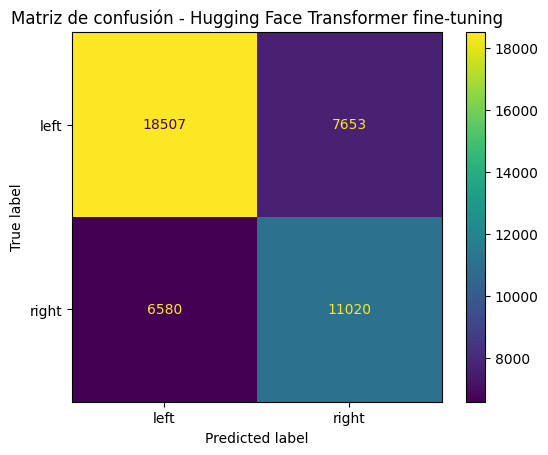

In [125]:
# Se calcula la matriz de confusión del modelo Transformer.
hf_cm = confusion_matrix(
    hf_test_true,
    hf_test_pred,
    labels=label_encoder.classes_
)

# Se visualiza la matriz de confusión.
disp = ConfusionMatrixDisplay(
    confusion_matrix=hf_cm,
    display_labels=label_encoder.classes_
)

disp.plot(values_format="d")
plt.title("Matriz de confusión - Hugging Face Transformer fine-tuning")
plt.show()

### Registro del Transformer fine-tuned en la tabla global

Una vez evaluado el modelo Transformer sobre `test_codalab`, se registran sus métricas principales en la tabla global `model_results_df`.

Esta tabla permite comparar posteriormente el rendimiento del fine-tuning frente a los modelos basados en TF-IDF, Word2Vec y embeddings BERT precomputados.

In [126]:
# Se agrupan las métricas finales del Transformer en un diccionario común
# compatible con la tabla global de resultados.
hf_transformer_results = {
    "model": "Hugging Face Transformer fine-tuning weighted",
    "test_accuracy": hf_test_accuracy,
    "test_f1_macro": hf_test_f1_macro,
    "test_f1_weighted": hf_test_f1_weighted,
    "test_roc_auc": hf_test_roc_auc,
    "best_cv_f1_macro": best_hf_f1_macro,
    "best_params": best_hf_params
}

# Se actualiza la tabla global de resultados evitando duplicados por nombre de modelo.
model_results_df = update_model_results(hf_transformer_results)

# Se ordenan los modelos por F1-macro en test, que es la métrica principal.
model_results_df = (
    model_results_df
    .sort_values("test_f1_macro", ascending=False)
    .reset_index(drop=True)
)

model_results_df

,model,test_accuracy,test_f1_macro,test_f1_weighted,best_cv_f1_macro,best_params,test_roc_auc
0,Hugging Face Transformer fine-tuning weighted,0.674749,0.664941,0.676154,0.739323,"{'learning_rate': 2e-05, 'num_train_epochs': 3, 'weight_decay': 0.01, 'per_device_train_batch_size': 16}",0.735434
1,TF-IDF + Logistic Regression,0.647235,0.636749,0.648822,0.683532,"{'clf__C': 2, 'clf__class_weight': 'balanced', 'tfidf__max_df': 0.85, 'tfidf__max_features': 50000, 'tfidf__min_df': 2, 'tfidf__ngram_range': [1, 1]}",NaN
2,Word2Vec average + PyTorch MLP,0.625160,0.615134,0.627285,0.630049,"{'vector_size': 200, 'window': 5, 'min_count': 5, 'sg': 1, 'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 6.8, 'best_cv_f1_macro': 0.6300490154167052}",NaN
3,BERT [CLS] embeddings + PyTorch MLP,0.620544,0.609439,0.622321,0.660984,"{'hidden_layers': '(256,)', 'dropout': 0.3, 'lr': 0.0003, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.8, 'best_cv_f1_macro': 0.6609837589603398}",NaN
4,TF-IDF + PyTorch MLP,0.604045,0.595388,0.606965,0.611518,"{'n_components': 256, 'hidden_layers': '(256,)', 'dropout': 0.5, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'mean_best_epoch': 8.6, 'best_cv_f1_macro': 0.6115177839168796}",NaN
5,BERT [CLS] embeddings + Logistic Regression,0.603382,0.593931,0.606049,0.615989,"{'clf__C': 0.1, 'clf__class_weight': 'balanced'}",NaN
6,Word2Vec average + Logistic Regression,0.598629,0.589029,0.601316,0.586910,"{'clf__C': 1, 'clf__class_weight': 'balanced', 'w2v__min_count': 5, 'w2v__sg': 1, 'w2v__vector_size': 100, 'w2v__window': 5}",NaN


### Guardado de predicciones del Transformer

Se guardan las predicciones del modelo Transformer sobre `test_codalab` junto con las etiquetas reales y las probabilidades estimadas.

Este archivo permite analizar posteriormente errores de clasificación, ejemplos dudosos y posibles patrones en los casos mal clasificados.

In [127]:
# Se construye un dataframe con las predicciones del Transformer sobre test.
hf_test_predictions_df = pd.DataFrame({
    "text": X_test_hf_text.values,
    "y_true": hf_test_true,
    "y_pred": hf_test_pred,
    "prob_class_0": hf_test_probs[:, 0],
    "prob_class_1": hf_test_probs[:, 1]
})

# Se marca si la predicción ha sido correcta.
hf_test_predictions_df["correct"] = (
    hf_test_predictions_df["y_true"] == hf_test_predictions_df["y_pred"]
)

# Se define la ruta de guardado.
hf_test_predictions_path = HF_RESULTS_DIR / "hf_test_predictions.csv"

# Se guardan las predicciones.
hf_test_predictions_df.to_csv(
    hf_test_predictions_path,
    index=False
)

print("Predicciones HF guardadas en:", hf_test_predictions_path)

hf_test_predictions_df.head()

Predicciones HF guardadas en: models\hf_transformer_dccuchile_bert_base_spanish_wwm_cased_tweet_transformer_maxlen96_weighted\hf_test_predictions.csv


,text,y_true,y_pred,prob_class_0,prob_class_1,correct
0,"Ayer, en Guadalajara: feministas arrojaban ácido a católicos que protegían la catedral. Quemaron a mujeres católicas con esas sustancias. Un hombre quiso sacarles los recipientes y le partieron un bate en la cabeza. Terminó internado. ¿Los medios...",right,left,0.501968,0.498032,False
1,"“Chile Vamos”, o sea, la centro-derechita cobarde, pactó hoy con el gobierno izquierdista de Boric para continuar con la farsa del proceso constituyente que acaba de ser aplastado en las urnas. Una vez más, queda demostrado que la centro-derecha ...",right,right,0.002946,0.997054,True
2,"Se está tratando de silenciar que en Bolivia, en este momento, grupos armados afines al gobierno han cercado Santa Cruz, ejerciendo una violencia inusitada contra su población. ¿Dónde están las agrupaciones de “derechos humanos”? Festejando a Lula…",right,left,0.980562,0.019438,False
3,"[USER] Lucía, lo siento pero no es así. Hebe jamás se arrepintió de nada, y Bergoglio en su carta tampoco la perdona de nada, sino que se dedica a decir qué maravillosa “defensora de los DDHH” era esta corrupta aliada del terrorismo internacional...",right,right,0.173778,0.826222,True
4,JxC no dio quórum para eliminar el impuesto a las tarjetas de crédito. “Liberales” en JxC: “¡pero no me gustan las formas de Milei [USER] !”,right,left,0.985936,0.014064,False


### Conclusión del modelo Transformer fine-tuned

En este apartado se ha entrenado un Transformer preentrenado mediante fine-tuning con Hugging Face Transformers para la tarea de clasificación ideológica.

A diferencia de los modelos anteriores, este enfoque no utiliza representaciones vectoriales fijas calculadas previamente, sino que ajusta directamente los parámetros del modelo Transformer a partir de los tweets de entrenamiento. Para controlar el coste computacional, se ha utilizado una partición interna train/validation en lugar de una validación cruzada completa.

La selección de hiperparámetros se ha realizado mediante una parrilla reducida y usando `F1-macro` como métrica principal, manteniendo coherencia con el resto de modelos. Además, la división interna se ha generado con `StratifiedGroupKFold`, evitando solapamiento de clusters entre entrenamiento y validación.

Una vez seleccionada la mejor configuración, el modelo final se ha reentrenado sobre todo `train_public` y se ha evaluado una única vez sobre `test_codalab`, que se mantiene como conjunto independiente de evaluación final.

Este experimento completa el requisito de comparar las representaciones y modelos anteriores con un Transformer preentrenado ajustado mediante fine-tuning, y sus resultados quedan registrados en la tabla global `model_results_df` para la comparación final.

## 4. Evaluación comparativa

En esta sección se comparan de forma conjunta los modelos entrenados en el apartado 3.

La comparación se realiza sobre `test_codalab`, que se ha mantenido como conjunto independiente de evaluación final. Las métricas principales utilizadas son `accuracy`, `F1-macro`, `F1-weighted` y `ROC-AUC`.

El objetivo de esta sección es analizar:

- Representación textual que ofrece mejor rendimiento.
- Tipo de arquitectura resulta más adecuada.
- Si el fine-tuning del Transformer mejora a los modelos basados en representaciones fijas.
- Cómo se relacionan estos resultados con la hipótesis inicial sobre polarización ideológica y desinformación.

### 4.1 Comprobación de modelos registrados

Antes de analizar los resultados, se comprueba que la tabla global `model_results_df` contiene todos los modelos que deben formar parte de la comparación.

Esta comprobación permite detectar errores de ejecución, modelos no registrados o diferencias en los nombres utilizados al guardar los resultados.

In [128]:
# Se define la lista de modelos principales que deben aparecer en la comparación.
# Estos nombres deben coincidir exactamente con los valores de la columna "model"
# guardados previamente en model_results_df.
expected_models = [
    "Hugging Face Transformer fine-tuning weighted",
    "TF-IDF + Logistic Regression",
    "Word2Vec average + PyTorch MLP",
    "BERT [CLS] embeddings + PyTorch MLP",
    "TF-IDF + PyTorch MLP",
    "BERT [CLS] embeddings + Logistic Regression",
    "Word2Vec average + Logistic Regression"
]

# Se comprueba qué modelos esperados no aparecen en la tabla global.
missing_models = [
    model
    for model in expected_models
    if model not in model_results_df["model"].tolist()
]

print("Modelos ausentes:", missing_models)
print("Número de modelos registrados:", len(model_results_df))

# Se verifica que no falte ningún modelo principal.
assert len(missing_models) == 0, (
    "Faltan modelos esperados en la tabla de resultados."
)

Modelos ausentes: []
Número de modelos registrados: 7


### 4.2 Tabla comparativa de métricas

Se construye una tabla compacta con las métricas principales obtenidas por cada modelo en `test_codalab`.

La métrica principal de comparación será `F1-macro`, ya que permite valorar el rendimiento medio entre clases sin favorecer en exceso a la clase mayoritaria.

In [129]:
# Se crea una tabla compacta con las métricas principales de test.
comparison_table = model_results_df[
    [
        "model",
        "test_accuracy",
        "test_f1_macro",
        "test_f1_weighted",
        "test_roc_auc",
        "best_cv_f1_macro"
    ]
].copy()

# Se redondean las métricas para facilitar la lectura.
metric_columns = [
    "test_accuracy",
    "test_f1_macro",
    "test_f1_weighted",
    "test_roc_auc",
    "best_cv_f1_macro"
]

comparison_table[metric_columns] = comparison_table[metric_columns].round(4)

# Se renombra la columna del modelo para mostrar una tabla más clara.
comparison_table = comparison_table.rename(
    columns={
        "model": "modelo",
        "test_accuracy": "accuracy_test",
        "test_f1_macro": "f1_macro_test",
        "test_f1_weighted": "f1_weighted_test",
        "test_roc_auc": "roc_auc_test",
        "best_cv_f1_macro": "mejor_f1_macro_cv"
    }
)

comparison_table

,modelo,accuracy_test,f1_macro_test,f1_weighted_test,roc_auc_test,mejor_f1_macro_cv
0,Hugging Face Transformer fine-tuning weighted,0.6747,0.6649,0.6762,0.7354,0.7393
1,TF-IDF + Logistic Regression,0.6472,0.6367,0.6488,NaN,0.6835
2,Word2Vec average + PyTorch MLP,0.6252,0.6151,0.6273,NaN,0.6300
3,BERT [CLS] embeddings + PyTorch MLP,0.6205,0.6094,0.6223,NaN,0.6610
4,TF-IDF + PyTorch MLP,0.6040,0.5954,0.6070,NaN,0.6115
5,BERT [CLS] embeddings + Logistic Regression,0.6034,0.5939,0.6060,NaN,0.6160
6,Word2Vec average + Logistic Regression,0.5986,0.5890,0.6013,NaN,0.5869


### 4.3 Comparación gráfica global

Se representa gráficamente el `F1-macro` obtenido por cada modelo en el conjunto de test.

Este gráfico permite identificar rápidamente qué modelos ofrecen mejor rendimiento global y qué diferencias existen entre las distintas representaciones y arquitecturas.

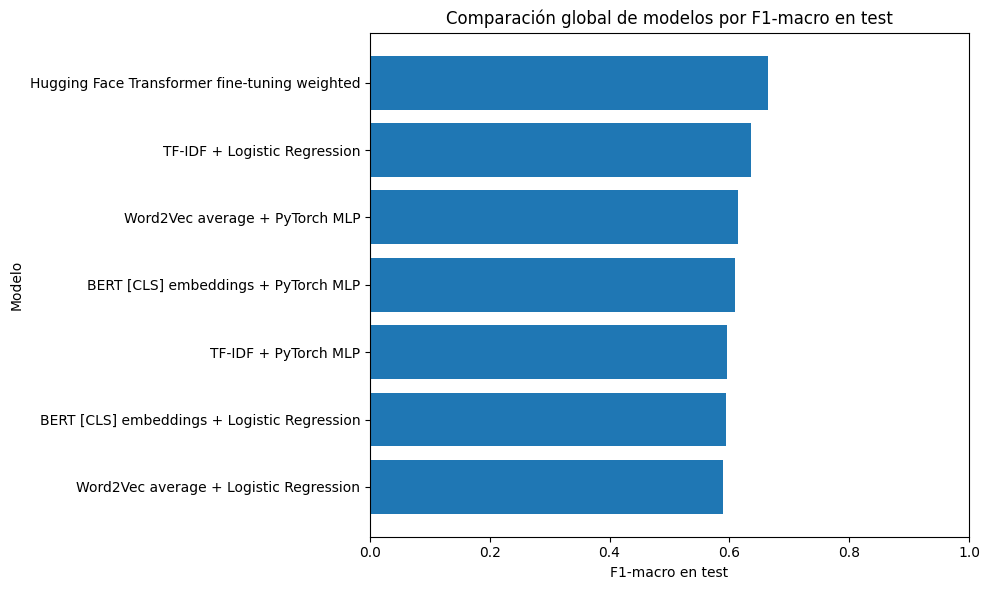

In [130]:
# Se ordenan los modelos de menor a mayor F1-macro para que el gráfico horizontal
# muestre visualmente el mejor modelo en la parte superior.
plot_df = (
    comparison_table
    .sort_values("f1_macro_test", ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["modelo"],
    plot_df["f1_macro_test"]
)

plt.xlabel("F1-macro en test")
plt.ylabel("Modelo")
plt.title("Comparación global de modelos por F1-macro en test")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### 4.4 Comparación con el mejor modelo sin fine-tuning Transformer

Se compara el mejor modelo global con el mejor modelo que no utiliza fine-tuning completo de un Transformer.

Esta comparación permite valorar si el coste computacional adicional del fine-tuning aporta una mejora relevante frente a modelos más sencillos y eficientes.

In [131]:
# Se identifica el mejor modelo global según F1-macro en test.
best_model_row = model_results_df.sort_values(
    "test_f1_macro",
    ascending=False
).iloc[0]

best_model_name = best_model_row["model"]
best_model_f1 = best_model_row["test_f1_macro"]

print("Mejor modelo global:", best_model_name)
print("F1-macro del mejor modelo:", round(best_model_f1, 4))

# Se excluyen los modelos Hugging Face para identificar el mejor modelo
# sin fine-tuning completo de Transformer.
non_hf_results_df = model_results_df[
    ~model_results_df["model"].str.contains("Hugging Face", case=False, na=False)
].copy()

best_non_hf_row = non_hf_results_df.sort_values(
    "test_f1_macro",
    ascending=False
).iloc[0]

best_non_hf_model_name = best_non_hf_row["model"]
best_non_hf_f1 = best_non_hf_row["test_f1_macro"]

print("Mejor modelo sin fine-tuning HF:", best_non_hf_model_name)
print("F1-macro del mejor modelo sin HF:", round(best_non_hf_f1, 4))

# Se calcula la diferencia absoluta de rendimiento.
f1_gain_best_vs_non_hf = best_model_f1 - best_non_hf_f1

print(
    "Diferencia de F1-macro entre el mejor modelo global y el mejor modelo sin HF:",
    round(f1_gain_best_vs_non_hf, 4)
)

Mejor modelo global: Hugging Face Transformer fine-tuning weighted
F1-macro del mejor modelo: 0.6649
Mejor modelo sin fine-tuning HF: TF-IDF + Logistic Regression
F1-macro del mejor modelo sin HF: 0.6367
Diferencia de F1-macro entre el mejor modelo global y el mejor modelo sin HF: 0.0282


### 4.5 Comparación por representación textual

En esta sección se agrupan los modelos según el tipo de representación textual utilizada:

- `TF-IDF`;
- `Word2Vec`;
- embeddings BERT congelados;
- Transformer con fine-tuning completo.

Esta comparación permite analizar qué representación proporciona mayor capacidad predictiva para la clasificación ideológica.

In [132]:
# Se asigna manualmente el tipo de representación textual usado por cada modelo.
representation_map = {
    "TF-IDF + Logistic Regression": "TF-IDF",
    "TF-IDF + PyTorch MLP": "TF-IDF",
    "Word2Vec average + Logistic Regression": "Word2Vec",
    "Word2Vec average + PyTorch MLP": "Word2Vec",
    "BERT [CLS] embeddings + Logistic Regression": "BERT embeddings",
    "BERT [CLS] embeddings + PyTorch MLP": "BERT embeddings",
    "Hugging Face Transformer fine-tuning weighted": "Transformer fine-tuning"
}

representation_results_df = model_results_df.copy()

# Se añade una columna con el tipo de representación.
representation_results_df["representation"] = (
    representation_results_df["model"]
    .map(representation_map)
)

# Se calcula un resumen de rendimiento por tipo de representación.
representation_summary = (
    representation_results_df
    .groupby("representation")
    .agg(
        best_test_f1_macro=("test_f1_macro", "max"),
        mean_test_f1_macro=("test_f1_macro", "mean"),
        n_models=("model", "count")
    )
    .reset_index()
    .sort_values("best_test_f1_macro", ascending=False)
)

representation_summary

,representation,best_test_f1_macro,mean_test_f1_macro,n_models
2,Transformer fine-tuning,0.664941,0.664941,1
1,TF-IDF,0.636749,0.616068,2
3,Word2Vec,0.615134,0.602082,2
0,BERT embeddings,0.609439,0.601685,2


El valor `best_test_f1_macro` indica el mejor resultado alcanzado por cada familia de representación. El valor `mean_test_f1_macro` resume el rendimiento medio de los modelos evaluados dentro de cada representación.

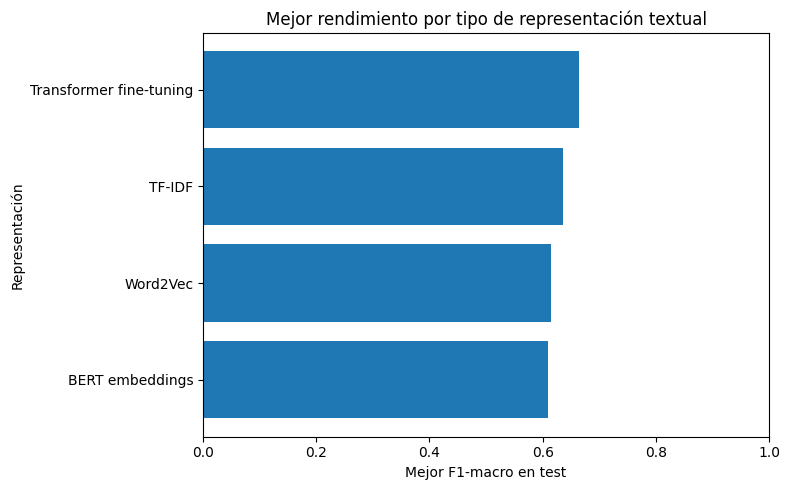

In [133]:
# Se prepara el dataframe para representar el mejor rendimiento de cada representación.
plot_representation_df = (
    representation_summary
    .sort_values("best_test_f1_macro", ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_representation_df["representation"],
    plot_representation_df["best_test_f1_macro"]
)

plt.xlabel("Mejor F1-macro en test")
plt.ylabel("Representación")
plt.title("Mejor rendimiento por tipo de representación textual")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### 4.6 Comparación por arquitectura

Además de comparar representaciones, se agrupan los modelos según la arquitectura utilizada:

- modelos lineales de `Logistic Regression`;
- redes neuronales MLP implementadas en PyTorch;
- Transformer ajustado mediante fine-tuning.

Esta comparación permite separar el efecto de la representación textual del efecto del tipo de modelo utilizado.

In [134]:
# Se asigna manualmente el tipo de arquitectura usada por cada modelo.
architecture_map = {
    "TF-IDF + Logistic Regression": "Logistic Regression",
    "Word2Vec average + Logistic Regression": "Logistic Regression",
    "BERT [CLS] embeddings + Logistic Regression": "Logistic Regression",
    "TF-IDF + PyTorch MLP": "PyTorch MLP",
    "Word2Vec average + PyTorch MLP": "PyTorch MLP",
    "BERT [CLS] embeddings + PyTorch MLP": "PyTorch MLP",
    "Hugging Face Transformer fine-tuning weighted": "Transformer fine-tuning"
}

architecture_results_df = model_results_df.copy()

# Se añade una columna con el tipo de arquitectura.
architecture_results_df["architecture"] = (
    architecture_results_df["model"]
    .map(architecture_map)
)

# Se calcula el resumen de rendimiento por arquitectura.
architecture_summary = (
    architecture_results_df
    .groupby("architecture")
    .agg(
        best_test_f1_macro=("test_f1_macro", "max"),
        mean_test_f1_macro=("test_f1_macro", "mean"),
        n_models=("model", "count")
    )
    .reset_index()
    .sort_values("best_test_f1_macro", ascending=False)
)

architecture_summary

,architecture,best_test_f1_macro,mean_test_f1_macro,n_models
2,Transformer fine-tuning,0.664941,0.664941,1
0,Logistic Regression,0.636749,0.606570,3
1,PyTorch MLP,0.615134,0.606653,3


El resumen por arquitectura permite comprobar si las redes neuronales mejoran sistemáticamente a los modelos lineales y si el fine-tuning del Transformer aporta una ventaja adicional respecto a las representaciones congeladas.

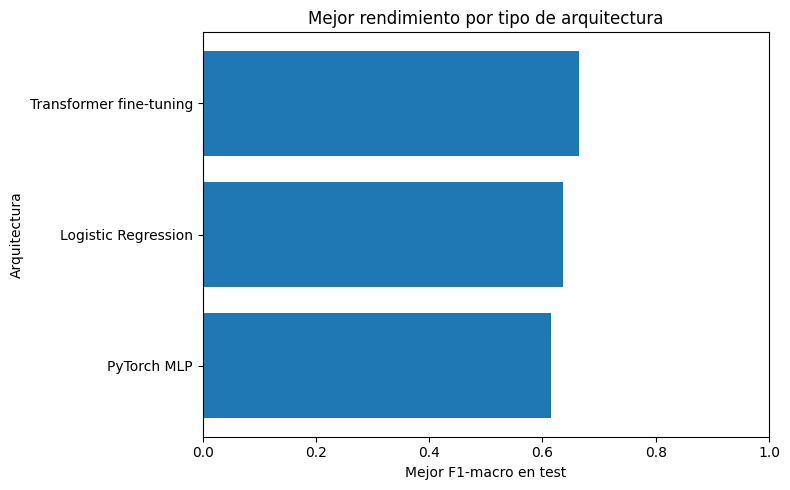

In [135]:
# Se prepara el dataframe para visualizar el mejor rendimiento de cada arquitectura.
plot_architecture_df = (
    architecture_summary
    .sort_values("best_test_f1_macro", ascending=True)
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_architecture_df["architecture"],
    plot_architecture_df["best_test_f1_macro"]
)

plt.xlabel("Mejor F1-macro en test")
plt.ylabel("Arquitectura")
plt.title("Mejor rendimiento por tipo de arquitectura")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

### 4.7 Guardado de la tabla comparativa

Se guarda la tabla comparativa en disco para reutilizarla posteriormente en el README, en la memoria del proyecto o en la presentación final.

In [136]:
# Se define la ruta donde se guardará la tabla comparativa.
comparison_results_path = Path("results") / "comparison_table.csv"
comparison_results_path.parent.mkdir(parents=True, exist_ok=True)

# Se guarda la tabla comparativa en formato CSV.
comparison_table.to_csv(
    comparison_results_path,
    index=False
)

print("Tabla comparativa guardada en:", comparison_results_path)

Tabla comparativa guardada en: results\comparison_table.csv


Los resultados muestran diferencias claras entre las distintas representaciones y arquitecturas evaluadas.

El mejor rendimiento global se obtiene con el modelo Transformer ajustado mediante fine-tuning, que alcanza el mayor valor de `F1-macro` en el conjunto de test. Esto indica que adaptar el modelo preentrenado a la tarea concreta de clasificación ideológica aporta una mejora respecto a usar embeddings congelados.

Entre los modelos sin fine-tuning, `TF-IDF + Logistic Regression` funciona como una baseline fuerte. A pesar de ser una representación más simple, supera a las variantes basadas en Word2Vec average y también a los modelos que usan embeddings BERT `[CLS]` congelados.

Los resultados de Word2Vec son más bajos que los de TF-IDF, aunque la versión con PyTorch MLP mejora respecto a Word2Vec con Logistic Regression. Además, esta variante llega a superar ligeramente a algunos modelos con BERT congelado, lo que muestra que usar BERT como extractor fijo de embeddings no garantiza por sí solo mejores resultados.

En conjunto, la comparación sugiere que la calidad de la representación textual es clave. TF-IDF ofrece una baseline sólida y eficiente, mientras que la mayor mejora aparece cuando el Transformer se ajusta directamente a la tarea mediante fine-tuning.

# 5. Extensión: análisis temático de polarización mediante clustering sobre embeddings BERT

Como extensión del proyecto básico, se analiza si los embeddings contextuales BERT capturan agrupamientos temáticos relacionados con la polarización ideológica.

Para ello, se utilizan los embeddings BERT `[CLS]` generados previamente, se reduce su dimensionalidad y se aplica clustering no supervisado. Posteriormente, se estudia la composición ideológica de cada cluster y se extraen palabras representativas para interpretar los grupos obtenidos.

Esta extensión no pretende verificar automáticamente si un tweet contiene desinformación factual, ya que el dataset utilizado está etiquetado por ideología. El objetivo es analizar si existen agrupamientos discursivos o temáticos asociados a posiciones ideológicas diferenciadas.

## 5.1 Preparación de datos
En esta extensión se trabaja únicamente con `train_public`, evitando utilizar `test_codalab`. El conjunto de test se ha reservado para la evaluación final de los modelos supervisados, por lo que no se emplea en el análisis exploratorio de clustering.

Los embeddings BERT `[CLS]` se reutilizan para evitar recalcular representaciones contextuales.

In [137]:
# Se importan las librerías necesarias para escalar los embeddings, reducir dimensionalidad,
# aplicar clustering e interpretar posteriormente los grupos obtenidos.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Se fija la semilla para que los resultados sean reproducibles.
RANDOM_STATE = 42

# Se comprueba que los embeddings BERT ya existen antes de ejecutar la extensión.
# Si esta condición falla, el notebook se detiene para evitar resultados incoherentes.
assert "X_train_bert" in globals(), "X_train_bert debe estar cargado antes de ejecutar la extensión."

# Se comprueba que el número de embeddings coincide con el número de tweets de entrenamiento.
assert X_train_bert.shape[0] == len(train_df), "No coincide el número de embeddings BERT con train_df."

# Se crea una copia del dataframe de entrenamiento para añadir variables específicas de la extensión.
extension_df = train_df.copy()

# Se añaden la ideología y el grupo original de cada tweet para poder analizar después los clusters.
extension_df["ideology"] = y_train.values
extension_df["label_group"] = groups_train.values

print("Dataframe de la extensión:", extension_df.shape)
print("Embeddings BERT:", X_train_bert.shape)

Dataframe de la extensión: (180000, 12)
Embeddings BERT: (180000, 768)


Antes de aplicar clustering, los embeddings BERT se escalan mediante `StandardScaler` y se reducen a 50 dimensiones mediante PCA.

El escalado evita que unas dimensiones tengan más peso que otras por diferencias de escala. La reducción con PCA permite disminuir el ruido y el coste computacional, conservando una parte relevante de la variabilidad de los embeddings. El clustering se realiza sobre esta representación reducida, no directamente sobre los 768 valores originales de BERT.

In [138]:
# Se escala cada dimensión de los embeddings BERT para que tengan media 0 y desviación típica 1.
scaler_extension = StandardScaler()

X_bert_scaled = scaler_extension.fit_transform(X_train_bert)

# Se reduce la dimensionalidad de los embeddings para disminuir ruido y coste computacional.
# Se conservan 50 componentes principales como representación intermedia para el clustering.
pca_cluster = PCA(
    n_components=50,
    svd_solver="randomized",
    random_state=RANDOM_STATE
)

X_bert_pca50 = pca_cluster.fit_transform(X_bert_scaled)

# Se calcula la proporción total de varianza explicada por los 50 componentes seleccionados.
explained_variance = pca_cluster.explained_variance_ratio_.sum()

print("Representación PCA:", X_bert_pca50.shape)
print("Varianza explicada con 50 componentes:", round(explained_variance, 4))

Representación PCA: (180000, 50)
Varianza explicada con 50 componentes: 0.6214


## 5.2 Selección del número de clusters

Para seleccionar el número de clusters se comparan distintos valores de `k` mediante `silhouette_score`.

Esta métrica mide hasta qué punto las muestras quedan más cerca de los elementos de su propio cluster que de los elementos de otros clusters. Valores cercanos a 1 indican clusters mejor separados, valores cercanos a 0 indican solapamiento entre grupos y valores negativos indican posibles asignaciones incorrectas.

Debido al tamaño del dataset, la métrica se calcula sobre una muestra de embeddings. Esta aproximación permite comparar varios valores de `k` sin aumentar excesivamente el coste computacional.

In [139]:
# Se define el tamaño máximo de la muestra utilizada para calcular silhouette.
# Esta muestra permite reducir el coste computacional del cálculo.
SILHOUETTE_SAMPLE_SIZE = 5000

# Se crea un generador aleatorio reproducible usando la semilla definida previamente.
rng = np.random.default_rng(RANDOM_STATE)

# Se ajusta el tamaño de la muestra para no superar el número total de embeddings disponibles.
sample_size = min(SILHOUETTE_SAMPLE_SIZE, X_bert_pca50.shape[0])

# Se seleccionan índices aleatorios sin reemplazo para construir la muestra de evaluación.
sample_idx = rng.choice(
    X_bert_pca50.shape[0],
    size=sample_size,
    replace=False
)

# Se extraen los embeddings reducidos correspondientes a la muestra seleccionada.
X_silhouette = X_bert_pca50[sample_idx]

# Se definen los valores de k que se van a comparar.
k_values = [3, 4, 5, 6, 7, 8]

# Se inicializa una lista para almacenar el resultado de silhouette de cada valor de k.
silhouette_rows = []

# Se prueban distintos números de clusters y se compara su silhouette.
for k in k_values:
    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        batch_size=4096,
        n_init=10
    )

    # Se entrena KMeans sobre la muestra y se asigna un cluster a cada tweet de la muestra.
    sample_clusters = kmeans.fit_predict(X_silhouette)

    # Se calcula la calidad de separación de los clusters para el valor actual de k.
    score = silhouette_score(
        X_silhouette,
        sample_clusters
    )

    silhouette_rows.append({
        "k": k,
        "silhouette_score": score
    })

# Se convierte la lista de resultados en un dataframe para facilitar su visualización.
silhouette_df = pd.DataFrame(silhouette_rows)

silhouette_df

,k,silhouette_score
0,3,0.060134
1,4,0.057675
2,5,0.056224
3,6,0.057510
4,7,0.055228
5,8,0.056402


Los resultados muestran que el mejor valor entre los evaluados es `k = 3`. Sin embargo, el valor máximo de `silhouette_score` es bajo, aproximadamente `0.060`, por lo que la separación entre clusters es débil.

Por este motivo, los clusters deben interpretarse como agrupaciones exploratorias dentro del espacio de embeddings BERT, no como categorías temáticas perfectamente separadas.

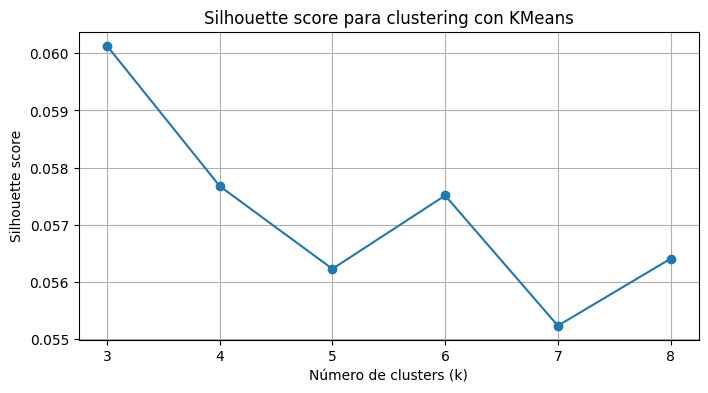

In [140]:
# Se crea una figura independiente para visualizar la evolución de silhouette.
plt.figure(figsize=(8, 4))

# Se representa el valor de silhouette obtenido para cada número de clusters.
plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_score"],
    marker="o"
)

plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score para clustering con KMeans")
plt.grid(True)
plt.show()

Una vez seleccionado el mejor valor de `k` entre los evaluados, se entrena un modelo KMeans final sobre todos los embeddings BERT reducidos mediante PCA.

Cada tweet queda asignado a un cluster. A continuación, estos clusters se analizan en términos de composición ideológica, desviación respecto a la distribución global y vocabulario representativo.

In [141]:
# Se selecciona el valor de k con mayor silhouette_score.
best_k = int(
    silhouette_df
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]["k"]
)

print("Número de clusters seleccionado:", best_k)

# Se entrena el modelo KMeans final con el número de clusters seleccionado.
final_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    batch_size=4096,
    n_init=10
)

# Se asigna cada tweet al cluster correspondiente.
extension_df["cluster"] = final_kmeans.fit_predict(X_bert_pca50)

# Se muestra el número de tweets asignados a cada cluster.
extension_df["cluster"].value_counts().sort_index()

Número de clusters seleccionado: 3


cluster
0    61947
1    54718
2    63335
Name: count, dtype: int64

## 5.3 Asociación entre clusters e ideología

Una vez asignado cada tweet a un cluster, se analiza si existe relación entre los grupos obtenidos por KMeans y la ideología de los tweets.

Para ello, se construye una tabla de contingencia entre `cluster` e `ideology`, se aplica un test chi-square y se calcula Cramer's V. El test chi-square permite comprobar si la distribución de ideologías cambia entre clusters, mientras que Cramer's V permite medir la intensidad de esa asociación.

In [142]:
# Se importa el test chi-cuadrado para analizar la asociación entre variables categóricas.
from scipy.stats import chi2_contingency

# Se crea una tabla de contingencia con el número de tweets por cluster e ideología.
cluster_counts = pd.crosstab(
    extension_df["cluster"],
    extension_df["ideology"]
)

# Se normaliza la tabla por filas para interpretar proporciones ideológicas dentro de cada cluster.
cluster_distribution = pd.crosstab(
    extension_df["cluster"],
    extension_df["ideology"],
    normalize="index"
)

# Se calcula la distribución ideológica global del conjunto de entrenamiento.
global_ideology_distribution = (
    extension_df["ideology"]
    .value_counts(normalize=True)
    .sort_index()
)

# Se crea una tabla resumen con la distribución ideológica de cada cluster.
cluster_summary = cluster_distribution.copy()

# Se añade el número total de tweets asignados a cada cluster.
cluster_summary["n_tweets"] = cluster_counts.sum(axis=1)

# Se identifica la ideología mayoritaria dentro de cada cluster.
cluster_summary["dominant_ideology"] = cluster_distribution.idxmax(axis=1)

# Se calcula la proporción de la ideología dominante dentro de cada cluster.
cluster_summary["ideological_purity"] = cluster_distribution.max(axis=1)

# Se calcula la desviación de cada cluster respecto a la distribución ideológica global.
for ideology_value in global_ideology_distribution.index:
    cluster_summary[f"{ideology_value}_vs_global"] = (
        cluster_summary[ideology_value]
        - global_ideology_distribution[ideology_value]
    )

# Se reordena la tabla para mostrar primero los clusters con mayor pureza ideológica.
cluster_summary = (
    cluster_summary
    .reset_index()
    .sort_values("ideological_purity", ascending=False)
)

# Se aplica el test chi-cuadrado para comprobar asociación entre cluster e ideología.
chi2, p_value, dof, expected = chi2_contingency(cluster_counts)

# Se calcula el número total de observaciones incluidas en la tabla de contingencia.
n_observations = cluster_counts.to_numpy().sum()

# Se calcula Cramer's V para medir el tamaño del efecto de la asociación cluster-ideología.
cramers_v = np.sqrt(
    chi2 / (
        n_observations
        * (min(cluster_counts.shape) - 1)
    )
)

print("Test chi-cuadrado para asociación cluster / ideología")
print("=" * 80)
print("chi2:", round(chi2, 4))
print("p-value:", p_value)
print("V de Cramer:", round(cramers_v, 4))

cluster_summary

Test chi-cuadrado para asociación cluster / ideología
chi2: 616.9765
p-value: 1.0598655019576414e-134
V de Cramer: 0.0585


ideology,cluster,left,right,n_tweets,dominant_ideology,ideological_purity,left_vs_global,right_vs_global
0,0,0.584532,0.415468,61947,left,0.584532,0.026754,-0.026754
1,1,0.572536,0.427464,54718,left,0.572536,0.014758,-0.014758
2,2,0.518860,0.481140,63335,left,0.518860,-0.038918,0.038918


La tabla anterior muestra la composición ideológica de cada cluster y permite revisar si los grupos obtenidos por KMeans están relacionados con alguna ideología concreta. 

A continuación, se muestra la distribución interna de cada cluster mediante un gráfico de barras. Esta gráfica permite ver si algún cluster está claramente dominado por una clase o si, por el contrario, los clusters mezclan tweets de `left` y `right`.

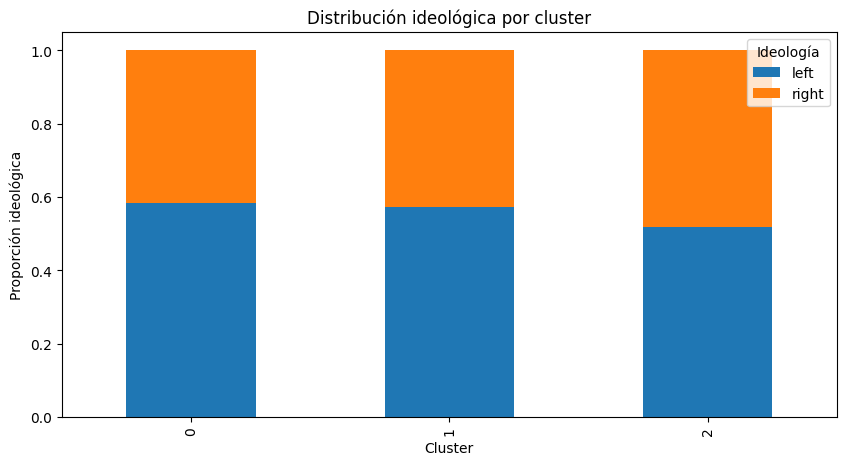

In [143]:
# Se representa la distribución ideológica de cada cluster mediante barras apiladas.
cluster_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Proporción ideológica")
plt.title("Distribución ideológica por cluster")
plt.legend(title="Ideología")
plt.show()

La gráfica muestra que todos los clusters contienen tweets de ambas ideologías.

Aunque algunos clusters tienen una ligera mayoría de una clase concreta, no aparece ningún grupo formado solo por `left` o solo por `right`. Por tanto, los clusters no separan la ideología de forma clara.

Esto encaja con el valor bajo de Cramer's V (`0.0585`): existe cierta asociación entre cluster e ideología, pero la relación es débil.

Para completar el análisis, se compara la proporción ideológica de cada cluster con la distribución global del conjunto de entrenamiento.

Esta gráfica permite ver si un cluster tiene más o menos presencia de `left` o `right` de la esperada según la distribución general del dataset.

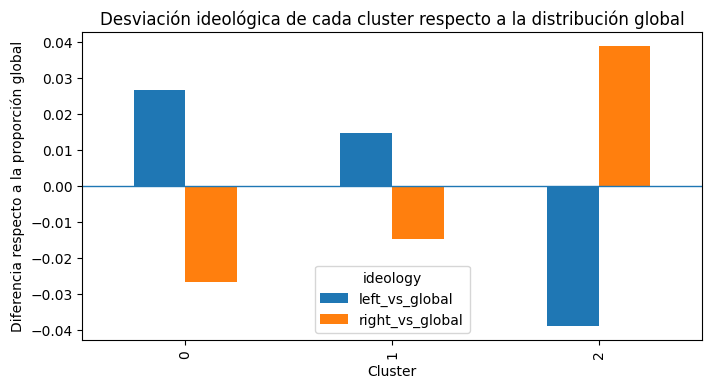

In [144]:
# Se seleccionan las desviaciones de cada cluster respecto a la distribución ideológica global.
deviation_df = cluster_summary.set_index("cluster")[
    ["left_vs_global", "right_vs_global"]
]

# Se visualizan las desviaciones para ver qué clusters se alejan más de la distribución global.
deviation_df.plot(
    kind="bar",
    figsize=(8, 4)
)

# Se añade una línea horizontal en cero para separar desviaciones positivas y negativas.
plt.axhline(0, linewidth=1)

plt.xlabel("Cluster")
plt.ylabel("Diferencia respecto a la proporción global")
plt.title("Desviación ideológica de cada cluster respecto a la distribución global")
plt.show()

## 5.4 Visualización de embeddings mediante PCA 2D

Para visualizar la estructura de los embeddings, se selecciona una muestra de tweets y se proyectan sus representaciones BERT a dos dimensiones mediante PCA.

Esta proyección se utiliza únicamente con fines visuales. El clustering final no se entrena sobre estas dos componentes, sino sobre la representación PCA de 50 dimensiones calculada anteriormente.

In [145]:
# Se define el tamaño máximo de la muestra utilizada para la visualización.
PLOT_SAMPLE_SIZE = 15000

# Se ajusta el tamaño de la muestra para no superar el número total de embeddings disponibles.
plot_sample_size = min(PLOT_SAMPLE_SIZE, X_bert_scaled.shape[0])

# Se seleccionan índices aleatorios sin reemplazo para crear una muestra reproducible.
plot_idx = rng.choice(
    X_bert_scaled.shape[0],
    size=plot_sample_size,
    replace=False
)

# Se crea una proyección PCA de dos dimensiones solo para visualizar los embeddings.
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

# Se transforma la muestra de embeddings escalados al espacio PCA 2D.
X_bert_pca2 = pca_2d.fit_transform(X_bert_scaled[plot_idx])

# Se crea un dataframe auxiliar con los tweets de la muestra seleccionada.
plot_df = extension_df.iloc[plot_idx].copy()

# Se añaden las dos coordenadas PCA al dataframe de visualización.
plot_df["pca_1"] = X_bert_pca2[:, 0]
plot_df["pca_2"] = X_bert_pca2[:, 1]

La siguiente figura muestra la proyección PCA 2D de la muestra de embeddings, coloreando cada punto según su ideología.

El objetivo es inspeccionar visualmente si las clases ideológicas ocupan regiones claramente diferenciadas o si aparecen mezcladas en el espacio proyectado.

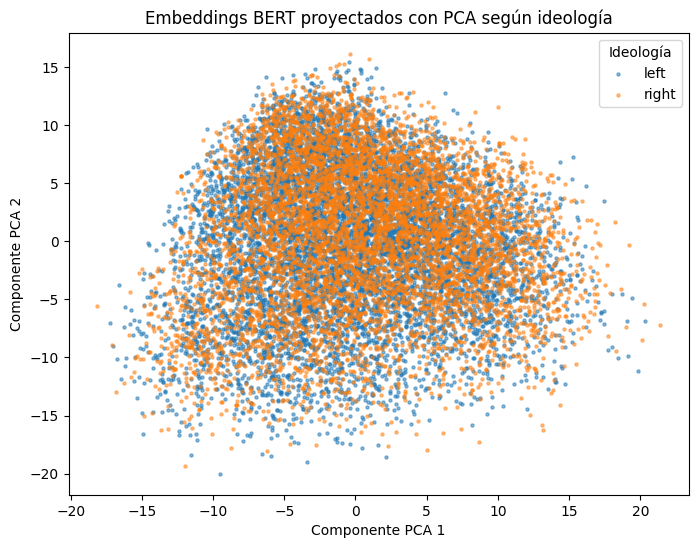

In [146]:
# Se crea una figura independiente para visualizar la proyección PCA por ideología.
plt.figure(figsize=(8, 6))

# Se dibuja una nube de puntos por cada ideología para comparar su distribución espacial.
for ideology_value, group_df in plot_df.groupby("ideology"):
    plt.scatter(
        group_df["pca_1"],
        group_df["pca_2"],
        s=5,
        alpha=0.5,
        label=ideology_value
    )

plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")
plt.title("Embeddings BERT proyectados con PCA según ideología")
plt.legend(title="Ideología")
plt.show()

La proyección PCA 2D de los embeddings BERT coloreada por ideología muestra un solapamiento muy elevado entre las clases `left` y `right`.

Esto no implica que los embeddings BERT no contengan información útil para la clasificación, sino que dicha información probablemente se encuentra distribuida en un espacio de mayor dimensión y no se resume de forma evidente en una proyección PCA 2D.

La misma proyección PCA 2D se visualiza ahora coloreando los puntos según el cluster asignado por KMeans.

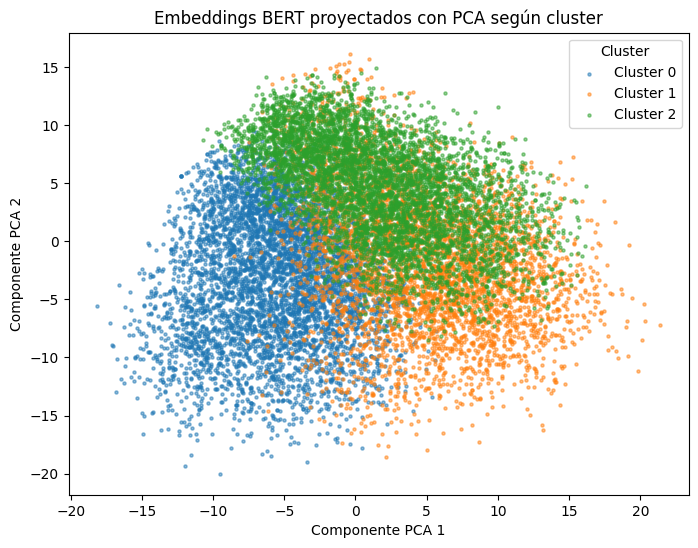

In [147]:
# Se crea una figura independiente para visualizar la proyección PCA por cluster.
plt.figure(figsize=(8, 6))

# Se dibuja una nube de puntos por cada cluster asignado por KMeans.
for cluster_id, group_df in plot_df.groupby("cluster"):
    plt.scatter(
        group_df["pca_1"],
        group_df["pca_2"],
        s=5,
        alpha=0.5,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Componente PCA 1")
plt.ylabel("Componente PCA 2")
plt.title("Embeddings BERT proyectados con PCA según cluster")
plt.legend(title="Cluster")
plt.show()

Las visualizaciones PCA permiten inspeccionar de forma aproximada la estructura del espacio de embeddings.

En la proyección por cluster se observan regiones parcialmente diferenciadas. El cluster 0 aparece más concentrado en la zona izquierda, el cluster 1 en la zona derecha y el cluster 2 en una región más superior y central. Sin embargo, también existe un solapamiento importante entre clusters, especialmente en la zona central de la figura.

Este resultado es coherente con el valor bajo de `silhouette_score`: KMeans detecta agrupamientos aproximados, pero no clusters claramente separados.

## 5.5 Interpretación de clusters mediante términos representativos

Para interpretar los clusters, se calculan palabras y expresiones características de cada grupo mediante TF-IDF.

Este análisis no se utiliza para entrenar modelos ni para modificar la asignación de clusters. Su función es únicamente interpretativa: permite observar qué términos aparecen de forma más representativa en cada agrupación y ayuda a proponer una descripción cualitativa de los temas discursivos presentes.

Las etiquetas asignadas a los clusters deben entenderse como nombres aproximados, no como categorías cerradas ni perfectamente separadas.

In [148]:
# Se define una lista básica de stopwords en castellano para reducir términos poco informativos.
SPANISH_STOPWORDS = {
    "a", "al", "algo", "algunas", "algunos", "ante", "antes", "como",
    "con", "contra", "cual", "cuando", "de", "del", "desde", "donde",
    "durante", "e", "el", "ella", "ellas", "ellos", "en", "entre",
    "era", "erais", "eran", "eras", "eres", "es", "esa", "esas",
    "ese", "eso", "esos", "esta", "estaba", "estado", "estais",
    "estan", "estar", "estas", "este", "esto", "estos", "estoy",
    "fue", "fueron", "ha", "han", "has", "hasta", "hay", "la",
    "las", "le", "les", "lo", "los", "mas", "me", "mi", "mis",
    "mucho", "muy", "no", "nos", "o", "os", "otra", "otras",
    "otro", "otros", "para", "pero", "por", "porque", "que", "se",
    "sea", "ser", "si", "sin", "sobre", "son", "su", "sus", "tambien",
    "te", "tener", "tiene", "todo", "todos", "tu", "un", "una",
    "uno", "unos", "y", "ya"
}

# Se amplía la lista anterior con tokens propios de Twitter o del preprocesado.
CUSTOM_STOPWORDS = SPANISH_STOPWORDS.union({
    "rt", "url", "user", "http", "https", "amp",
    "hashtag", "politician", "political", "party",
    "political party"
})

# Se utiliza la misma columna de texto limpio definida en los apartados anteriores.
TEXT_COL_EXTENSION = TEXT_COL_CLASSIC  # tweet_clean

# Se configura un vectorizador TF-IDF para obtener términos y bigramas representativos.
cluster_tfidf_vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.75,
    stop_words=list(CUSTOM_STOPWORDS),
    token_pattern=r"(?u)\b[a-záéíóúñü]{3,}\b"
)

# Se ajusta TF-IDF sobre los textos del conjunto de entrenamiento usado en la extensión.
X_extension_tfidf = cluster_tfidf_vectorizer.fit_transform(
    extension_df[TEXT_COL_EXTENSION].fillna("").astype(str)
)

# Se recuperan los nombres de los términos generados por el vectorizador.
feature_names = np.array(
    cluster_tfidf_vectorizer.get_feature_names_out()
)

# Se calcula el valor medio global de TF-IDF de cada término en todo el corpus.
global_mean_tfidf = np.asarray(
    X_extension_tfidf.mean(axis=0)
).ravel()

# Se inicializa una lista para guardar los términos más representativos de cada cluster.
top_terms_rows = []

# Se define el número de términos que se van a mostrar por cluster.
TOP_N_TERMS = 15

# Se recorre cada cluster para interpretarlo individualmente.
for cluster_id in sorted(extension_df["cluster"].unique()):
    # Se identifica qué tweets pertenecen al cluster actual.
    cluster_mask = extension_df["cluster"].eq(cluster_id).values

    # Se calcula el valor medio de TF-IDF de cada término dentro del cluster actual.
    cluster_mean_tfidf = np.asarray(
        X_extension_tfidf[cluster_mask].mean(axis=0)
    ).ravel()

    # Se calcula una puntuación diferencial frente al promedio global del corpus.
    # Los términos con mayor valor son más característicos de este cluster que del corpus completo.
    differential_score = cluster_mean_tfidf - global_mean_tfidf

    # Se seleccionan los índices de los términos con mayor puntuación diferencial.
    top_indices = differential_score.argsort()[::-1][:TOP_N_TERMS]

    top_terms_rows.append({
        "cluster": cluster_id,
        "top_terms": ", ".join(feature_names[top_indices])
    })

# Se crea una tabla con los términos representativos de cada cluster.
cluster_top_terms_df = pd.DataFrame(top_terms_rows)

cluster_top_terms_df

,cluster,top_terms
0,0,"gracias, hoy, enhorabuena, abrazo, feliz, gran, día, muchas, muchas gracias, nuestro, mañana, aquí, placer, libro, siempre"
1,1,"gobierno, millones, tras, euros, españa, pide, ley, presidente, según, reforma, climático, ministra, cambio climático, cgpj, anuncia"
2,2,"qué, nada, está, pues, usted, ahora, hace, creo, claro, gente, puede, verdad, solo, así, nadie"


Además de los términos representativos, se seleccionan ejemplos reales de tweets para cada cluster.

Para que los ejemplos sean más representativos, se escogen los tweets más cercanos al centroide de su cluster en el espacio utilizado por KMeans. De esta forma, se evita depender de una muestra aleatoria y se facilita la interpretación cualitativa de cada agrupación.

In [149]:
# Se define el número de tweets representativos que se mostrarán por cluster.
N_EXAMPLES_PER_CLUSTER = 5

# Se selecciona la columna de texto original si existe.
# En caso contrario, se utiliza la columna limpia usada en la extensión.
TEXT_COL_EXAMPLES = (
    "tweet"
    if "tweet" in extension_df.columns
    else TEXT_COL_EXTENSION
)

# Se calcula la distancia de cada tweet a cada centroide de KMeans.
cluster_distances = final_kmeans.transform(X_bert_pca50)

# Se inicializa una lista para guardar los ejemplos representativos.
example_rows = []

# Se recorre cada cluster para seleccionar los tweets más cercanos a su centroide.
for cluster_id in sorted(extension_df["cluster"].unique()):
    # Se obtienen los índices de los tweets asignados al cluster actual.
    cluster_indices = np.where(
        extension_df["cluster"].values == cluster_id
    )[0]

    # Se ordenan los tweets del cluster por distancia al centroide y se seleccionan los más cercanos.
    nearest_indices = cluster_indices[
        np.argsort(cluster_distances[cluster_indices, cluster_id])
        [:N_EXAMPLES_PER_CLUSTER]
    ]

    # Se guarda la información básica de cada tweet representativo.
    for idx in nearest_indices:
        row = extension_df.iloc[idx]

        example_rows.append({
            "cluster": cluster_id,
            "ideology": row["ideology"],
            "distance_to_centroid": cluster_distances[idx, cluster_id],
            "text": row[TEXT_COL_EXAMPLES]
        })

# Se crea una tabla con los ejemplos representativos de cada cluster.
cluster_examples_df = pd.DataFrame(example_rows)

cluster_examples_df

,cluster,ideology,distance_to_centroid,text
0,0,left,10.385773,No habría sido lo mismo [HASHTAG] sin la narración y la mirada privilegiada de dos bestias del periodismo como Xosé Manuel Pereiro @user y @user . Gracias por el privilegio. Empezamos en nada
1,0,left,10.418960,"Aquí os dejo el vídeo del CSIC. Quédense con sus caras, sobre todo con la del de la coleta :P"
2,0,left,10.617114,"Comienza una semana muy bonita para mí. Dos amigos, dos amigos de los de verdad, van a brillar en el @user y voy a tener la suerte de verlo.. Qué bonito compartir la música y la vida (si no es lo mismo) con tan buena gente. @user"
3,0,left,11.333291,"@user Espérate que no nos digan que si te la pones tú, evitas que los demás tengan cáncer.: viendo lo visto…"
4,0,left,11.342093,"Tenía muchas ganas de leer a Kallifatides, y este libro confirma mis sospechas: es difícil crear tanta belleza en tan pocas páginas. Maravilla.. @user"
5,1,right,13.971318,Dicho y hecho: el empleo se dispara en Castilla y León tras la entrada de [POLITICAL_PARTY] en la Junta
6,1,right,14.094990,La presión contra [POLITICIAN] crece en Ciudadanos y un nombre sobresale en medio del ruido interno 👇
7,1,left,14.307505,"❌❌ Los cataríes sobornaron para comprar el Mundial del fútbol, han sobornado a parlamentarios europeos… ¿Y alguien cree que van a levantar la Torre del Puerto de [HASHTAG] sin comprar voluntades? ¿Aquí no han sobornado ya a nadie?. 👇🏻👇🏻"
8,1,left,14.372437,"Hace un tiempo, en un vuelo Tokio-Madrid, una azafata me dijo:. “Cuando volamos con japoneses, el avión está más limpio al aterrizar que al despegar. Limpian hasta los baños”.. Civismo que hemos visto en el mundial y que tiene que ver con esto:"
9,1,left,14.398655,"NO es el gobierno quien decide abrirla o no, sino el propietario de la central, que YA decidió gobernando el # [POLITICAL_PARTY] en ambas administraciones que NO le interesaba invertir en ella: El arte de marear la perdiz de [HASHTAG] sin aportar..."


A partir de los términos característicos y de los ejemplos cercanos al centroide, se asigna un nombre interpretativo a cada cluster.

Estos nombres no representan clases reales del dataset ni categorías supervisadas. Son etiquetas descriptivas propuestas para resumir los patrones discursivos observados en cada agrupación.

In [150]:
# Se asignan nombres interpretativos a los clusters a partir de términos y ejemplos representativos.
# Estas etiquetas son descriptivas y no deben interpretarse como categorías perfectas.
cluster_name_map = {
    0: "Interacción social, cultura y conversación personal",
    1: "Política institucional, gobierno y agenda pública",
    2: "Opinión política crítica y confrontación discursiva"
}

# Se añaden los nombres interpretativos a las tablas principales de la extensión.
cluster_summary["cluster_name"] = cluster_summary["cluster"].map(cluster_name_map)
cluster_top_terms_df["cluster_name"] = cluster_top_terms_df["cluster"].map(cluster_name_map)
cluster_examples_df["cluster_name"] = cluster_examples_df["cluster"].map(cluster_name_map)

# Se combina el resumen ideológico con los términos representativos de cada cluster.
cluster_interpretation_df = (
    cluster_summary
    .merge(cluster_top_terms_df, on=["cluster", "cluster_name"], how="left")
    [
        [
            "cluster",
            "cluster_name",
            "n_tweets",
            "left",
            "right",
            "dominant_ideology",
            "ideological_purity",
            "left_vs_global",
            "right_vs_global",
            "top_terms"
        ]
    ]
)

cluster_interpretation_df

,cluster,cluster_name,n_tweets,left,right,dominant_ideology,ideological_purity,left_vs_global,right_vs_global,top_terms
0,0,"Interacción social, cultura y conversación personal",61947,0.584532,0.415468,left,0.584532,0.026754,-0.026754,"gracias, hoy, enhorabuena, abrazo, feliz, gran, día, muchas, muchas gracias, nuestro, mañana, aquí, placer, libro, siempre"
1,1,"Política institucional, gobierno y agenda pública",54718,0.572536,0.427464,left,0.572536,0.014758,-0.014758,"gobierno, millones, tras, euros, españa, pide, ley, presidente, según, reforma, climático, ministra, cambio climático, cgpj, anuncia"
2,2,Opinión política crítica y confrontación discursiva,63335,0.518860,0.481140,left,0.518860,-0.038918,0.038918,"qué, nada, está, pues, usted, ahora, hace, creo, claro, gente, puede, verdad, solo, así, nadie"


## 5.6 Guardado de resultados de la extensión

Se exportan los resultados principales del clustering: resumen ideológico por cluster, términos representativos, ejemplos cercanos al centroide, puntuaciones de silhouette e interpretación final de cada grupo.

In [151]:
# Se define el directorio donde se guardarán los resultados de la extensión.
EXTENSION_RESULTS_DIR = Path("results") / "extension_clustering"

# Se crea el directorio si no existe previamente.
EXTENSION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Se guarda el resumen ideológico de cada cluster.
cluster_summary.to_csv(
    EXTENSION_RESULTS_DIR / "cluster_ideological_summary.csv",
    index=False
)

# Se guardan los términos representativos de cada cluster.
cluster_top_terms_df.to_csv(
    EXTENSION_RESULTS_DIR / "cluster_top_terms.csv",
    index=False
)

# Se guardan los ejemplos reales más cercanos al centroide de cada cluster.
cluster_examples_df.to_csv(
    EXTENSION_RESULTS_DIR / "cluster_examples.csv",
    index=False
)

# Se guardan las puntuaciones de silhouette obtenidas para cada valor de k evaluado.
silhouette_df.to_csv(
    EXTENSION_RESULTS_DIR / "silhouette_scores.csv",
    index=False
)

# Se guarda la tabla final de interpretación de clusters.
cluster_interpretation_df.to_csv(
    EXTENSION_RESULTS_DIR / "cluster_interpretation.csv",
    index=False
)

print("Resultados de la extensión guardados en:", EXTENSION_RESULTS_DIR)

Resultados de la extensión guardados en: results\extension_clustering


## 5.7 Conclusiones de la extensión

El análisis de clustering sobre embeddings BERT permite estudiar la estructura del corpus desde una perspectiva no supervisada. Para ello, se han reutilizado los embeddings contextuales `[CLS]`, se ha reducido su dimensionalidad mediante PCA y se ha aplicado KMeans sobre la representación reducida de 50 componentes.

La selección del número de clusters mediante `silhouette_score` indica que la mejor configuración entre las evaluadas es `k = 3`. Sin embargo, el valor máximo obtenido es bajo, aproximadamente `0.060`, por lo que no se observan clusters claramente separados. Por este motivo, los grupos obtenidos deben interpretarse como agrupaciones aproximadas dentro del espacio semántico de BERT, no como categorías temáticas perfectas.

El análisis de composición ideológica muestra que todos los clusters contienen tweets de ambas ideologías. Aunque existen ligeras diferencias en la proporción de clases entre grupos, la pureza ideológica se mantiene próxima a valores mixtos y Cramer's V es bajo, aproximadamente `0.0585`. Por tanto, la asociación entre cluster e ideología es estadísticamente detectable, pero débil en términos de tamaño de efecto.

La interpretación cualitativa mediante términos TF-IDF y ejemplos cercanos al centroide permite describir los clusters como patrones discursivos aproximados: interacción social y conversación personal, política institucional y agenda pública, y opinión política crítica o confrontativa. Estas etiquetas tienen carácter descriptivo y no deben entenderse como clases reales del dataset.Este uso de TF-IDF es diferente al realizado en los apartados anteriores, donde TF-IDF se emplea como representación de entrada para entrenar modelos de clasificación. En cambio, en esta extensión, los clusters se han obtenido previamente a partir de embeddings BERT reducidos mediante PCA.

Esta extensión complementa la evaluación supervisada porque no se centra en maximizar la predicción, sino en explorar la organización interna del corpus en el espacio de embeddings. No obstante, el análisis no constituye una detección directa de desinformación factual, ya que el dataset no contiene etiquetas explícitas de veracidad.

Como trabajo futuro, podrían explorarse algoritmos basados en densidad como DBSCAN o HDBSCAN. Estos métodos podrían capturar estructuras no esféricas y permitir puntos etiquetados como ruido, aunque requerirían una calibración adicional de parámetros y podrían producir muchos puntos sin asignar o clusters dominantes.